<a href="https://colab.research.google.com/github/Tushig154/Portfolio_DRL_DSR/blob/main/v24_v25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install stable-baselines3[extra] yfinance gymnasium torch numpy pandas matplotlib scipy hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 23.0 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [ ]:
pip install yfinance matplotlib pandas

In [ ]:
"""
Stock Price & Return Charts (2011–2024)
======================================
Хувьцааны үнэ болон хуримтлагдсан өгөөжийн график
yfinance ашиглан өгөгдлийг автоматаар татна.

Суулгах: pip install yfinance matplotlib pandas
"""

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── Тикер тохиргоо ─────────────────────────────────────────────────────────────
TICKERS = {
    "Microsoft":          "MSFT",
    "Apple":              "AAPL",
    "JPMorgan Chase":     "JPM",
    "Visa":               "V",
    "Chevron":            "CVX",
    "ExxonMobil":         "XOM",
    "Caterpillar":        "CAT",
    "Honeywell":          "HON",
    "Procter & Gamble":   "PG",
    "Walmart":            "WMT",
    "Johnson & Johnson":  "JNJ",
    "UnitedHealth":       "UNH",
    "TLT (iShares 20Y+)": "TLT",
}

START = "2011-01-01"
END   = "2024-12-31"

# ── Өгөгдөл татах ──────────────────────────────────────────────────────────────
print("Өгөгдөл татаж байна…")
symbols = list(TICKERS.values())
raw = yf.download(symbols, start=START, end=END, auto_adjust=True)["Close"]
raw.columns = {v: k for k, v in TICKERS.items()}[raw.columns] if hasattr(raw.columns, '__iter__') else raw.columns

# Баганыг нэрээр нь дахин хүргэх
name_map = {v: k for k, v in TICKERS.items()}
raw = raw.rename(columns=name_map)

# Сарын сүүлийн өдрийн дата (month-end resample)
prices = raw.resample("ME").last().dropna(how="all")

# Нийт өгөөж: 2011 оны эхний утгаас хойш хуримтлагдсан %
returns = (prices / prices.iloc[0] - 1) * 100

# ── Өнгө / загвар тохиргоо ─────────────────────────────────────────────────────
COLORS = [
    "#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2",
    "#BE185D", "#65A30D", "#EA580C", "#0F766E", "#9333EA", "#B45309", "#475569"
]
LINESTYLES = [
    "-", "--", "-.", ":", (0,(5,2)), (0,(3,1,1,1)),
    (0,(5,1)), (0,(1,1)), (0,(3,3)), (0,(5,2,1,2)),
    (0,(4,1,1,1,1,1)), (0,(2,1)), (0,(8,2))
]

names = list(prices.columns)

# ── Зураг: 2 дэд зураг ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 14), facecolor="#0F1117")
fig.suptitle(
    "Хувьцааны Үнэ ба Хуримтлагдсан Өгөөж  |  2011–2024",
    fontsize=16, fontweight="bold", color="white", y=0.98
)

for ax in axes:
    ax.set_facecolor("#0F1117")
    ax.tick_params(colors="#AAAAAA", labelsize=9)
    ax.spines[:].set_color("#333333")
    ax.grid(True, color="#1E2030", linewidth=0.6, linestyle="--")
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# ── Дэд зураг 1: Үнэ ──────────────────────────────────────────────────────────
ax1 = axes[0]
for i, name in enumerate(names):
    ax1.plot(
        prices.index, prices[name],
        color=COLORS[i % len(COLORS)],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        linewidth=1.6, label=name, alpha=0.9
    )

ax1.set_title("Сарын хаалтын үнэ (USD)", color="#DDDDDD", fontsize=12, pad=8)
ax1.set_ylabel("Үнэ (USD)", color="#AAAAAA", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.tick_params(axis="x", labelbottom=False)

# Тайлбар хүснэгт
leg1 = ax1.legend(
    loc="upper left", ncol=3, fontsize=8,
    facecolor="#1A1D2E", edgecolor="#333333",
    labelcolor="white", framealpha=0.9
)

# ── Дэд зураг 2: Хуримтлагдсан өгөөж ─────────────────────────────────────────
ax2 = axes[1]
for i, name in enumerate(names):
    final_ret = returns[name].iloc[-1]
    ax2.plot(
        returns.index, returns[name],
        color=COLORS[i % len(COLORS)],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        linewidth=1.6, alpha=0.9,
        label=f"{name}  ({'+' if final_ret >= 0 else ''}{final_ret:.0f}%)"
    )

ax2.axhline(0, color="#555555", linewidth=0.8, linestyle="--")
ax2.set_title("Хуримтлагдсан өгөөж (2011 оны эхнээс, %)", color="#DDDDDD", fontsize=12, pad=8)
ax2.set_ylabel("Өгөөж (%)", color="#AAAAAA", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))

# X тэнхлэг
ax2.xaxis.set_major_locator(mticker.YearLocator())
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Тайлбар хүснэгт — 2024 оны эцсийн өгөөжтэй
leg2 = ax2.legend(
    loc="upper left", ncol=2, fontsize=8,
    facecolor="#1A1D2E", edgecolor="#333333",
    labelcolor="white", framealpha=0.9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ── Хадгалах ───────────────────────────────────────────────────────────────────
out_path = "stock_price_return_2011_2024.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="#0F1117")
print(f"Зураг хадгалагдлаа: {out_path}")
plt.show()

# ── Нэмэлт: 2024 оны эцсийн өгөөжийн эрэмбэ ──────────────────────────────────
final = returns.iloc[-1].sort_values(ascending=False)
print("\n── 2024 оны эцсийн хуримтлагдсан өгөөж (2011-аас) ──")
for name, val in final.items():
    bar = "█" * int(abs(val) / 50)
    print(f"  {name:<25} {val:>+8.1f}%  {bar}")

Өгөгдөл татаж байна…


[*********************100%***********************]  13 of 13 completed


TypeError: unhashable type: 'Index'

Өгөгдөл татаж байна…


[*********************100%***********************]  13 of 13 completed


Өгөгдөл бэлэн: 60 сар, 13 хувьцаа
Зураг хадгалагдлаа: stock_price_2011_2024.png


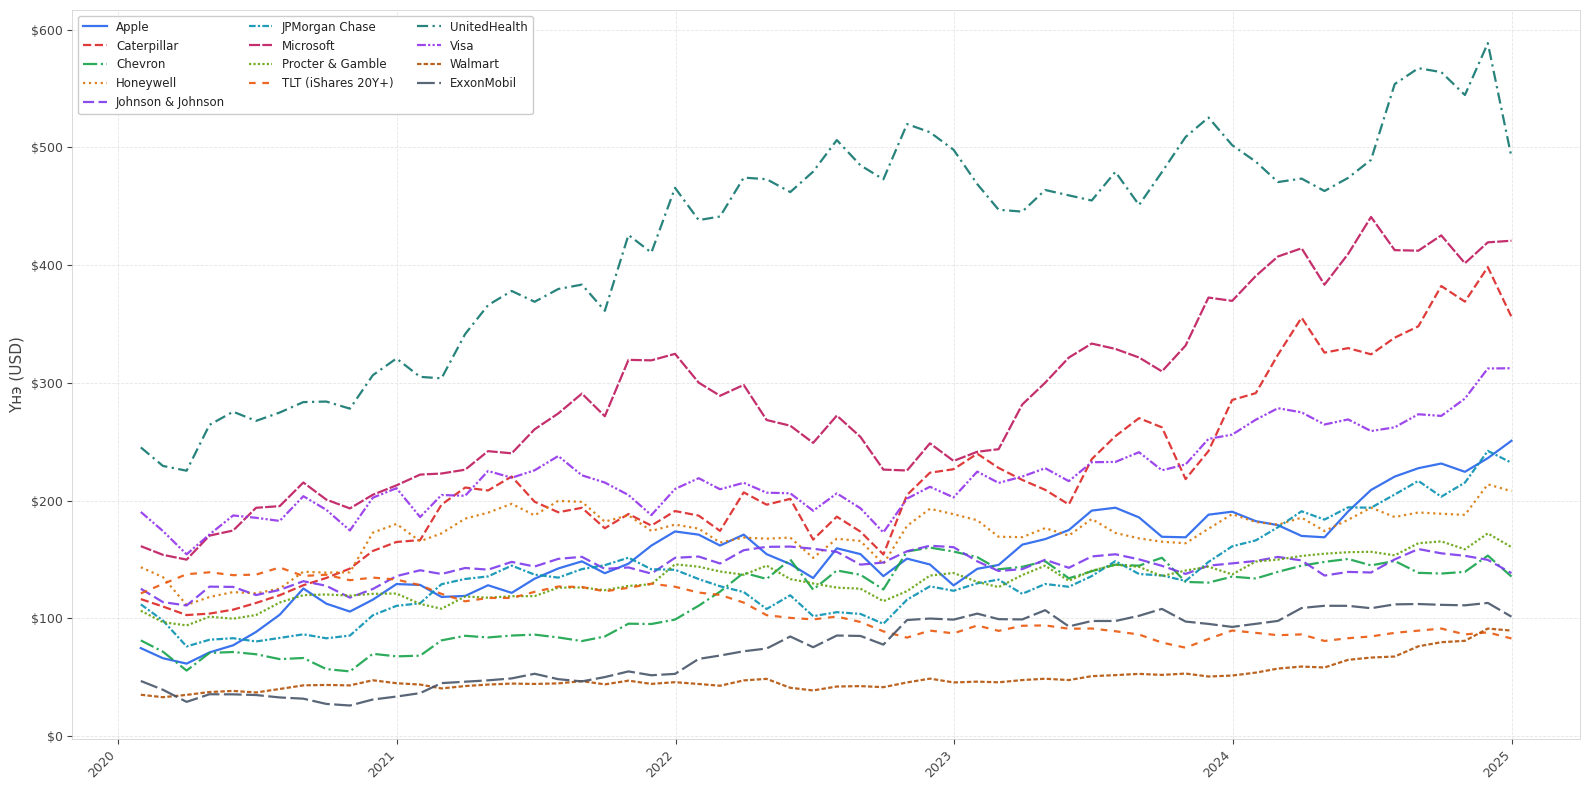

In [ ]:
"""
Stock Price Chart (2011–2024) — Үнийн цуваа
Суулгах: pip install yfinance matplotlib pandas
"""

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

TICKERS = {
    "Microsoft":          "MSFT",
    "Apple":              "AAPL",
    "JPMorgan Chase":     "JPM",
    "Visa":               "V",
    "Chevron":            "CVX",
    "ExxonMobil":         "XOM",
    "Caterpillar":        "CAT",
    "Honeywell":          "HON",
    "Procter & Gamble":   "PG",
    "Walmart":            "WMT",
    "Johnson & Johnson":  "JNJ",
    "UnitedHealth":       "UNH",
    "TLT (iShares 20Y+)": "TLT",
}

START = "2020-01-01"
END   = "2024-12-31"

# ── Өгөгдөл татах ─────────────────────────────────────────────────────────────
print("Өгөгдөл татаж байна…")
symbols = list(TICKERS.values())
raw = yf.download(symbols, start=START, end=END, auto_adjust=True)["Close"]

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

name_map = {v: k for k, v in TICKERS.items()}
raw = raw.rename(columns=name_map)

prices = raw.resample("ME").last().dropna(how="all")
names  = list(prices.columns)

print(f"Өгөгдөл бэлэн: {len(prices)} сар, {len(names)} хувьцаа")

# ── Өнгө / загвар ─────────────────────────────────────────────────────────────
COLORS = [
    "#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2",
    "#BE185D", "#65A30D", "#EA580C", "#0F766E", "#9333EA", "#B45309", "#475569"
]
LINESTYLES = [
    "-", "--", "-.", ":",
    (0, (5, 2)), (0, (3, 1, 1, 1)),
    (0, (5, 1)), (0, (1, 1)),
    (0, (3, 3)), (0, (5, 2, 1, 2)),
    (0, (4, 1, 1, 1, 1, 1)), (0, (2, 1)), (0, (8, 2))
]

# ── Зураг ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8), facecolor="white")
ax.set_facecolor("white")

for i, name in enumerate(names):
    ax.plot(
        prices.index, prices[name],
        color=COLORS[i % len(COLORS)],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        linewidth=1.6, label=name, alpha=0.9
    )

ax.set_ylabel("Үнэ (USD)", color="#444444", fontsize=11)
ax.set_xlabel("")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", color="#444444")
ax.tick_params(colors="#444444", labelsize=9)

ax.spines[:].set_color("#CCCCCC")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.grid(True, color="#E5E5E5", linewidth=0.6, linestyle="--")

# Тайлбар хүснэгт
ax.legend(
    loc="upper left", ncol=3, fontsize=8.5,
    facecolor="white", edgecolor="#CCCCCC",
    labelcolor="#222222", framealpha=1.0
)

plt.tight_layout()

out_path = "stock_price_2011_2024.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Зураг хадгалагдлаа: {out_path}")
plt.show()

[***************       31%                       ]  4 of 13 completed

Өгөгдөл татаж байна…


[*********************100%***********************]  13 of 13 completed


Өгөгдөл бэлэн: 60 сар, 13 хувьцаа
Зураг хадгалагдлаа: stock_return_2020_2024.png


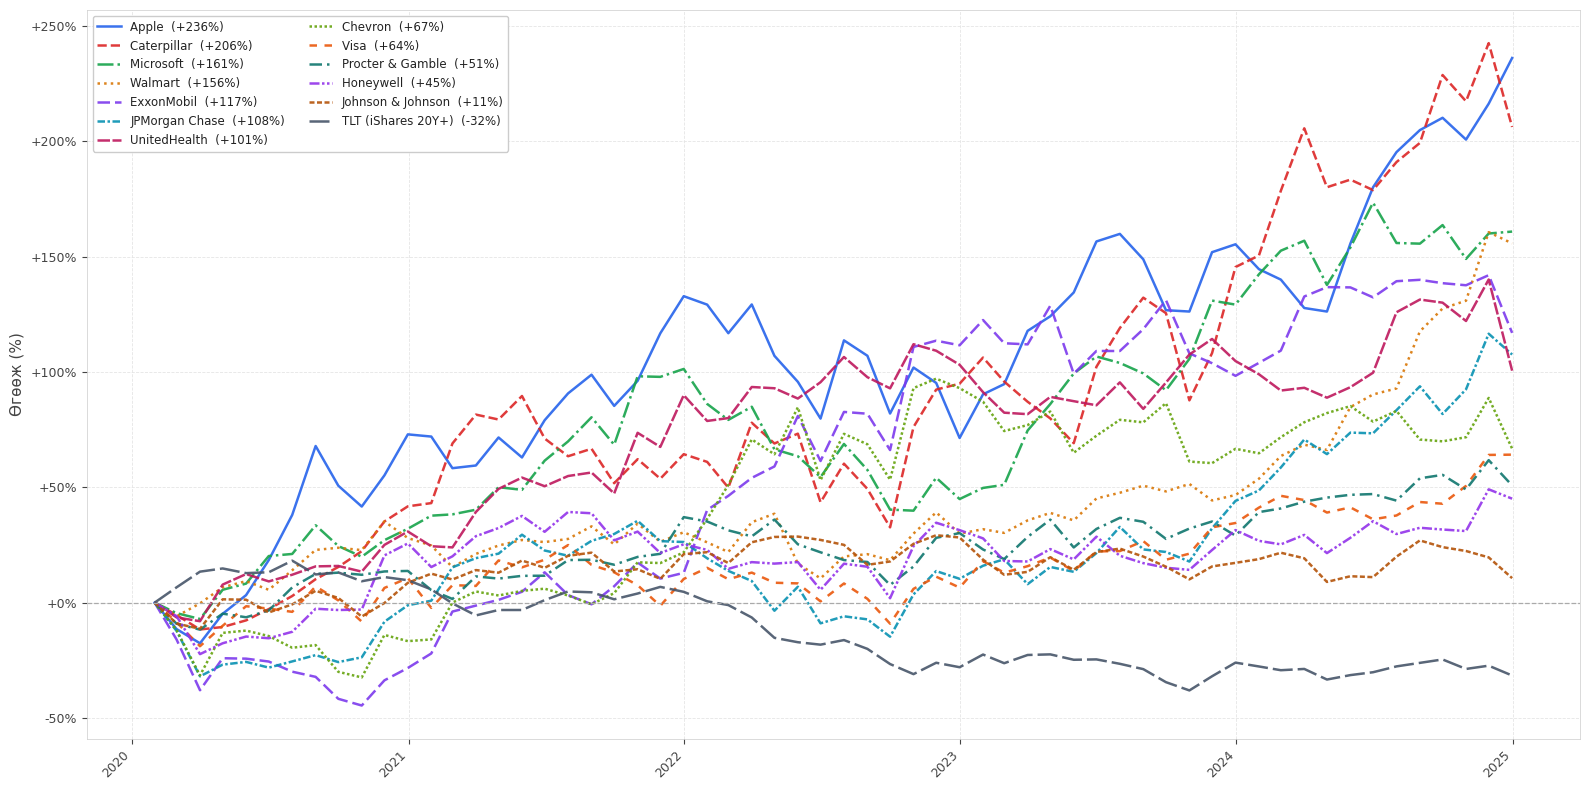


── 2024 оны эцсийн хуримтлагдсан өгөөж (2020-аас) ──
  Apple                     +  236.2%  ███████████
  Caterpillar               +  206.3%  ██████████
  Microsoft                 +  160.9%  ████████
  Walmart                   +  155.8%  ███████
  ExxonMobil                +  117.0%  █████
  JPMorgan Chase            +  107.6%  █████
  UnitedHealth              +  100.6%  █████
  Chevron                   +   66.8%  ███
  Visa                      +   64.2%  ███
  Procter & Gamble          +   50.8%  ██
  Honeywell                 +   45.1%  ██
  Johnson & Johnson         +   10.6%  
  TLT (iShares 20Y+)          -31.6%  █


In [ ]:
"""
Cumulative Return Chart (2020–2024)
====================================
Хуримтлагдсан өгөөжийн график — 2020 оны эхнээс
Суулгах: pip install yfinance matplotlib pandas
"""

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

TICKERS = {
    "Microsoft":          "MSFT",
    "Apple":              "AAPL",
    "JPMorgan Chase":     "JPM",
    "Visa":               "V",
    "Chevron":            "CVX",
    "ExxonMobil":         "XOM",
    "Caterpillar":        "CAT",
    "Honeywell":          "HON",
    "Procter & Gamble":   "PG",
    "Walmart":            "WMT",
    "Johnson & Johnson":  "JNJ",
    "UnitedHealth":       "UNH",
    "TLT (iShares 20Y+)": "TLT",
}

START = "2020-01-01"
END   = "2024-12-31"

# ── Өгөгдөл татах ─────────────────────────────────────────────────────────────
print("Өгөгдөл татаж байна…")
symbols = list(TICKERS.values())
raw = yf.download(symbols, start=START, end=END, auto_adjust=True)["Close"]

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

name_map = {v: k for k, v in TICKERS.items()}
raw = raw.rename(columns=name_map)

# Сарын сүүлийн өдөр
prices = raw.resample("ME").last().dropna(how="all")

# 2020 оны эхний утгаас хуримтлагдсан өгөөж (%)
returns = (prices / prices.iloc[0] - 1) * 100

# 2024 оны эцсийн өгөөжөөр эрэмбэлэх
final_vals = returns.iloc[-1].sort_values(ascending=False)
ordered_names = list(final_vals.index)

print(f"Өгөгдөл бэлэн: {len(prices)} сар, {len(ordered_names)} хувьцаа")

# ── Өнгө / загвар ─────────────────────────────────────────────────────────────
COLORS = [
    "#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2",
    "#BE185D", "#65A30D", "#EA580C", "#0F766E", "#9333EA", "#B45309", "#475569"
]
LINESTYLES = [
    "-", "--", "-.", ":",
    (0, (5, 2)), (0, (3, 1, 1, 1)),
    (0, (5, 1)), (0, (1, 1)),
    (0, (3, 3)), (0, (5, 2, 1, 2)),
    (0, (4, 1, 1, 1, 1, 1)), (0, (2, 1)), (0, (8, 2))
]

# ── Зураг ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8), facecolor="white")
ax.set_facecolor("white")

for i, name in enumerate(ordered_names):
    final_ret = final_vals[name]
    sign = "+" if final_ret >= 0 else ""
    ax.plot(
        returns.index, returns[name],
        color=COLORS[i % len(COLORS)],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        linewidth=1.8, alpha=0.9,
        label=f"{name}  ({sign}{final_ret:.0f}%)"
    )

# 0% суурь шугам
ax.axhline(0, color="#AAAAAA", linewidth=0.9, linestyle="--")

ax.set_ylabel("Өгөөж (%)", color="#444444", fontsize=11)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", color="#444444")
ax.tick_params(colors="#444444", labelsize=9)

ax.spines[:].set_color("#CCCCCC")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.grid(True, color="#E5E5E5", linewidth=0.6, linestyle="--")

# Тайлбар — 2024 эцсийн өгөөжөөр эрэмбэлэгдсэн
ax.legend(
    loc="upper left", ncol=2, fontsize=8.5,
    facecolor="white", edgecolor="#CCCCCC",
    labelcolor="#222222", framealpha=1.0
)

plt.tight_layout()

out_path = "stock_return_2020_2024.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Зураг хадгалагдлаа: {out_path}")
plt.show()

# ── Консол дээр эрэмбэ ────────────────────────────────────────────────────────
print("\n── 2024 оны эцсийн хуримтлагдсан өгөөж (2020-аас) ──")
for name, val in final_vals.items():
    bar = "█" * int(abs(val) / 20)
    sign = "+" if val >= 0 else ""
    print(f"  {name:<25} {sign}{val:>7.1f}%  {bar}")

In [ ]:
"""
Portfolio DRL v24 — 10-fold, gap=0, 6-month step
=================================================
v23-аас v24-д өөрчилсөн зүйл (ЗӨВХӨН fold structure):

  [V24] Fold structure шинэчлэл:
    TRAIN=8жил / VAL=6сар / TEST=6сар / STEP=6сар
    10 fold, test coverage 2020H1~2024H2
    gap=0: train_end+1 = val_start, val_end+1 = test_start
    давхцал=0

    Зорилго:
      v23-д val-test хооронд 1 жилийн gap байсан → 2022 Bear-д
      A2C=+2.0, PPO=+1.7, DDPG=+2.5 overfit илэрсэн.
      v24-д gap=0 болгон overfitting-ийг арилгана.

Өөрчлөгдөөгүй (v23-тай адил):
  Feature: 84 dim (13×6 ticker + 6 global)
  NET_ARCH: [512,256,128]
  REBALANCE_FREQ: 5
  Reward: DSR + entropy
  Алгоритм: A2C, PPO, DDPG + WTA
  TICKERS: 13 (+TLT)
  MAX_W=0.35, TC=0.001, ENT_BETA=0.005
  Diagnostics, checkpoint бүгд хэвээр

Ablation record:
  v21: DSR+Ent+DR  feat=102 N=12 NET=[256,128]  REB=daily  WTA=0.773 EW=0.971 beat=1/5
  v22: DSR+Ent     feat=72  N=13 NET=[256,128]  REB=daily  WTA=0.807 EW=0.913 beat=2/5
  v23: DSR+Ent     feat=84  N=13 NET=[512,256,128] REB=5d  WTA=1.014 EW=0.913 beat=3/5
  v24: DSR+Ent     feat=84  N=13 NET=[512,256,128] REB=5d  WTA=?     EW=?     beat=?/10

Шалгах зүйл (v24 дуусаад):
  - 2022H1, 2022H2 fold-д val-test gap буурсан уу?
    v23: gap=+2.0~+2.5 байсан → v24: <0.5 болвол зөв
  - beat: 3/5 → ?/10
  - EW-тэй харьцуулалт 10 fold-д

Google Drive: /content/drive/MyDrive/portfolio_drl_v24
"""

import os, json, random, time, warnings
from collections import deque
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v24"   # [V24] v24 болгов
    print("✓ Drive холбогдлоо")
except Exception:
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v24")  # [V24]
    print("⚠ Drive байхгүй — локал хадгална")

RESULT_DIR    = os.path.join(BASE_DIR, "results")
LOG_DIR       = os.path.join(BASE_DIR, "logs")
AGENT_DIR     = os.path.join(BASE_DIR, "agents")
DDPG_CKPT_DIR = os.path.join(BASE_DIR, "ddpg_ckpt")
CKPT_PATH     = os.path.join(BASE_DIR, "checkpoint.json")
FOLD_PROG_DIR = os.path.join(BASE_DIR, "fold_progress")
DIAG_DIR      = os.path.join(BASE_DIR, "diagnostics")

for d in [RESULT_DIR, LOG_DIR, AGENT_DIR, DDPG_CKPT_DIR, FOLD_PROG_DIR, DIAG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"→ {BASE_DIR}")


# ════════════════════════════════════════════════════════════════
# 0. ТОХИРГОО
# ════════════════════════════════════════════════════════════════
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)   # 13

TICKER_FEATURES = ["mom_20d", "vol_10d", "vol_20d",
                   "trend_200d", "ma_cross", "dd_peak60"]
N_TICKER_FEAT   = len(TICKER_FEATURES)  # 6

GLOBAL_FEATURES = ["turbulence_z", "mkt_ret_1d", "mkt_vol_20d",
                   "mkt_trend_60d", "mkt_dd_20d", "cross_corr"]

# ── [V24] FOLDS — gap=0, 10 fold, 6-month step ──────────────────
# compute_val_period() функц устгав — fold dict-д val шууд байна
# train_end + 1 өдөр = val_start
# val_end   + 1 өдөр = test_start
FOLDS = [
    {"name":  "2020H1",
     "train": ("2012-01-01", "2019-06-30"),
     "val":   ("2019-07-01", "2019-12-31"),
     "test":  ("2020-01-01", "2020-06-30"),
     "label": "2020 COVID H1"},

    {"name":  "2020H2",
     "train": ("2012-07-01", "2019-12-31"),
     "val":   ("2020-01-01", "2020-06-30"),
     "test":  ("2020-07-01", "2020-12-31"),
     "label": "2020 COVID H2"},

    {"name":  "2021H1",
     "train": ("2013-01-01", "2020-06-30"),
     "val":   ("2020-07-01", "2020-12-31"),
     "test":  ("2021-01-01", "2021-06-30"),
     "label": "2021 Bull H1"},

    {"name":  "2021H2",
     "train": ("2013-07-01", "2020-12-31"),
     "val":   ("2021-01-01", "2021-06-30"),
     "test":  ("2021-07-01", "2021-12-31"),
     "label": "2021 Bull H2"},

    {"name":  "2022H1",
     "train": ("2014-01-01", "2021-06-30"),
     "val":   ("2021-07-01", "2021-12-31"),
     "test":  ("2022-01-01", "2022-06-30"),
     "label": "2022 Bear H1"},

    {"name":  "2022H2",
     "train": ("2014-07-01", "2021-12-31"),
     "val":   ("2022-01-01", "2022-06-30"),
     "test":  ("2022-07-01", "2022-12-31"),
     "label": "2022 Bear H2"},

    {"name":  "2023H1",
     "train": ("2015-01-01", "2022-06-30"),
     "val":   ("2022-07-01", "2022-12-31"),
     "test":  ("2023-01-01", "2023-06-30"),
     "label": "2023 Recovery H1"},

    {"name":  "2023H2",
     "train": ("2015-07-01", "2022-12-31"),
     "val":   ("2023-01-01", "2023-06-30"),
     "test":  ("2023-07-01", "2023-12-31"),
     "label": "2023 Recovery H2"},

    {"name":  "2024H1",
     "train": ("2016-01-01", "2023-06-30"),
     "val":   ("2023-07-01", "2023-12-31"),
     "test":  ("2024-01-01", "2024-06-30"),
     "label": "2024 AI Rally H1"},

    {"name":  "2024H2",
     "train": ("2016-07-01", "2023-12-31"),
     "val":   ("2024-01-01", "2024-06-30"),
     "test":  ("2024-07-01", "2024-12-31"),
     "label": "2024 AI Rally H2"},
]

DATA_START       = "2009-01-01"
INIT_CAP         = 1_000_000
MAX_W            = 0.35
TC               = 0.001
NORM_WIN         = 252
DSR_ETA          = 0.01
DSR_CLIP         = 10.0
SB3_STEPS        = 500_000
NET_ARCH         = [512, 256, 128]

A2C_N_STEPS      = 252
A2C_ENT_COEF     = 0.05
A2C_N_ENVS       = 1
PPO_N_STEPS      = 256
PPO_BATCH_SIZE   = 256
PPO_N_EPOCHS     = 20
PPO_LR           = 5e-5
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP         = 0.15
PPO_ENT_COEF     = 0.02
PPO_TARGET_KL    = None
PPO_N_ENVS       = 8

DDPG_EP          = 100
DDPG_BATCH       = 64
DDPG_BUF         = 50_000
DDPG_GAMMA       = 0.99
DDPG_TAU         = 0.005
DDPG_LR          = 3e-4
DDPG_PAT         = 5
DDPG_VAL_FREQ    = 10
DDPG_SMOOTH      = 3
DDPG_SIGMA_START = 0.15
DDPG_SIGMA_END   = 0.02

PORT_RET_WINDOWS = [5, 20]
PORT_RET_CLIP    = 0.3
ENT_BETA         = 0.005
TRAIN_WINDOW_YEARS = 8
REBALANCE_FREQ   = 5

REMOVED_FEATURES = ["vol_ratio"]
ADDED_FEATURES   = ["vol_20d"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}  |  N={N}  |  Seed={SEED}")
print(f"feat: {N*N_TICKER_FEAT}+{len(GLOBAL_FEATURES)}="
      f"{N*N_TICKER_FEAT+len(GLOBAL_FEATURES)} dim")
print(f"Weekly rebalance: REBALANCE_FREQ={REBALANCE_FREQ}")
print(f"NET_ARCH={NET_ARCH}")
print(f"[V24] 10 fold / gap=0 / 6-month step")
print(f"ENT_BETA={ENT_BETA} | MAX_W={MAX_W} | TC={TC}")


# ════════════════════════════════════════════════════════════════
# DIAGNOSTICS RECORDER
# ════════════════════════════════════════════════════════════════
class DiagnosticsRecorder:
    def __init__(self, fold_name, fold_label):
        self.fold_name  = fold_name
        self.fold_label = fold_label
        self.data = {
            "fold": fold_name, "label": fold_label, "version": "v24",  # [V24]
            "timestamp": datetime.now().isoformat(),
            "config": {
                "tickers": TICKERS, "n": N,
                "ticker_features": TICKER_FEATURES,
                "global_features": GLOBAL_FEATURES,
                "feat_dim": N*N_TICKER_FEAT + len(GLOBAL_FEATURES),
                "rebalance_freq": REBALANCE_FREQ,
                "net_arch": NET_ARCH,
                "ent_beta": ENT_BETA, "max_w": MAX_W, "tc": TC,
                "added": ADDED_FEATURES, "removed": REMOVED_FEATURES,
                "ddpg_pat": DDPG_PAT, "sb3_steps": SB3_STEPS,
                "fold_gap": 0,          # [V24] gap=0
                "fold_step": "6mo",     # [V24] 6-month step
            },
            "periods": {}, "ddpg_training": {}, "val_test_gap": {},
            "ew_diagnostics": {}, "regime_analysis": {},
            "agent_performance": {}, "winner_history": {},
            "tlt_allocation": {}, "turnover_stats": {},
            "warnings": [], "recommendations": [],
        }

    def record_periods(self, train_start, train_end, val_start, val_end,
                       test_start, test_end, train_days, val_days, test_days):
        self.data["periods"] = {
            "train": {"start": str(train_start), "end": str(train_end), "days": train_days},
            "val":   {"start": str(val_start),   "end": str(val_end),   "days": val_days},
            "test":  {"start": str(test_start),  "end": str(test_end),  "days": test_days},
        }

    def record_ddpg_episode(self, ep, train_r, val_sh, smooth, best,
                             no_imp, sigma, buf, stop_reason=None):
        if "episodes" not in self.data["ddpg_training"]:
            self.data["ddpg_training"]["episodes"] = []
        self.data["ddpg_training"]["episodes"].append({
            "ep": ep, "train_reward": round(float(train_r), 4),
            "val_sharpe": round(float(val_sh), 4),
            "smooth_val": round(float(smooth), 4),
            "best_val":   round(float(best), 4),
            "no_imp": int(no_imp), "sigma": round(float(sigma), 4),
            "buf_size": int(buf),
        })
        if stop_reason:
            self.data["ddpg_training"]["stop_reason"] = stop_reason

    def record_ddpg_summary(self, total_eps, best_val, early_stopped,
                             stop_reason, val_eval_count):
        self.data["ddpg_training"].update({
            "total_episodes":  int(total_eps),
            "best_val_sharpe": round(float(best_val), 4),
            "early_stopped":   bool(early_stopped),
            "stop_reason":     stop_reason,
            "val_eval_count":  int(val_eval_count),
            "completion_pct":  round(total_eps / DDPG_EP * 100, 1),
        })
        if total_eps < 20:
            self.data["warnings"].append(f"DDPG {total_eps} ep — хангалтгүй")

    def record_val_test_gap(self, algo, val_s, test_s):
        gap = val_s - test_s
        self.data["val_test_gap"][algo] = {
            "val_sharpe":  round(float(val_s), 4),
            "test_sharpe": round(float(test_s), 4),
            "gap":         round(float(gap), 4),
            "overfit":     bool(gap > 0.5),
        }
        if abs(gap) > 0.5:
            self.data["warnings"].append(f"{algo} gap={gap:+.3f} overfit")

    def record_ew_diag(self, algo, hhi, ew_dev, turnover, is_clone):
        self.data["ew_diagnostics"][algo] = {
            "hhi_mean":  round(float(hhi), 4),
            "ew_dev":    round(float(ew_dev), 4),
            "turnover":  round(float(turnover), 4),
            "ew_clone":  bool(is_clone),
        }
        if is_clone:
            self.data["warnings"].append(f"{algo} EW clone")

    def record_tlt(self, algo, wh_list):
        tlt_idx = TICKERS.index("TLT")
        tw = [w[tlt_idx] for w in wh_list]
        self.data["tlt_allocation"][algo] = {
            "mean": round(float(np.mean(tw)), 4),
            "max":  round(float(np.max(tw)), 4),
            "std":  round(float(np.std(tw)), 4),
        }

    def record_turnover(self, algo, wh_list):
        if len(wh_list) < 2: return
        W = np.array(wh_list)
        daily_to = np.array([np.sum(np.abs(W[i] - W[i-1]))
                              for i in range(1, len(W))])
        self.data["turnover_stats"][algo] = {
            "mean_daily_to": round(float(daily_to.mean()), 4),
            "max_daily_to":  round(float(daily_to.max()), 4),
            "rebal_days_pct": round(float((daily_to > 0.05).mean() * 100), 1),
        }

    def record_perf(self, algo, sh, cagr_v, maxdd_v, calmar_v, ew_sh):
        self.data["agent_performance"][algo] = {
            "sharpe":    round(float(sh), 4),
            "cagr_pct":  round(float(cagr_v) * 100, 2),
            "maxdd_pct": round(float(maxdd_v) * 100, 2),
            "calmar":    round(float(calmar_v), 4),
            "beat_ew":   bool(sh > ew_sh),
        }

    def record_winner(self, winner, val_scores):
        self.data["winner_history"] = {
            "winner":     winner,
            "val_scores": {k: round(float(v), 4) for k, v in val_scores.items()},
        }

    def analyze_regime(self, test_rets):
        r = np.array(test_rets)
        cum = float((1 + r).prod() - 1)
        regime = "bear" if cum < -0.1 else "bull" if cum > 0.15 else "sideways"
        self.data["regime_analysis"] = {
            "cum_return":  round(cum, 4),
            "ann_vol":     round(float(r.std() * np.sqrt(252)), 4),
            "neg_day_pct": round(float((r < 0).mean()), 4),
            "regime":      regime,
        }
        return regime

    def generate_recs(self):
        recs = []
        if self.data.get("ddpg_training", {}).get("total_episodes", 100) < 30:
            recs.append("DDPG хангалтгүй — EP нэмэх")
        for a, g in self.data.get("val_test_gap", {}).items():
            if g.get("overfit"):
                recs.append(f"{a} overfit — gap={g['gap']:+.3f} (v24-д буурсан байх ёстой)")
        if any(v.get("ew_clone") for v in self.data.get("ew_diagnostics", {}).values()):
            recs.append("EW clone хэвээр → ENT_BETA нэмэх (v25)")
        for a, t in self.data.get("turnover_stats", {}).items():
            if t.get("mean_daily_to", 0) > 0.15:
                recs.append(f"{a} TO={t['mean_daily_to']:.3f} өндөр")
        self.data["recommendations"] = recs

    def save(self):
        self.generate_recs()
        path = os.path.join(DIAG_DIR, f"diag_{self.fold_name}.json")
        tmp  = path + ".tmp"
        with open(tmp, "w", encoding="utf-8") as f:
            json.dump(self.data, f, indent=2, ensure_ascii=False)
        os.replace(tmp, path)
        print(f"  📊 Diagnostics → diag_{self.fold_name}.json")
        for w in self.data["warnings"]:       print(f"  ⚠ {w}")
        for r in self.data["recommendations"]: print(f"  💡 {r}")

    @staticmethod
    def load_all():
        recs = []
        if not os.path.isdir(DIAG_DIR): return recs
        for f in sorted(os.listdir(DIAG_DIR)):
            if f.startswith("diag_") and f.endswith(".json"):
                with open(os.path.join(DIAG_DIR, f), encoding="utf-8") as fh:
                    recs.append(json.load(fh))
        return recs

    @staticmethod
    def print_summary():
        recs = DiagnosticsRecorder.load_all()
        if not recs: return
        print("\n" + "=" * 72)
        print("  DIAGNOSTICS SUMMARY — v24")
        print("=" * 72)
        for d in recs:
            print(f"\n  [{d['label']}]")
            dt = d.get("ddpg_training", {})
            ep_info = ("early: " + dt.get("stop_reason", "")
                       if dt.get("early_stopped") else "completed")
            print(f"  DDPG: {dt.get('total_episodes','?')}/{DDPG_EP} ({ep_info})")
            for a, g in d.get("val_test_gap", {}).items():
                flag = "⚠ OVERFIT" if g.get("overfit") else "OK"
                print(f"  {a} gap: {g.get('gap', 0):+.3f} {flag}")
            tlt = d.get("tlt_allocation", {})
            if tlt:
                tlt_str = ", ".join([f"{a}={v['mean']:.3f}" for a, v in tlt.items()])
                print(f"  TLT: {tlt_str}")
            to = d.get("turnover_stats", {})
            if to:
                to_str = ", ".join([f"{a}={v['mean_daily_to']:.3f}" for a, v in to.items()])
                print(f"  TO:  {to_str}")
            for w in d.get("warnings", []): print(f"  ⚠ {w}")
        print("=" * 72)


def save_combined_diag(all_results):
    recs  = DiagnosticsRecorder.load_all()
    algos = ["A2C", "PPO", "DDPG", "WTA", "EW"]
    agg   = {}
    for a in algos:
        sharpes = [res[a]["sharpe"] for res in all_results.values() if a in res]
        if sharpes:
            agg[a] = {
                "mean_sharpe": round(float(np.mean(sharpes)), 4),
                "std_sharpe":  round(float(np.std(sharpes)), 4),
                "beat_ew_pct": round(
                    sum(1 for res in all_results.values()
                        if a in res and "EW" in res
                        and res[a]["sharpe"] > res["EW"]["sharpe"])
                    / len(all_results) * 100, 1),
            }
    combined = {
        "version":   "v24",   # [V24]
        "timestamp": datetime.now().isoformat(),
        "config": {
            "tickers":         TICKERS, "n": N,
            "ticker_features": TICKER_FEATURES,
            "global_features": GLOBAL_FEATURES,
            "feat_dim":        N * N_TICKER_FEAT + len(GLOBAL_FEATURES),
            "net_arch":        NET_ARCH,
            "rebalance_freq":  REBALANCE_FREQ,
            "fold_count":      len(FOLDS),   # [V24] 10
            "fold_gap":        0,            # [V24]
            "fold_step":       "6mo",        # [V24]
        },
        "folds": recs, "aggregate": agg,
    }
    path = os.path.join(DIAG_DIR, "v24_combined_diagnostics.json")   # [V24]
    with open(path, "w", encoding="utf-8") as f:
        json.dump(combined, f, indent=2, ensure_ascii=False)
    print(f"  📊 Combined → v24_combined_diagnostics.json")


# ════════════════════════════════════════════════════════════════
# FOLD PROGRESS
# ════════════════════════════════════════════════════════════════
def _prog_path(fn): return os.path.join(FOLD_PROG_DIR, f"{fn}_progress.json")

def load_fold_progress(fn):
    p = _prog_path(fn)
    if not os.path.exists(p):
        return {"done_algos": [], "val_sh": {}, "res": {}, "ew_diags": {}}
    with open(p) as f: d = json.load(f)
    print(f"  ↺ [{fn}] resume: {d['done_algos']}"); return d

def save_fold_progress(fn, done, val_sh, res, ew_diags):
    def _scalar(v):
        if isinstance(v, np.ndarray):     return v.tolist()
        if isinstance(v, (np.floating,)): return float(v)
        if isinstance(v, (np.integer,)):  return int(v)
        if isinstance(v, (np.bool_,)):    return bool(v)
        return v
    def _j(r): return {k: _scalar(v) for k, v in r.items() if k != "wh"}
    def _j_ew(d):
        if not isinstance(d, dict): return {}
        return {k: _scalar(v) for k, v in d.items()}
    tmp = _prog_path(fn) + ".tmp"
    with open(tmp, "w") as f:
        json.dump({"done_algos": done, "val_sh": val_sh,
                   "res": {a: _j(r) for a, r in res.items()},
                   "ew_diags": {a: _j_ew(d) for a, d in ew_diags.items()}}, f)
    os.replace(tmp, _prog_path(fn))

def clear_fold_progress(fn):
    p = _prog_path(fn)
    if os.path.exists(p): os.remove(p)

def _from_json(d):
    return {k: np.array(v) if isinstance(v, list) else v for k, v in d.items()}


# ════════════════════════════════════════════════════════════════
# 1. FEATURE (v23-тай адил — 84 dim)
# ════════════════════════════════════════════════════════════════
def _turb(ret_df, lb=252):
    t = pd.Series(0.0, index=ret_df.index)
    for i in range(lb, len(ret_df)):
        h = ret_df.iloc[i-lb:i]; mu = h.mean().values
        try: cov = np.linalg.inv(h.cov().values + np.eye(h.shape[1]) * 1e-6)
        except: continue
        y = ret_df.iloc[i].values - mu; t.iloc[i] = float(y @ cov @ y)
    pos = t > 0
    me  = t.where(pos).expanding().mean().ffill().fillna(0)
    sd  = t.where(pos).expanding().std().ffill().fillna(1).replace(0, 1)
    return ((t - me) / sd).clip(-5, 10)

def build_features(close):
    ret = close.pct_change().fillna(0)
    mkt = ret.mean(axis=1)
    blocks = []

    for tk in TICKERS:
        c, r  = close[tk], ret[tk]
        ma60  = c.rolling(60).mean()
        ma200 = c.rolling(200).mean()
        pk60  = c.rolling(60).max()

        b = pd.DataFrame({
            f"{tk}_mom_20d"   : r.rolling(20).sum(),
            f"{tk}_vol_10d"   : r.rolling(10).std() * np.sqrt(252),
            f"{tk}_vol_20d"   : r.rolling(20).std() * np.sqrt(252),
            f"{tk}_trend_200d": (c / (ma200 + 1e-9) - 1).clip(-0.5, 0.5),
            f"{tk}_ma_cross"  : (ma60 / (ma200 + 1e-9) - 1).clip(-0.3, 0.3),
            f"{tk}_dd_peak60" : ((c - pk60) / (pk60 + 1e-9)),
        }, index=close.index)
        blocks.append(b)

    turb = _turb(ret)

    mkt_cum    = (1 + mkt).cumprod()
    pk20       = mkt_cum.rolling(20).max()
    mkt_dd_20d = ((mkt_cum - pk20) / (pk20 + 1e-9)).clip(-1, 0)

    ret_eq     = ret[EQUITY_TICKERS]
    cross_corr = pd.Series(0.0, index=close.index)
    for i in range(20, len(close)):
        sub  = ret_eq.iloc[i-20:i]
        corr = sub.corr().values
        mask = ~np.eye(len(EQUITY_TICKERS), dtype=bool)
        cross_corr.iloc[i] = float(corr[mask].mean())

    glob = pd.DataFrame({
        "turbulence_z" : turb,
        "mkt_ret_1d"   : mkt,
        "mkt_vol_20d"  : mkt.rolling(20).std() * np.sqrt(252),
        "mkt_trend_60d": mkt.rolling(60).sum().clip(-0.3, 0.3),
        "mkt_dd_20d"   : mkt_dd_20d,
        "cross_corr"   : cross_corr,
    }, index=close.index)

    feat = pd.concat(blocks + [glob], axis=1).replace([np.inf, -np.inf], np.nan)
    idx  = feat.dropna().index
    feat = feat.loc[idx]; price = close.loc[idx]; turb_s = turb.loc[idx]
    mu   = feat.rolling(NORM_WIN, min_periods=60).mean()
    sd   = feat.rolling(NORM_WIN, min_periods=60).std().replace(0, 1).fillna(1)
    nf   = ((feat - mu) / sd).clip(-5, 5).fillna(0).astype(np.float32)

    expected_dim = N * N_TICKER_FEAT + len(GLOBAL_FEATURES)
    assert nf.shape[1] == expected_dim, \
        f"feat_dim mismatch: {nf.shape[1]} ≠ {expected_dim}"

    print(f"   Feature: {nf.shape[1]}-dim × {len(nf)} өдөр")
    print(f"   Ticker: {N}×{N_TICKER_FEAT}={N*N_TICKER_FEAT}  "
          f"Global: {len(GLOBAL_FEATURES)}")
    return nf, price, turb_s

def slice_data(feat, price, turb, s, e):
    m = (feat.index >= s) & (feat.index <= e)
    return feat[m], price[m], turb[m]


# ════════════════════════════════════════════════════════════════
# 2. REWARD — DSR + entropy (v23-тай адил)
# ════════════════════════════════════════════════════════════════
def _dsr_reward(ret, A, B):
    An  = (1 - DSR_ETA) * A + DSR_ETA * ret
    Bn  = (1 - DSR_ETA) * B + DSR_ETA * ret * ret
    D   = B - A * A
    dsr = float(An - A) if D < 1e-8 else \
          float((B * (An - A) - 0.5 * A * (Bn - B)) / (D ** 1.5))
    return float(np.clip(dsr, -DSR_CLIP, DSR_CLIP)), An, Bn


# ════════════════════════════════════════════════════════════════
# 3. ENVIRONMENT (v23-тай адил — weekly rebalance)
# ════════════════════════════════════════════════════════════════
def _softmax(x): ex = np.exp(x - x.max()); return ex / ex.sum()

def _clip_w(w, mx=MAX_W):
    w = w.copy()
    for _ in range(10):
        exc = np.maximum(w - mx, 0)
        if exc.sum() < 1e-8: break
        w = np.minimum(w, mx); bl = w < mx
        if bl.sum() == 0: break
        w[bl] += exc.sum() / bl.sum()
    return w / (w.sum() + 1e-9)

class PortfolioEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, price_df, feat_df, turb_s, init_cap=INIT_CAP, mode="train"):
        super().__init__()
        self.prices = price_df.values; self.feats = feat_df.values
        self.T = len(price_df) - 1; self.cap = init_cap; self.mode = mode
        self._alpha = 1.0 / REBALANCE_FREQ

        obs_dim = feat_df.shape[1] + N + 3 + len(PORT_RET_WINDOWS)
        self.observation_space = spaces.Box(-np.inf, np.inf, (obs_dim,), np.float32)
        self.action_space = spaces.Box(-1.5, 1.5, (N,), np.float32)
        self.reset()

    def _port_ret_win(self, window):
        n = len(self._lrh)
        if n == 0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window, n):]),
                             -PORT_RET_CLIP, PORT_RET_CLIP))

    def _obs(self):
        f = self.feats[self.t].copy()
        extras = np.array([
            float(self.pv / self.cap),
            float((self.peak - self.pv) / (self.peak + 1e-9)),
            float(self.t / max(self.T, 1)),
        ] + [self._port_ret_win(w) for w in PORT_RET_WINDOWS], dtype=np.float32)
        return np.concatenate([f, self.w, extras]).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.t = int(np.random.randint(0, max(1, self.T // 3) + 1)) \
                 if self.mode == "train" else 0
        self.pv = float(self.cap); self.peak = float(self.cap)
        self.w  = np.ones(N) / N
        self.target_w = np.ones(N) / N
        self.dsr_A = 0.0; self.dsr_B = 1e-8
        self._lrh = deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(), {}

    def step(self, action):
        if self.t % REBALANCE_FREQ == 0:
            self.target_w = _clip_w(_softmax(action), MAX_W)

        new_w   = self.w + self._alpha * (self.target_w - self.w)
        new_w   = new_w / (new_w.sum() + 1e-9)
        tc_cost = TC * np.abs(new_w - self.w).sum()
        p0, p1  = self.prices[self.t], self.prices[self.t + 1]
        port_ret = float(np.dot(new_w, (p1 - p0) / (p0 + 1e-9))) - tc_cost
        self.pv *= (1 + port_ret); self.peak = max(self.peak, self.pv)
        log_ret  = float(np.log1p(port_ret))

        reward, self.dsr_A, self.dsr_B = _dsr_reward(log_ret, self.dsr_A, self.dsr_B)
        w_ent  = float(-np.sum(np.clip(self.w, 1e-8, 1) * np.log(np.clip(self.w, 1e-8, 1))))
        reward += ENT_BETA * (w_ent / np.log(N))

        self._lrh.append(log_ret)
        self.w = new_w; self.t += 1
        done = self.t >= self.T
        return self._obs(), reward, done, False, {"pv": self.pv, "ret": port_ret, "w": new_w}


# ════════════════════════════════════════════════════════════════
# 4. DDPG (v23-тай адил)
# ════════════════════════════════════════════════════════════════
class _Actor(nn.Module):
    def __init__(self, sd, ad):
        super().__init__()
        l = []; d = sd
        for h in NET_ARCH:
            l += [nn.Linear(d, h), nn.LayerNorm(h), nn.ReLU()]; d = h
        l.append(nn.Linear(d, ad)); self.net = nn.Sequential(*l)
    def forward(self, x): return torch.tanh(self.net(x)) * 1.5

class _Critic(nn.Module):
    def __init__(self, sd, ad):
        super().__init__()
        self.obs_net = nn.Sequential(nn.Linear(sd, 512), nn.ReLU(),
                                     nn.Linear(512, 256), nn.ReLU())
        self.out_net = nn.Sequential(nn.Linear(256 + ad, 128), nn.ReLU(),
                                     nn.Linear(128, 1))
    def forward(self, s, a):
        return self.out_net(torch.cat([self.obs_net(s), a], dim=1))

class _OUNoise:
    def __init__(self, n, theta=0.15, sigma=0.1):
        self.mu = np.zeros(n, np.float32); self.theta = theta
        self.sigma = sigma; self.reset()
    def reset(self): self.s = self.mu.copy()
    def sample(self):
        dx = (self.theta * (self.mu - self.s) +
              self.sigma * np.random.randn(len(self.mu)).astype(np.float32))
        self.s += dx; return self.s

def _soft(net, tgt, tau=DDPG_TAU):
    for p, tp in zip(net.parameters(), tgt.parameters()):
        tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

def _ddpg_paths(fn):
    return {"state": os.path.join(DDPG_CKPT_DIR, f"{fn}_state.json"),
            "best":  os.path.join(DDPG_CKPT_DIR, f"{fn}_best.pt")}

def _save_ddpg(fn, ep, best_v, val_hist, best_sd, no_imp):
    p = _ddpg_paths(fn)
    if best_sd: torch.save(best_sd, p["best"])
    with open(p["state"], "w") as f:
        json.dump({"ep": int(ep), "best_v": float(best_v),
                   "val_hist": [float(x) for x in val_hist],
                   "no_imp": int(no_imp)}, f)

def _load_ddpg(fn):
    p = _ddpg_paths(fn)
    if not os.path.exists(p["state"]): return 0, -np.inf, [], None, 0
    try:
        with open(p["state"]) as f: d = json.load(f)
        sd = (torch.load(p["best"], map_location=DEVICE)
              if os.path.exists(p["best"]) else None)
        print(f"      ↺ DDPG resume ep={d['ep']+1} best={d['best_v']:+.3f} "
              f"no_imp={d.get('no_imp', 0)}")
        return int(d["ep"]) + 1, float(d["best_v"]), list(d["val_hist"]), sd, \
               int(d.get("no_imp", 0))
    except Exception as e:
        print(f"      ⚠ ckpt err: {e}"); return 0, -np.inf, [], None, 0

def _clear_ddpg(fn):
    for p in _ddpg_paths(fn).values():
        if os.path.exists(p):
            try: os.remove(p)
            except: pass

def train_ddpg(tf, tp, tt, vf, vp, vt, obs_dim, fold_name, diag):
    actor  = _Actor(obs_dim, N).to(DEVICE); critic  = _Critic(obs_dim, N).to(DEVICE)
    at     = _Actor(obs_dim, N).to(DEVICE); at.load_state_dict(actor.state_dict())
    ct     = _Critic(obs_dim, N).to(DEVICE); ct.load_state_dict(critic.state_dict())
    opt_a  = optim.Adam(actor.parameters(), lr=DDPG_LR)
    opt_c  = optim.Adam(critic.parameters(), lr=DDPG_LR)
    buf    = deque(maxlen=DDPG_BUF)

    start_ep, best_v, val_hist, res_sd, no_imp = _load_ddpg(fold_name)
    if res_sd: actor.load_state_dict(res_sd); at.load_state_dict(res_sd)
    best_sd = res_sd; log = []; val_cnt = len(val_hist)
    early_stopped = False; stop_reason = "completed"
    print(f"      PAT={DDPG_PAT} val-eval | FREQ={DDPG_VAL_FREQ} | "
          f"NET={NET_ARCH} | REB={REBALANCE_FREQ}d")

    for ep in range(start_ep, DDPG_EP):
        sig   = max(DDPG_SIGMA_END, DDPG_SIGMA_START * (1 - ep / DDPG_EP))
        noise = _OUNoise(N, sigma=sig)
        env   = PortfolioEnv(tp, tf, tt, mode="train")
        obs, _ = env.reset(); noise.reset(); ep_r = 0.0; done = False

        while not done:
            with torch.no_grad():
                a = actor(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
            a = np.clip(a + noise.sample(), -1.5, 1.5).astype(np.float32)
            nobs, r, term, trunc, _ = env.step(a)
            buf.append((obs.astype(np.float32), a, np.float32(r),
                        nobs.astype(np.float32), np.float32(term or trunc)))
            obs = nobs; ep_r += r; done = term or trunc

            if len(buf) >= DDPG_BATCH:
                B = random.sample(buf, DDPG_BATCH)
                S, A, R, NS, D = map(np.array, zip(*B))
                S  = torch.FloatTensor(S).to(DEVICE);  A  = torch.FloatTensor(A).to(DEVICE)
                R  = torch.FloatTensor(R).unsqueeze(1).to(DEVICE)
                NS = torch.FloatTensor(NS).to(DEVICE)
                D  = torch.FloatTensor(D).unsqueeze(1).to(DEVICE)
                with torch.no_grad(): q_t = R + DDPG_GAMMA * (1 - D) * ct(NS, at(NS))
                lc = nn.MSELoss()(critic(S, A), q_t)
                opt_c.zero_grad(); lc.backward(); opt_c.step()
                la = -critic(S, actor(S)).mean()
                opt_a.zero_grad(); la.backward(); opt_a.step()
                _soft(actor, at); _soft(critic, ct)

        if (ep + 1) % DDPG_VAL_FREQ == 0:
            val_rets = []; ve = PortfolioEnv(vp, vf, vt, mode="test")
            vo, _ = ve.reset(); vd = False; actor.eval()
            while not vd:
                with torch.no_grad():
                    va = actor(torch.FloatTensor(vo).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
                vo, _, t2, tr2, info = ve.step(va)
                val_rets.append(info["ret"]); vd = t2 or tr2
            actor.train()
            vr = sharpe(np.array(val_rets)); val_hist.append(vr); val_cnt += 1
            smooth = float(np.mean(val_hist[-DDPG_SMOOTH:]))
            log.append({"ep": ep+1, "train": round(ep_r, 4),
                        "val_sharpe": round(vr, 4), "smooth_val": round(smooth, 4),
                        "sigma": round(sig, 4), "buf_size": len(buf), "no_imp": no_imp})
            if smooth > best_v:
                best_v = smooth; no_imp = 0
                best_sd = {k: v.clone() for k, v in actor.state_dict().items()}
                _save_ddpg(fold_name, ep, best_v, val_hist, best_sd, no_imp); flag = "↑ BEST"
            else:
                no_imp += 1; _save_ddpg(fold_name, ep, best_v, val_hist, best_sd, no_imp)
                flag = f"noImp={no_imp}/{DDPG_PAT}"
            print(f"      ep{ep+1:>3} [#{val_cnt:>2}] σ={sig:.3f} "
                  f"tr:{ep_r:+.3f} val:{vr:+.3f} sm:{smooth:+.3f} "
                  f"best:{best_v:+.3f} {flag}")
            sr = (f"no_imp={no_imp}>={DDPG_PAT}" if no_imp >= DDPG_PAT else None)
            diag.record_ddpg_episode(ep+1, ep_r, vr, smooth, best_v, no_imp, sig, len(buf), sr)
            if no_imp >= DDPG_PAT:
                stop_reason = f"no_imp={no_imp}>={DDPG_PAT}"
                early_stopped = True
                print(f"      ⏹ Early stop @ep{ep+1}"); break
        else:
            if (ep + 1) % 20 == 0:
                print(f"      ep{ep+1:>3} σ={sig:.3f} buf={len(buf)} tr:{ep_r:+.3f}")

    total = ep + 1 if 'ep' in dir() else 0
    diag.record_ddpg_summary(total, best_v, early_stopped, stop_reason, val_cnt)
    pd.DataFrame(log).to_csv(os.path.join(LOG_DIR, f"ddpg_{fold_name}.csv"), index=False)
    if best_sd: actor.load_state_dict(best_sd)
    actor.eval()
    print(f"      дүн: {total} ep / {val_cnt} evals / best={best_v:+.3f} / {stop_reason}")
    return actor


# ════════════════════════════════════════════════════════════════
# 5. METRICS
# ════════════════════════════════════════════════════════════════
def sharpe(r, rf=0.04/252):
    r = np.array(r); ex = r - rf
    return 0.0 if ex.std() < 1e-9 else float(ex.mean() / ex.std() * np.sqrt(252))

def cagr(v):
    n = len(v) / 252; return 0.0 if n < 0.01 else float((v[-1] / v[0]) ** (1 / n) - 1)

def maxdd(v):
    pk = np.maximum.accumulate(v); return float(((v - pk) / (pk + 1e-9)).min())

def calmar(v):
    c = cagr(v); m = abs(maxdd(v)); return 0.0 if m < 1e-9 else c / m

def run_ep(atype, agent, feat, price, turb):
    env  = PortfolioEnv(price, feat, turb, mode="test")
    obs, _ = env.reset(); vals = [env.pv]; rets = []; wh = []; done = False
    while not done:
        if atype == "ddpg":
            with torch.no_grad():
                act = agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act, _ = agent.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env.step(act); done = term or trunc
        vals.append(info["pv"]); rets.append(info["ret"]); wh.append(info["w"].copy())
    v = np.array(vals); r = np.array(rets)
    return {"vals": v, "rets": r, "sharpe": sharpe(r), "cagr": cagr(v),
            "maxdd": maxdd(v), "calmar": calmar(v), "wh": wh}

def ew_bench(price_df):
    r = price_df.pct_change().fillna(0); w = np.ones(N) / N; vs = [INIT_CAP]
    for i in range(len(r)):
        d = r.iloc[i].values; p = float(np.dot(w, d))
        if i % 21 == 0 and i > 0:
            p -= TC * np.abs(np.ones(N) / N - w).sum(); w = np.ones(N) / N
        else:
            nv = w * (1 + d); w = nv / nv.sum()
        vs.append(vs[-1] * (1 + p))
    vs = np.array(vs); rets = np.diff(vs) / vs[:-1]
    return {"vals": vs, "rets": rets, "sharpe": sharpe(rets),
            "cagr": cagr(vs), "maxdd": maxdd(vs), "calmar": calmar(vs), "wh": []}

def djia_bench(s, e):
    try:
        dji  = yf.download("^DJI", start=s, end=e,
                           auto_adjust=True, progress=False)["Close"].dropna()
        vs   = (dji / dji.iloc[0] * INIT_CAP).values; rets = np.diff(vs) / vs[:-1]
        return {"vals": vs, "rets": rets, "sharpe": sharpe(rets),
                "cagr": cagr(vs), "maxdd": maxdd(vs), "calmar": calmar(vs), "wh": []}
    except Exception as ex: print(f"  ⚠ DJIA: {ex}"); return None

def compute_ew_diag(agent, atype, feat, price, turb, fold_name, algo, diag):
    env  = PortfolioEnv(price, feat, turb, mode="test")
    obs, _ = env.reset(); done = False; wh = []
    while not done:
        if atype == "ddpg":
            with torch.no_grad():
                act = agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act, _ = agent.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env.step(act); done = term or trunc
        wh.append(info["w"].copy())
    W    = np.array(wh); ew = np.ones(N) / N
    hhi  = float(np.mean([np.dot(w, w) for w in W]))
    ewd  = float(np.mean([np.linalg.norm(w - ew) for w in W]))
    to   = float(np.mean([np.sum(np.abs(W[i] - W[i-1])) for i in range(1, len(W))]))
    clone = hhi < 0.080 and ewd < 0.12
    d = {"fold": fold_name, "algo": algo,
         "hhi_mean": round(hhi, 4), "ew_dev": round(ewd, 4),
         "turnover": round(to, 4), "ew_clone": clone}
    with open(os.path.join(LOG_DIR, f"ew_diag_{fold_name}_{algo}.json"), "w") as f:
        json.dump(d, f, indent=2)
    flag = "⚠ EW CLONE" if clone else "✓ OK"
    print(f"    EW [{algo}] HHI={hhi:.4f} dev={ewd:.4f} TO={to:.4f} {flag}")
    diag.record_tlt(algo, wh); diag.record_ew_diag(algo, hhi, ewd, to, clone)
    diag.record_turnover(algo, wh)
    return d, wh

def save_agent(name, agent, atype, fold_name):
    if atype == "ddpg":
        p = os.path.join(AGENT_DIR, f"{fold_name}_ddpg_actor.pt")
        torch.save(agent.state_dict(), p)
    else:
        p = os.path.join(AGENT_DIR, f"{fold_name}_{name.lower()}")
        agent.save(p); p = p + ".zip"
    print(f"  ✓ {name} → {os.path.basename(p)}"); return p


# ════════════════════════════════════════════════════════════════
# 6. FOLD RUNNER — [V24] fold dict-д train/val/test шууд байна
# ════════════════════════════════════════════════════════════════
def run_fold(fold, feat, price, turb):
    t0 = time.time()
    print(f"\n{'═'*62}")
    print(f"  FOLD: {fold['label']}")
    # [V24] fold["train"], fold["val"], fold["test"] шууд ашиглана
    # compute_val_period() дуудахгүй — устгасан
    print(f"  Train: {fold['train'][0]} ~ {fold['train'][1]}")
    print(f"  Val:   {fold['val'][0]}   ~ {fold['val'][1]}")
    print(f"  Test:  {fold['test'][0]}  ~ {fold['test'][1]}")
    print(f"  [V24] gap=0 | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")

    # [V24] slice_data-д fold["train"], fold["val"], fold["test"] шууд дамжуулна
    tf,  tp,   tt  = slice_data(feat, price, turb, *fold["train"])
    vf,  vp,   vt  = slice_data(feat, price, turb, *fold["val"])
    ef,  ep_p, et  = slice_data(feat, price, turb, *fold["test"])
    print(f"  Train={len(tf)}d  Val={len(vf)}d  Test={len(ef)}d")

    diag = DiagnosticsRecorder(fold["name"], fold["label"])
    # [V24] fold["train"][1] — train_end
    diag.record_periods(
        fold["train"][0], fold["train"][1],   # [V24]
        fold["val"][0],   fold["val"][1],
        fold["test"][0],  fold["test"][1],
        len(tf), len(vf), len(ef)
    )
    obs_dim = tf.shape[1] + N + 3 + len(PORT_RET_WINDOWS)
    print(f"  obs_dim={obs_dim}  feat_dim={tf.shape[1]}")

    prog       = load_fold_progress(fold["name"])
    done_algos = prog["done_algos"]; val_sh = prog["val_sh"]
    res        = {a: _from_json(r) for a, r in prog["res"].items()}
    ew_diags   = prog["ew_diags"]; agent_paths = {}

    def _mk(): return PortfolioEnv(tp, tf, tt, mode="train")

    # ── A2C ─────────────────────────────────────────────────────
    if "A2C" not in done_algos:
        t1 = time.time(); print("  [A2C] сургаж байна ...", end=" ", flush=True)
        a2c = A2C("MlpPolicy", DummyVecEnv([_mk] * A2C_N_ENVS),
                  learning_rate=3e-4, n_steps=A2C_N_STEPS,
                  gamma=0.99, gae_lambda=0.95, ent_coef=A2C_ENT_COEF,
                  policy_kwargs=dict(net_arch=NET_ARCH), verbose=0, seed=SEED)
        a2c.learn(SB3_STEPS)
        val_sh["A2C"]  = run_ep("sb3", a2c, vf, vp, vt)["sharpe"]
        res["A2C"]     = run_ep("sb3", a2c, ef, ep_p, et)
        ew_diags["A2C"], _ = compute_ew_diag(a2c, "sb3", ef, ep_p, et,
                                              fold["name"], "A2C", diag)
        agent_paths["A2C"] = save_agent("A2C", a2c, "sb3", fold["name"])
        done_algos.append("A2C")
        save_fold_progress(fold["name"], done_algos, val_sh, res, ew_diags)
        print(f"val={val_sh['A2C']:.3f} test={res['A2C']['sharpe']:.3f} "
              f"({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [A2C] ← resume val={val_sh.get('A2C',0):.3f} "
              f"test={res.get('A2C',{}).get('sharpe',0):.3f}")

    # ── PPO ─────────────────────────────────────────────────────
    if "PPO" not in done_algos:
        t1 = time.time(); print("  [PPO] сургаж байна ...", end=" ", flush=True)
        ppo = PPO("MlpPolicy", DummyVecEnv([_mk] * PPO_N_ENVS),
                  learning_rate=PPO_LR, n_steps=PPO_N_STEPS,
                  batch_size=PPO_BATCH_SIZE, n_epochs=PPO_N_EPOCHS,
                  gamma=0.99, clip_range=PPO_CLIP, ent_coef=PPO_ENT_COEF,
                  target_kl=PPO_TARGET_KL, gae_lambda=PPO_GAE_LAMBDA,
                  policy_kwargs=dict(net_arch=NET_ARCH), verbose=0, seed=SEED)
        ppo.learn(SB3_STEPS)
        val_sh["PPO"]  = run_ep("sb3", ppo, vf, vp, vt)["sharpe"]
        res["PPO"]     = run_ep("sb3", ppo, ef, ep_p, et)
        ew_diags["PPO"], _ = compute_ew_diag(ppo, "sb3", ef, ep_p, et,
                                              fold["name"], "PPO", diag)
        agent_paths["PPO"] = save_agent("PPO", ppo, "sb3", fold["name"])
        done_algos.append("PPO")
        save_fold_progress(fold["name"], done_algos, val_sh, res, ew_diags)
        print(f"val={val_sh['PPO']:.3f} test={res['PPO']['sharpe']:.3f} "
              f"({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [PPO] ← resume val={val_sh.get('PPO',0):.3f} "
              f"test={res.get('PPO',{}).get('sharpe',0):.3f}")

    # ── DDPG ────────────────────────────────────────────────────
    if "DDPG" not in done_algos:
        t1 = time.time(); print("  [DDPG] сургаж байна ...")
        ddpg = train_ddpg(tf, tp, tt, vf, vp, vt, obs_dim, fold["name"], diag)
        val_sh["DDPG"]  = run_ep("ddpg", ddpg, vf, vp, vt)["sharpe"]
        res["DDPG"]     = run_ep("ddpg", ddpg, ef, ep_p, et)
        ew_diags["DDPG"], _ = compute_ew_diag(ddpg, "ddpg", ef, ep_p, et,
                                               fold["name"], "DDPG", diag)
        agent_paths["DDPG"] = save_agent("DDPG", ddpg, "ddpg", fold["name"])
        done_algos.append("DDPG")
        save_fold_progress(fold["name"], done_algos, val_sh, res, ew_diags)
        _clear_ddpg(fold["name"])
        print(f"  DDPG val={val_sh['DDPG']:.3f} test={res['DDPG']['sharpe']:.3f} "
              f"({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [DDPG] ← resume val={val_sh.get('DDPG',0):.3f} "
              f"test={res.get('DDPG',{}).get('sharpe',0):.3f}")

    # ── WTA ─────────────────────────────────────────────────────
    winner = max(val_sh, key=val_sh.get)
    print(f"  WTA: {winner}  ({' '.join([f'{k}={val_sh[k]:+.3f}' for k in val_sh])})")
    diag.record_winner(winner, val_sh)

    if winner == "DDPG":
        p  = os.path.join(AGENT_DIR, f"{fold['name']}_ddpg_actor.pt")
        sd = torch.load(p, map_location=DEVICE)
        wa = _Actor(obs_dim, N).to(DEVICE); wa.load_state_dict(sd); wa.eval()
        wta_res = run_ep("ddpg", wa, ef, ep_p, et)
    else:
        from stable_baselines3 import A2C as _A2C, PPO as _PPO
        cls = _A2C if winner == "A2C" else _PPO
        p   = os.path.join(AGENT_DIR, f"{fold['name']}_{winner.lower()}.zip")
        wta_res = run_ep("sb3", cls.load(p), ef, ep_p, et)
    wta_res["winner"] = winner
    res["WTA"] = wta_res; res["EW"] = ew_bench(ep_p)
    dji = djia_bench(fold["test"][0], fold["test"][1])
    if dji: res["DJIA"] = dji

    ew_sh = res["EW"]["sharpe"]
    for a in ["A2C", "PPO", "DDPG", "WTA", "EW"]:
        if a in res:
            diag.record_perf(a, res[a]["sharpe"], res[a]["cagr"],
                             res[a]["maxdd"], res[a]["calmar"], ew_sh)
    for a in ["A2C", "PPO", "DDPG"]:
        if a in val_sh and a in res:
            diag.record_val_test_gap(a, val_sh[a], res[a]["sharpe"])
    if "EW" in res: diag.analyze_regime(res["EW"]["rets"])

    pd.DataFrame([{"fold": fold["name"], **val_sh, "winner": winner}]).to_csv(
        os.path.join(LOG_DIR, f"val_{fold['name']}.csv"), index=False)
    pd.DataFrame(list(ew_diags.values())).to_csv(
        os.path.join(LOG_DIR, f"ew_clone_{fold['name']}.csv"), index=False)

    tlt_idx = TICKERS.index("TLT")
    print(f"\n  Turnover & TLT:")
    for a in ["A2C", "PPO", "DDPG", "WTA"]:
        if a in res and res[a].get("wh"):
            W      = np.array(res[a]["wh"])
            to_mean = float(np.mean([np.sum(np.abs(W[i] - W[i-1]))
                                      for i in range(1, len(W))]))
            tlt_mean = float(W[:, tlt_idx].mean())
            print(f"    {a}: TO={to_mean:.4f} TLT={tlt_mean:.3f}")

    print(f"\n  {'':8} {'Sharpe':>7} {'CAGR%':>7} {'MaxDD%':>7} {'Calmar':>7}")
    print("  " + "-" * 42)
    for nm in ["A2C", "PPO", "DDPG", "WTA", "EW", "DJIA"]:
        if nm not in res: continue
        r    = res[nm]
        beat = " ✓" if nm not in ("EW", "DJIA") and r["sharpe"] > ew_sh else ""
        wl   = f" ← {winner}" if nm == "WTA" else ""
        print(f"  {nm:8} {r['sharpe']:7.3f} {r['cagr']*100:7.1f} "
              f"{r['maxdd']*100:7.1f} {r['calmar']:7.3f}{beat}{wl}")
    print(f"  Fold цаг: {(time.time()-t0)/60:.1f} мин")
    diag.save(); clear_fold_progress(fold["name"])
    return res, agent_paths, obs_dim


# ════════════════════════════════════════════════════════════════
# 7. CHECKPOINT — version="v24"  [V24]
# ════════════════════════════════════════════════════════════════
def _r2j(r):
    return {k: v.tolist() if isinstance(v, np.ndarray)
            else float(v) if isinstance(v, (np.floating, np.integer))
            else v for k, v in r.items() if k != "wh"}

def _j2r(d):
    return {k: np.array(v) if isinstance(v, list) else v for k, v in d.items()}

def save_ckpt(done, all_res, all_ap, obs_dim):
    data = {
        "completed": done, "agent_paths": all_ap, "obs_dim": obs_dim,
        "version": "v24",   # [V24]
        "n": N, "tickers": TICKERS,
        "ticker_features": TICKER_FEATURES,
        "global_features": GLOBAL_FEATURES,
        "feat_dim": N * N_TICKER_FEAT + len(GLOBAL_FEATURES),
        "net_arch": NET_ARCH, "rebalance_freq": REBALANCE_FREQ,
        "ent_beta": ENT_BETA, "train_window_years": TRAIN_WINDOW_YEARS,
        "fold_count": len(FOLDS),  # [V24] 10
        "fold_gap":   0,           # [V24]
        "fold_step":  "6mo",       # [V24]
        "results": {fn: {a: _r2j(r) for a, r in res.items()}
                    for fn, res in all_res.items()},
    }
    tmp = CKPT_PATH + ".tmp"
    with open(tmp, "w") as f: json.dump(data, f, indent=2)
    os.replace(tmp, CKPT_PATH)
    print(f"  ✓ Checkpoint v24 (done={done})")

def load_ckpt(cur_dim=None):
    if not os.path.exists(CKPT_PATH):
        print("  ℹ Checkpoint байхгүй"); return [], {}, {}
    with open(CKPT_PATH) as f: data = json.load(f)
    if data.get("version") != "v24":   # [V24]
        raise ValueError(
            f"version mismatch {data.get('version')}≠v24 → !rm -rf {BASE_DIR}")
    if cur_dim and data.get("obs_dim") and data["obs_dim"] != cur_dim:
        raise ValueError(
            f"obs_dim {data['obs_dim']}≠{cur_dim} → !rm -rf {BASE_DIR}")
    ar = {fn: {a: _j2r(r) for a, r in res.items()}
          for fn, res in data.get("results", {}).items()}
    print(f"✓ Checkpoint v24: done={data['completed']} "
          f"obs_dim={data.get('obs_dim')} "
          f"feat_dim={data.get('feat_dim')} NET={data.get('net_arch')}")
    return data["completed"], ar, data.get("agent_paths", {})


# ════════════════════════════════════════════════════════════════
# 8. CHARTS
# ════════════════════════════════════════════════════════════════
COLORS = {"A2C": "#1D9E75", "PPO": "#378ADD", "DDPG": "#E07B39",
          "WTA": "#C23B22",  "EW":  "#888780",  "DJIA": "#2C2C2C"}
STYLES = {"A2C": "-",  "PPO": "--", "DDPG": "-.",
          "WTA": "-",  "EW":  ":",  "DJIA": ":"}
LWS    = {"A2C": 1.4, "PPO": 1.4, "DDPG": 1.4,
          "WTA": 2.5, "EW":  1.2, "DJIA": 1.2}

def _sf(fig, name):
    p = os.path.join(RESULT_DIR, name)
    fig.savefig(p, dpi=150, bbox_inches="tight")
    plt.close(fig); print(f"  → {name}")

def plot_fold_grid(all_results):
    done = [f for f in FOLDS if f["name"] in all_results]
    if not done: return
    n_rows = (len(done) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(21, 6 * n_rows))
    fig.suptitle(
        f"Portfolio DRL v24 | feat={N*N_TICKER_FEAT+len(GLOBAL_FEATURES)}d "
        f"| NET={NET_ARCH} | REB={REBALANCE_FREQ}d | 10-fold gap=0",
        fontsize=10)
    axes = axes.flatten(); order = ["EW", "DJIA", "A2C", "PPO", "DDPG", "WTA"]
    for i, fold in enumerate(done):
        res = all_results[fold["name"]]; ax = axes[i]
        for nm in order:
            if nm not in res: continue
            v = res[nm]["vals"] / res[nm]["vals"][0]
            lbl = f"WTA({res['WTA']['winner']})" if nm == "WTA" else nm
            ax.plot(v, color=COLORS[nm], ls=STYLES[nm], lw=LWS[nm], label=lbl)
        sh = "  ".join([f"{nm}={res[nm]['sharpe']:.2f}"
                        for nm in order if nm in res])
        ax.set_title(f"{fold['label']}\n{sh}", fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.set_xlabel("days", fontsize=8)
    # Hide extra axes
    for j in range(len(done), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); _sf(fig, "v24_fold_grid.png")

def plot_combined_equity(all_results):
    done = [f for f in FOLDS if f["name"] in all_results]
    if not done: return
    order  = ["A2C", "PPO", "DDPG", "WTA", "EW", "DJIA"]
    chains = {a: [] for a in order}
    scales = {a: 1.0 for a in order}
    bounds = [0]
    for fold in done:
        res = all_results[fold["name"]]; sl = None
        for a in order:
            if a not in res: continue
            v    = res[a]["vals"]; norm = (v / v[0]) * scales[a]
            chains[a].extend(norm.tolist()); scales[a] = norm[-1]
            if sl is None: sl = len(norm)
        bounds.append(bounds[-1] + (sl or 0))
    print("\n  Нэгтгэсэн метрик (v24):")
    print(f"  {'':8}{'Cum':>6}{'Sharpe':>8}{'CAGR%':>8}{'MaxDD%':>8}{'Calmar':>8}")
    for a in order:
        if not chains[a]: continue
        v = np.array(chains[a]); r = np.diff(v) / v[:-1]
        print(f"  {a:8}{v[-1]:6.3f}{sharpe(r):8.3f}{cagr(v)*100:8.1f}"
              f"{maxdd(v)*100:8.1f}{calmar(v):8.3f}")
    fig, ax = plt.subplots(figsize=(20, 7))
    ww = [all_results[f["name"]].get("WTA", {}).get("winner", "?") for f in done]
    bc = {"A2C": "#d4f0e4", "PPO": "#d4e8f7", "DDPG": "#fce5d4"}
    for i, (fold, w) in enumerate(zip(done, ww)):
        s, e = bounds[i], bounds[i + 1]
        ax.axvspan(s, e, alpha=0.06, color=bc.get(w, "#eee"))
        ax.axvline(s, color="gray", lw=0.6, ls=":", alpha=0.4)
        ax.text((s + e) // 2, 0.02, f"{fold['label']}\n→{w}",
                ha="center", va="bottom", fontsize=6,
                transform=ax.get_xaxis_transform(), alpha=0.7)
    for a in order:
        if chains[a]:
            ax.plot(chains[a], color=COLORS[a], ls=STYLES[a], lw=LWS[a], label=a)
    ax.set_title(
        f"Walk-Forward 2020H1–2024H2 v24\n"
        f"feat={N*N_TICKER_FEAT+len(GLOBAL_FEATURES)}d | "
        f"NET={NET_ARCH} | REB={REBALANCE_FREQ}d | N={N}(+TLT) | "
        f"10-fold gap=0")
    ax.set_xlabel("Trading days"); ax.set_ylabel("Portfolio (normalized)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
    _sf(fig, "v24_combined_equity.png")

def plot_val_vs_test(all_results):
    """
    [V24] val-test gap шалгах — v23-д +2.0~+2.5 байсан → v24-д <0.5 болсон уу?
    """
    done = [f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Val vs Test Sharpe — v24 | gap=0 | 10-fold\n"
        f"[V24 зорилго] 2022H1/H2 gap: v23 +2.0~+2.5 → v24 <0.5?")
    for idx, algo in enumerate(["A2C", "PPO", "DDPG"]):
        ax = axes[idx]; vs = []; ts = []; labels = []
        for fold in done:
            vp = os.path.join(LOG_DIR, f"val_{fold['name']}.csv")
            if not os.path.exists(vp) or algo not in all_results.get(fold["name"], {}):
                continue
            try:
                vdf = pd.read_csv(vp)
                vs.append(float(vdf[algo].iloc[0]))
                ts.append(all_results[fold["name"]][algo]["sharpe"])
                labels.append(fold["name"])
            except: continue
        if not vs: ax.set_title(f"{algo} no data"); continue
        x = np.arange(len(labels)); bw = 0.35
        ax.bar(x - bw/2, vs, width=bw, label="Val",  color="#378ADD", alpha=0.8)
        ax.bar(x + bw/2, ts, width=bw, label="Test", color="#C23B22", alpha=0.8)
        for i, (v, t) in enumerate(zip(vs, ts)):
            gap = v - t
            c = "red" if abs(gap) > 0.5 else "orange" if abs(gap) > 0.3 else "green"
            ax.text(i, max(v, t) + 0.1, f"Δ{gap:+.2f}",
                    ha="center", color=c, fontsize=7)
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, fontsize=7)
        ax.set_title(f"{algo}"); ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="y")
    plt.tight_layout(); _sf(fig, "v24_val_vs_test.png")

def plot_ew_clone_diag(all_results):
    done = [f for f in FOLDS if f["name"] in all_results]; recs = []
    for fold in done:
        p = os.path.join(LOG_DIR, f"ew_clone_{fold['name']}.csv")
        if not os.path.exists(p): continue
        df = pd.read_csv(p)
        for a in ["A2C", "PPO", "DDPG"]:
            r = df[df["algo"] == a]
            if not r.empty:
                recs.append({"fold": fold["name"], "algo": a,
                              "hhi": float(r["hhi_mean"].iloc[0]),
                              "ew_dev": float(r["ew_dev"].iloc[0]),
                              "turnover": float(r["turnover"].iloc[0])})
    if not recs: return
    df = pd.DataFrame(recs); fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"v24 EW Clone | NET={NET_ARCH} | REB={REBALANCE_FREQ}d | 10-fold")
    ac = {"A2C": "#1D9E75", "PPO": "#378ADD", "DDPG": "#E07B39"}
    folds = df["fold"].unique()
    for ax, (m, tit, ref) in zip(axes, [("hhi", "HHI", 0.080),
                                         ("ew_dev", "EW Dev", 0.12),
                                         ("turnover", "TO", None)]):
        x = np.arange(len(folds))
        for a, c in ac.items():
            sub  = df[df["algo"] == a].set_index("fold")
            vals = [sub.loc[f, m] if f in sub.index else np.nan for f in folds]
            ax.plot(x, vals, marker="o", color=c, lw=1.8, label=a)
        if ref: ax.axhline(ref, color="red", ls=":", lw=1, label=f"thr={ref}")
        ax.set_xticks(x); ax.set_xticklabels(folds, rotation=45, fontsize=7)
        ax.set_title(tit); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); _sf(fig, "v24_ew_clone_diag.png")

def plot_ddpg_training(all_results):
    done = [f for f in FOLDS if f["name"] in all_results]
    if not done: return
    n_cols = min(5, len(done)); n_rows = (len(done) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"DDPG Training — v24 | NET={NET_ARCH} | 10-fold")
    for ax, fold in zip(axes, done):
        p = os.path.join(LOG_DIR, f"ddpg_{fold['name']}.csv")
        if not os.path.exists(p): continue
        try:
            df = pd.read_csv(p)
            ax.plot(df["ep"], df["val_sharpe"], "b-",  lw=1.2, alpha=0.6, label="val")
            ax.plot(df["ep"], df["smooth_val"], "r-",  lw=2.0, label="smooth")
            ax.plot(df["ep"], df["train"],      "g--", lw=1.0, alpha=0.5, label="train")
            ax.axhline(0, color="black", lw=0.7, ls=":")
            ax.set_title(f"{fold['label']}\nep={int(df['ep'].max())}/{DDPG_EP}",
                         fontsize=9)
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
        except: pass
    for j in range(len(done), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); _sf(fig, "v24_ddpg_training.png")

def plot_gap_comparison(all_results):
    """
    [V24] v23 vs v24 val-test gap харьцуулалт
    2022 Bear fold-д gap буурсан уу?
    """
    done = [f for f in FOLDS if f["name"] in all_results]
    # 2022 fold-уудыг тусад нь онцлох
    bear_folds = [f for f in done if "2022" in f["name"]]
    if not bear_folds: return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("[V24] Val-Test Gap Буурсан уу? (2022 Bear Focus)\n"
                 "v23: A2C=+2.0, PPO=+1.7, DDPG=+2.5  →  v24: <0.5 болвол зөв")

    ax = axes[0]
    algos_plot = ["A2C", "PPO", "DDPG"]
    x = np.arange(len(done)); bw = 0.25
    for j, algo in enumerate(algos_plot):
        gaps = []
        for fold in done:
            vp = os.path.join(LOG_DIR, f"val_{fold['name']}.csv")
            if not os.path.exists(vp): gaps.append(0); continue
            try:
                vdf = pd.read_csv(vp)
                vs  = float(vdf[algo].iloc[0])
                ts  = all_results[fold["name"]][algo]["sharpe"]
                gaps.append(vs - ts)
            except: gaps.append(0)
        bars = ax.bar(x + j * bw, gaps, width=bw,
                      color=COLORS[algo], label=algo, alpha=0.8)
    ax.axhline(0,    color="black", lw=1.0, ls="-")
    ax.axhline(0.5,  color="orange", lw=1.2, ls="--", alpha=0.7, label="|gap|=0.5 한계")
    ax.axhline(-0.5, color="orange", lw=1.2, ls="--", alpha=0.7)
    ax.set_xticks(x + bw); ax.set_xticklabels([f["name"] for f in done],
                                               rotation=45, fontsize=8)
    ax.set_title("Val-Test Gap by Fold (v24)\n낮을수록 overfit 없음")
    ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="y")
    ax.set_ylabel("val_sharpe - test_sharpe")

    # Bear fold 상세
    ax = axes[1]
    if bear_folds:
        x2  = np.arange(len(bear_folds)); bw2 = 0.25
        # v23 reference values
        v23_ref = {
            "2022H1": {"A2C": 2.0,  "PPO": 1.7,  "DDPG": 2.5},
            "2022H2": {"A2C": 2.0,  "PPO": 1.7,  "DDPG": 2.5},
        }
        for j, algo in enumerate(algos_plot):
            v24_gaps = []
            v23_gaps = []
            for fold in bear_folds:
                vp = os.path.join(LOG_DIR, f"val_{fold['name']}.csv")
                if not os.path.exists(vp): v24_gaps.append(0)
                else:
                    try:
                        vdf = pd.read_csv(vp)
                        vs  = float(vdf[algo].iloc[0])
                        ts  = all_results[fold["name"]][algo]["sharpe"]
                        v24_gaps.append(vs - ts)
                    except: v24_gaps.append(0)
                v23_gaps.append(v23_ref.get(fold["name"], {}).get(algo, 0))
            ax.bar(x2 + j * bw2 - bw2, v23_gaps, width=bw2 * 0.9,
                   color=COLORS[algo], alpha=0.3, label=f"{algo} v23 (ref)")
            ax.bar(x2 + j * bw2,       v24_gaps, width=bw2 * 0.9,
                   color=COLORS[algo], alpha=0.9, label=f"{algo} v24")
        ax.axhline(0.5, color="red", ls="--", lw=1.2, label="overfit 기준=0.5")
        ax.set_xticks(x2 + bw2); ax.set_xticklabels([f["name"] for f in bear_folds])
        ax.set_title("2022 Bear Fold: v23 vs v24 Gap\n막대 낮아지면 개선")
        ax.legend(fontsize=7); ax.grid(alpha=0.2, axis="y")
    plt.tight_layout(); _sf(fig, "v24_gap_comparison.png")


# ════════════════════════════════════════════════════════════════
# 9. НЭГТГЭЛ
# ════════════════════════════════════════════════════════════════
def print_summary(all_results):
    done  = [f for f in FOLDS if f["name"] in all_results]
    if not done: return
    algos = ["A2C", "PPO", "DDPG", "WTA", "EW", "DJIA"]
    print("\n" + "=" * 72)
    print("  НЭГТГЭЛ — Portfolio DRL v24")
    print(f"  [V24] 10-fold / gap=0 / 6-month step")
    print(f"  feat={N*N_TICKER_FEAT+len(GLOBAL_FEATURES)}d | "
          f"NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
    print("=" * 72)
    print(f"  {'Fold':22}" + "".join([f"{a:>8}" for a in algos]))
    print("  " + "-" * 70)
    sums = {a: 0.0 for a in algos}; cnt = {a: 0 for a in algos}
    for fold in done:
        res = all_results[fold["name"]]; row = f"  {fold['label']:22}"
        for a in algos:
            if a in res: v = res[a]["sharpe"]; row += f"{v:8.3f}"; sums[a] += v; cnt[a] += 1
            else: row += f"{'N/A':>8}"
        print(row)
    print("  " + "-" * 70)
    print(f"  {'Дундаж':22}" + "".join(
        [f"{sums[a]/cnt[a]:8.3f}" if cnt[a] > 0 else f"{'N/A':>8}" for a in algos]))
    print("\n  EW давсан fold:")
    for a in ["A2C", "PPO", "DDPG", "WTA"]:
        c = sum(1 for f in done
                if a in all_results[f["name"]] and "EW" in all_results[f["name"]]
                and all_results[f["name"]][a]["sharpe"] > all_results[f["name"]]["EW"]["sharpe"])
        print(f"    {a}: {c}/{len(done)}")

    # [V24] 2022 Bear fold val-test gap тусад нь харуулах
    bear = [f for f in done if "2022" in f["name"]]
    if bear:
        print("\n  [V24] 2022 Bear Val-Test Gap (зорилго: <0.5):")
        for fold in bear:
            vp = os.path.join(LOG_DIR, f"val_{fold['name']}.csv")
            if not os.path.exists(vp): continue
            try:
                vdf = pd.read_csv(vp)
                for a in ["A2C", "PPO", "DDPG"]:
                    if a not in all_results[fold["name"]]: continue
                    vs  = float(vdf[a].iloc[0])
                    ts  = all_results[fold["name"]][a]["sharpe"]
                    gap = vs - ts
                    flag = "⚠ OVERFIT" if abs(gap) > 0.5 else "✓ OK"
                    print(f"    {fold['name']} {a}: val={vs:+.3f} test={ts:+.3f} "
                          f"gap={gap:+.3f} {flag}")
            except: pass

    DiagnosticsRecorder.print_summary()
    print("\n  ── Ablation ─────────────────────────────────────────────────────")
    print("  ver  feat  N   NET              REB   fold  gap    avg_WTA  avg_EW  beat")
    print("  " + "-" * 72)
    print("  v21  102   12  [256,128]        day   5     1yr    0.773    0.971   1/5")
    print("  v22  72    13  [256,128]        day   5     1yr    0.807    0.913   2/5")
    print("  v23  84    13  [512,256,128]    5d    5     1yr    1.014    0.913   3/5")
    wta_avg = sums['WTA'] / cnt['WTA'] if cnt['WTA'] > 0 else float('nan')
    ew_avg  = sums['EW']  / cnt['EW']  if cnt['EW']  > 0 else float('nan')
    beat    = sum(1 for f in done
                  if "WTA" in all_results[f["name"]] and "EW" in all_results[f["name"]]
                  and all_results[f["name"]]["WTA"]["sharpe"]
                  > all_results[f["name"]]["EW"]["sharpe"])
    feat_dim = N * N_TICKER_FEAT + len(GLOBAL_FEATURES)
    print(f"  v24  {feat_dim:<5} {N:<4} {str(NET_ARCH):<17} "
          f"{REBALANCE_FREQ}d    10    0      "
          f"{wta_avg:7.3f}  {ew_avg:7.3f}  {beat}/{len(done)}")
    print("=" * 72)


# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
t0 = time.time()
print("\n" + "=" * 62)
print("  Portfolio DRL v24")
feat_dim = N * N_TICKER_FEAT + len(GLOBAL_FEATURES)
print(f"  [V24] 10-fold / gap=0 / 6-month step")
print(f"        train=8yr val=6mo test=6mo step=6mo")
print(f"        test coverage: 2020H1 ~ 2024H2")
print(f"  feat: {feat_dim}d | Ticker {N}×{N_TICKER_FEAT}: {TICKER_FEATURES}")
print(f"        Global {len(GLOBAL_FEATURES)}: {GLOBAL_FEATURES}")
print(f"  NET={NET_ARCH} | REB={REBALANCE_FREQ}d | ENT_BETA={ENT_BETA}")
print(f"  Tickers({N}): {TICKERS}")
print(f"  Device:{DEVICE}  Seed={SEED}")
print("=" * 62)

# [V24] Fold бүтэц урьдчилан харуулах
print("\n  Fold бүтэц (v24 — gap=0):")
print(f"  {'Name':10} {'Train':22} {'Val':22} {'Test':22}")
print("  " + "-" * 78)
for fold in FOLDS:
    print(f"  {fold['name']:10} "
          f"{fold['train'][0]}~{fold['train'][1]}  "
          f"{fold['val'][0]}~{fold['val'][1]}  "
          f"{fold['test'][0]}~{fold['test'][1]}")

print("\n[1] Өгөгдөл ...")
raw   = yf.download(TICKERS, start=DATA_START, end="2025-01-01",
                    auto_adjust=True, progress=False)
close = raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Feature build ...")
feat, price, turb = build_features(close)
obs_dim_s = feat.shape[1] + N + 3 + len(PORT_RET_WINDOWS)
print(f"   feat={feat.shape[1]}  obs_dim={obs_dim_s}")

print(f"\n[3] Walk-forward ({len(FOLDS)} fold) ...")
completed, all_results, all_ap = load_ckpt(obs_dim_s)
remaining = [f for f in FOLDS if f["name"] not in completed]
print(f"   Үлдсэн: {len(remaining)}  дууссан: {len(completed)}")

if not remaining:
    print("   ✓ Бүх fold дууссан!")
else:
    for fold in remaining:
        print(f"\n   → {fold['label']} ...")
        res, ap, obs_dim = run_fold(fold, feat, price, turb)
        all_results[fold["name"]] = res; all_ap[fold["name"]] = ap
        completed.append(fold["name"]); save_ckpt(completed, all_results, all_ap, obs_dim)

print("\n[4] Нэгтгэл ..."); print_summary(all_results)
print("\n[5] Charts ...")
plot_fold_grid(all_results)
plot_combined_equity(all_results)
plot_val_vs_test(all_results)
plot_ew_clone_diag(all_results)
plot_ddpg_training(all_results)
plot_gap_comparison(all_results)   # [V24] шинэ chart
print("\n[6] Diagnostics ..."); save_combined_diag(all_results)

mins = (time.time() - t0) / 60
print(f"\nНийт: {mins:.1f} мин  → {BASE_DIR}")
print(f"""
  results/v24_fold_grid.png
  results/v24_combined_equity.png
  results/v24_val_vs_test.png
  results/v24_ew_clone_diag.png
  results/v24_ddpg_training.png
  results/v24_gap_comparison.png   ← [V24] v23 vs v24 gap харьцуулалт
  diagnostics/v24_combined_diagnostics.json

  Ablation харьцуулалт (print_summary-д):
    v22: feat=72  NET=[256,128]    REB=daily 5-fold  gap=1yr → WTA=0.807 EW=0.913 beat=2/5
    v23: feat=84  NET={NET_ARCH} REB=5d    5-fold  gap=1yr → WTA=1.014 EW=0.913 beat=3/5
    v24: feat={feat_dim}  NET={NET_ARCH} REB=5d    10-fold gap=0   → ?

  [V24 шалгах]
    2022H1/H2 gap: v23 +2.0~+2.5 → v24 <0.5 болвол зөв
    beat: 3/5 → ?/10
""")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


⚠ Drive байхгүй — локал хадгална
→ /root/Downloads/portfolio_drl_v24
Device: cpu  |  N=13  |  Seed=42
feat: 78+6=84 dim
Weekly rebalance: REBALANCE_FREQ=5
NET_ARCH=[512, 256, 128]
[V24] 10 fold / gap=0 / 6-month step
ENT_BETA=0.005 | MAX_W=0.35 | TC=0.001

  Portfolio DRL v24
  [V24] 10-fold / gap=0 / 6-month step
        train=8yr val=6mo test=6mo step=6mo
        test coverage: 2020H1 ~ 2024H2
  feat: 84d | Ticker 13×6: ['mom_20d', 'vol_10d', 'vol_20d', 'trend_200d', 'ma_cross', 'dd_peak60']
        Global 6: ['turbulence_z', 'mkt_ret_1d', 'mkt_vol_20d', 'mkt_trend_60d', 'mkt_dd_20d', 'cross_corr']
  NET=[512, 256, 128] | REB=5d | ENT_BETA=0.005
  Tickers(13): ['MSFT', 'AAPL', 'JPM', 'V', 'CVX', 'XOM', 'CAT', 'HON', 'PG', 'WMT', 'JNJ', 'UNH', 'TLT']
  Device:cpu  Seed=42

  Fold бүтэц (v24 — gap=0):
  Name       Train                  Val                    Test                  
  ------------------------------------------------------------------------------
  2020H1     2012-01-01~

KeyboardInterrupt: 

In [ ]:
"""
Portfolio DRL v25 — v23 + gap=0 fold structure
===============================================
v23-аас v25-д өөрчилсөн зүйл (ЗӨВХӨН fold structure):

  [V25] Fold structure — gap=0, val=1жил, test=1жил
    train_end + 1 өдөр = val_start
    val_end   + 1 өдөр = test_start
    → Давхцал байхгүй, gap байхгүй

    v23-д байсан асуудал:
      val = train tail 6mo (train-тай давхцдаг)
      test = 1 жилийн gap-тай
      → 2022 Bear-д A2C=+2.0, PPO=+1.7, DDPG=+2.5 overfit

    v25 fold бүтэц (train=8жил rolling):
      Fold 1: train=2011-01-01~2018-12-31  val=2019-01-01~2019-12-31  test=2020-01-01~2020-12-31
      Fold 2: train=2012-01-01~2019-12-31  val=2020-01-01~2020-12-31  test=2021-01-01~2021-12-31
      Fold 3: train=2013-01-01~2020-12-31  val=2021-01-01~2021-12-31  test=2022-01-01~2022-12-31
      Fold 4: train=2014-01-01~2021-12-31  val=2022-01-01~2022-12-31  test=2023-01-01~2023-12-31
      Fold 5: train=2015-01-01~2022-12-31  val=2023-01-01~2023-12-31  test=2024-01-01~2024-12-31

Өөрчлөгдөөгүй (v23-тай яг адил):
  [S23a] Feature: 84 dim (vol_20d+, vol_ratio-)
  [S23b] Weekly rebalance (REBALANCE_FREQ=5)
  [S23c] NET_ARCH=[512,256,128]
  [S22a] Reward: DSR + entropy
  TICKERS=13 (+TLT), MAX_W=0.35, TC=0.001, ENT_BETA=0.005
  DDPG early stop PAT=5, SB3_STEPS=500k

Ablation record:
  v21: feat=102 N=12 NET=[256,128]     REB=daily  gap=1yr  WTA=0.773 EW=0.971 beat=1/5
  v22: feat=72  N=13 NET=[256,128]     REB=daily  gap=1yr  WTA=0.807 EW=0.913 beat=2/5
  v23: feat=84  N=13 NET=[512,256,128] REB=5d     gap=1yr  WTA=1.014 EW=0.913 beat=3/5
  v25: feat=84  N=13 NET=[512,256,128] REB=5d     gap=0    WTA=?     EW=?     beat=?/5

Google Drive: /content/drive/MyDrive/portfolio_drl_v25
"""

import os, json, random, time, warnings
from collections import deque
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v25"
    print("✓ Drive холбогдлоо")
except Exception:
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25")
    print("⚠ Drive байхгүй — локал хадгална")

RESULT_DIR    = os.path.join(BASE_DIR, "results")
LOG_DIR       = os.path.join(BASE_DIR, "logs")
AGENT_DIR     = os.path.join(BASE_DIR, "agents")
DDPG_CKPT_DIR = os.path.join(BASE_DIR, "ddpg_ckpt")
CKPT_PATH     = os.path.join(BASE_DIR, "checkpoint.json")
FOLD_PROG_DIR = os.path.join(BASE_DIR, "fold_progress")
DIAG_DIR      = os.path.join(BASE_DIR, "diagnostics")

for d in [RESULT_DIR, LOG_DIR, AGENT_DIR, DDPG_CKPT_DIR, FOLD_PROG_DIR, DIAG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"→ {BASE_DIR}")


# ════════════════════════════════════════════════════════════════
# 0. ТОХИРГОО
# ════════════════════════════════════════════════════════════════
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)   # 13

TICKER_FEATURES = ["mom_20d","vol_10d","vol_20d","trend_200d","ma_cross","dd_peak60"]
N_TICKER_FEAT   = len(TICKER_FEATURES)  # 6

GLOBAL_FEATURES = ["turbulence_z","mkt_ret_1d","mkt_vol_20d",
                   "mkt_trend_60d","mkt_dd_20d","cross_corr"]

# ── [V25] FOLDS — gap=0, val=1жил, test=1жил, train=8жил ───────
FOLDS = [
    {"name":  "2020",
     "train": ("2011-01-01","2018-12-31"),
     "val":   ("2019-01-01","2019-12-31"),
     "test":  ("2020-01-01","2020-12-31"),
     "label": "2020 COVID"},
    {"name":  "2021",
     "train": ("2012-01-01","2019-12-31"),
     "val":   ("2020-01-01","2020-12-31"),
     "test":  ("2021-01-01","2021-12-31"),
     "label": "2021 Bull"},
    {"name":  "2022",
     "train": ("2013-01-01","2020-12-31"),
     "val":   ("2021-01-01","2021-12-31"),
     "test":  ("2022-01-01","2022-12-31"),
     "label": "2022 Bear"},
    {"name":  "2023",
     "train": ("2014-01-01","2021-12-31"),
     "val":   ("2022-01-01","2022-12-31"),
     "test":  ("2023-01-01","2023-12-31"),
     "label": "2023 Recovery"},
    {"name":  "2024",
     "train": ("2015-01-01","2022-12-31"),
     "val":   ("2023-01-01","2023-12-31"),
     "test":  ("2024-01-01","2024-12-31"),
     "label": "2024 AI Rally"},
]

DATA_START       = "2009-01-01"
INIT_CAP         = 1_000_000
MAX_W            = 0.35
TC               = 0.001
NORM_WIN         = 252
DSR_ETA          = 0.01
DSR_CLIP         = 10.0
SB3_STEPS        = 500_000
NET_ARCH         = [512,256,128]
A2C_N_STEPS      = 252
A2C_ENT_COEF     = 0.05
A2C_N_ENVS       = 1
PPO_N_STEPS      = 256
PPO_BATCH_SIZE   = 256
PPO_N_EPOCHS     = 20
PPO_LR           = 5e-5
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP         = 0.15
PPO_ENT_COEF     = 0.02
PPO_TARGET_KL    = None
PPO_N_ENVS       = 8
DDPG_EP          = 100
DDPG_BATCH       = 64
DDPG_BUF         = 50_000
DDPG_GAMMA       = 0.99
DDPG_TAU         = 0.005
DDPG_LR          = 3e-4
DDPG_PAT         = 5
DDPG_VAL_FREQ    = 10
DDPG_SMOOTH      = 3
DDPG_SIGMA_START = 0.15
DDPG_SIGMA_END   = 0.02
PORT_RET_WINDOWS = [5,20]
PORT_RET_CLIP    = 0.3
ENT_BETA         = 0.005
REBALANCE_FREQ   = 5
REMOVED_FEATURES = ["vol_ratio"]
ADDED_FEATURES   = ["vol_20d"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device:{DEVICE} | N={N} | Seed={SEED}")
print(f"feat={N*N_TICKER_FEAT+len(GLOBAL_FEATURES)}d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
print(f"[V25] gap=0 | val=1жил | test=1жил | 5 fold | test 2020~2024")
print(f"\n  Fold бүтэц (v25 — gap=0):")
print(f"  {'Name':6} {'Train':24} {'Val':24} {'Test':24}")
print("  "+"-"*78)
for f in FOLDS:
    print(f"  {f['name']:6} {f['train'][0]}~{f['train'][1]}  "
          f"{f['val'][0]}~{f['val'][1]}  "
          f"{f['test'][0]}~{f['test'][1]}")


# ════════════════════════════════════════════════════════════════
# DIAGNOSTICS RECORDER
# ════════════════════════════════════════════════════════════════
class DiagnosticsRecorder:
    def __init__(self,fold_name,fold_label):
        self.fold_name=fold_name; self.fold_label=fold_label
        self.data={
            "fold":fold_name,"label":fold_label,"version":"v25",
            "timestamp":datetime.now().isoformat(),
            "config":{
                "tickers":TICKERS,"n":N,
                "ticker_features":TICKER_FEATURES,"global_features":GLOBAL_FEATURES,
                "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
                "rebalance_freq":REBALANCE_FREQ,"net_arch":NET_ARCH,
                "ent_beta":ENT_BETA,"max_w":MAX_W,"tc":TC,
                "added":ADDED_FEATURES,"removed":REMOVED_FEATURES,
                "ddpg_pat":DDPG_PAT,"sb3_steps":SB3_STEPS,
                "fold_gap":0,"val_window":"1yr","test_window":"1yr",
            },
            "periods":{},"ddpg_training":{},"val_test_gap":{},
            "ew_diagnostics":{},"regime_analysis":{},
            "agent_performance":{},"winner_history":{},
            "tlt_allocation":{},"turnover_stats":{},
            "warnings":[],"recommendations":[],
        }

    def record_periods(self,ts,te,vs,ve,es,ee,td,vd,ed):
        self.data["periods"]={
            "train":{"start":str(ts),"end":str(te),"days":td},
            "val":  {"start":str(vs),"end":str(ve),"days":vd},
            "test": {"start":str(es),"end":str(ee),"days":ed},
        }

    def record_ddpg_episode(self,ep,tr,vs,sm,be,ni,si,bu,sr=None):
        if "episodes" not in self.data["ddpg_training"]:
            self.data["ddpg_training"]["episodes"]=[]
        self.data["ddpg_training"]["episodes"].append({
            "ep":ep,"train_reward":round(float(tr),4),
            "val_sharpe":round(float(vs),4),"smooth_val":round(float(sm),4),
            "best_val":round(float(be),4),"no_imp":int(ni),
            "sigma":round(float(si),4),"buf_size":int(bu),
        })
        if sr: self.data["ddpg_training"]["stop_reason"]=sr

    def record_ddpg_summary(self,total,best,early,reason,cnt):
        self.data["ddpg_training"].update({
            "total_episodes":int(total),"best_val_sharpe":round(float(best),4),
            "early_stopped":bool(early),"stop_reason":reason,
            "val_eval_count":int(cnt),"completion_pct":round(total/DDPG_EP*100,1),
        })
        if total<20: self.data["warnings"].append(f"DDPG {total} ep — хангалтгүй")

    def record_val_test_gap(self,algo,vs,ts):
        gap=vs-ts
        self.data["val_test_gap"][algo]={
            "val_sharpe":round(float(vs),4),"test_sharpe":round(float(ts),4),
            "gap":round(float(gap),4),"overfit":bool(gap>0.5),
        }
        if abs(gap)>0.5: self.data["warnings"].append(f"{algo} gap={gap:+.3f} overfit")

    def record_ew_diag(self,algo,hhi,ewd,to,clone):
        self.data["ew_diagnostics"][algo]={
            "hhi_mean":round(float(hhi),4),"ew_dev":round(float(ewd),4),
            "turnover":round(float(to),4),"ew_clone":bool(clone),
        }
        if clone: self.data["warnings"].append(f"{algo} EW clone")

    def record_tlt(self,algo,wh):
        ti=TICKERS.index("TLT"); tw=[w[ti] for w in wh]
        self.data["tlt_allocation"][algo]={
            "mean":round(float(np.mean(tw)),4),
            "max":round(float(np.max(tw)),4),
            "std":round(float(np.std(tw)),4),
        }

    def record_turnover(self,algo,wh):
        if len(wh)<2: return
        W=np.array(wh)
        dto=np.array([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))])
        self.data["turnover_stats"][algo]={
            "mean_daily_to":round(float(dto.mean()),4),
            "max_daily_to":round(float(dto.max()),4),
            "rebal_days_pct":round(float((dto>0.05).mean()*100),1),
        }

    def record_perf(self,algo,sh,cg,md,cl,ew_sh):
        self.data["agent_performance"][algo]={
            "sharpe":round(float(sh),4),"cagr_pct":round(float(cg)*100,2),
            "maxdd_pct":round(float(md)*100,2),"calmar":round(float(cl),4),
            "beat_ew":bool(sh>ew_sh),
        }

    def record_winner(self,winner,val_scores):
        self.data["winner_history"]={
            "winner":winner,
            "val_scores":{k:round(float(v),4) for k,v in val_scores.items()},
        }

    def analyze_regime(self,rets):
        r=np.array(rets); cum=float((1+r).prod()-1)
        regime="bear" if cum<-0.1 else "bull" if cum>0.15 else "sideways"
        self.data["regime_analysis"]={
            "cum_return":round(cum,4),"ann_vol":round(float(r.std()*np.sqrt(252)),4),
            "neg_day_pct":round(float((r<0).mean()),4),"regime":regime,
        }
        return regime

    def generate_recs(self):
        recs=[]
        if self.data.get("ddpg_training",{}).get("total_episodes",100)<30:
            recs.append("DDPG хангалтгүй — EP нэмэх")
        for a,g in self.data.get("val_test_gap",{}).items():
            if g.get("overfit"): recs.append(f"{a} overfit gap={g['gap']:+.3f}")
        if any(v.get("ew_clone") for v in self.data.get("ew_diagnostics",{}).values()):
            recs.append("EW clone хэвээр → ENT_BETA нэмэх")
        for a,t in self.data.get("turnover_stats",{}).items():
            if t.get("mean_daily_to",0)>0.15: recs.append(f"{a} TO өндөр")
        self.data["recommendations"]=recs

    def save(self):
        self.generate_recs()
        p=os.path.join(DIAG_DIR,f"diag_{self.fold_name}.json")
        with open(p+".tmp","w",encoding="utf-8") as f:
            json.dump(self.data,f,indent=2,ensure_ascii=False)
        os.replace(p+".tmp",p)
        print(f"  📊 Diagnostics → diag_{self.fold_name}.json")
        for w in self.data["warnings"]:        print(f"  ⚠ {w}")
        for r in self.data["recommendations"]: print(f"  💡 {r}")

    @staticmethod
    def load_all():
        recs=[]
        if not os.path.isdir(DIAG_DIR): return recs
        for f in sorted(os.listdir(DIAG_DIR)):
            if f.startswith("diag_") and f.endswith(".json"):
                with open(os.path.join(DIAG_DIR,f),encoding="utf-8") as fh:
                    recs.append(json.load(fh))
        return recs

    @staticmethod
    def print_summary():
        recs=DiagnosticsRecorder.load_all()
        if not recs: return
        print("\n"+"="*72+"\n  DIAGNOSTICS SUMMARY — v25\n"+"="*72)
        for d in recs:
            print(f"\n  [{d['label']}]")
            dt=d.get("ddpg_training",{})
            ep_info="early: "+dt.get("stop_reason","") if dt.get("early_stopped") else "completed"
            print(f"  DDPG: {dt.get('total_episodes','?')}/{DDPG_EP} ({ep_info})")
            for a,g in d.get("val_test_gap",{}).items():
                flag="⚠ OVERFIT" if g.get("overfit") else "OK"
                print(f"  {a} gap: {g.get('gap',0):+.3f} {flag}")
            tlt=d.get("tlt_allocation",{})
            if tlt:
                print(f"  TLT: {', '.join([f'{a}={v[\"mean\"]:.3f}' for a,v in tlt.items()])}")
            to=d.get("turnover_stats",{})
            if to:
                print(f"  TO:  {', '.join([f'{a}={v[\"mean_daily_to\"]:.3f}' for a,v in to.items()])}")
            for w in d.get("warnings",[]): print(f"  ⚠ {w}")
        print("="*72)


def save_combined_diag(all_results):
    recs=DiagnosticsRecorder.load_all(); algos=["A2C","PPO","DDPG","WTA","EW"]; agg={}
    for a in algos:
        sharpes=[res[a]["sharpe"] for res in all_results.values() if a in res]
        if sharpes:
            agg[a]={
                "mean_sharpe":round(float(np.mean(sharpes)),4),
                "std_sharpe":round(float(np.std(sharpes)),4),
                "beat_ew_pct":round(
                    sum(1 for res in all_results.values()
                        if a in res and "EW" in res
                        and res[a]["sharpe"]>res["EW"]["sharpe"])
                    /len(all_results)*100,1),
            }
    combined={
        "version":"v25","timestamp":datetime.now().isoformat(),
        "config":{
            "tickers":TICKERS,"n":N,
            "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
            "net_arch":NET_ARCH,"rebalance_freq":REBALANCE_FREQ,
            "fold_gap":0,"val_window":"1yr","test_window":"1yr",
        },
        "folds":recs,"aggregate":agg,
    }
    p=os.path.join(DIAG_DIR,"v25_combined_diagnostics.json")
    with open(p,"w",encoding="utf-8") as f: json.dump(combined,f,indent=2,ensure_ascii=False)
    print(f"  📊 Combined → v25_combined_diagnostics.json")


# ════════════════════════════════════════════════════════════════
# FOLD PROGRESS
# ════════════════════════════════════════════════════════════════
def _prog_path(fn): return os.path.join(FOLD_PROG_DIR,f"{fn}_progress.json")

def load_fold_progress(fn):
    p=_prog_path(fn)
    if not os.path.exists(p): return {"done_algos":[],"val_sh":{},"res":{},"ew_diags":{}}
    with open(p) as f: d=json.load(f)
    print(f"  ↺ [{fn}] resume: {d['done_algos']}"); return d

def save_fold_progress(fn,done,val_sh,res,ew_diags):
    def _s(v):
        if isinstance(v,np.ndarray): return v.tolist()
        if isinstance(v,(np.floating,)): return float(v)
        if isinstance(v,(np.integer,)): return int(v)
        if isinstance(v,(np.bool_,)): return bool(v)
        return v
    tmp=_prog_path(fn)+".tmp"
    with open(tmp,"w") as f:
        json.dump({"done_algos":done,"val_sh":val_sh,
                   "res":{a:{k:_s(v) for k,v in r.items() if k!="wh"} for a,r in res.items()},
                   "ew_diags":{a:{k:_s(v) for k,v in d.items()} if isinstance(d,dict) else {}
                               for a,d in ew_diags.items()}},f)
    os.replace(tmp,_prog_path(fn))

def clear_fold_progress(fn):
    p=_prog_path(fn)
    if os.path.exists(p): os.remove(p)

def _from_json(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}


# ════════════════════════════════════════════════════════════════
# 1. FEATURE — v23-тай яг адил (84 dim)
# ════════════════════════════════════════════════════════════════
def _turb(ret_df,lb=252):
    t=pd.Series(0.0,index=ret_df.index)
    for i in range(lb,len(ret_df)):
        h=ret_df.iloc[i-lb:i]; mu=h.mean().values
        try: cov=np.linalg.inv(h.cov().values+np.eye(h.shape[1])*1e-6)
        except: continue
        y=ret_df.iloc[i].values-mu; t.iloc[i]=float(y@cov@y)
    pos=t>0
    me=t.where(pos).expanding().mean().ffill().fillna(0)
    sd=t.where(pos).expanding().std().ffill().fillna(1).replace(0,1)
    return ((t-me)/sd).clip(-5,10)

def build_features(close):
    ret=close.pct_change().fillna(0); mkt=ret.mean(axis=1); blocks=[]
    for tk in TICKERS:
        c,r=close[tk],ret[tk]
        ma60=c.rolling(60).mean(); ma200=c.rolling(200).mean(); pk60=c.rolling(60).max()
        blocks.append(pd.DataFrame({
            f"{tk}_mom_20d"   :r.rolling(20).sum(),
            f"{tk}_vol_10d"   :r.rolling(10).std()*np.sqrt(252),
            f"{tk}_vol_20d"   :r.rolling(20).std()*np.sqrt(252),
            f"{tk}_trend_200d":(c/(ma200+1e-9)-1).clip(-0.5,0.5),
            f"{tk}_ma_cross"  :(ma60/(ma200+1e-9)-1).clip(-0.3,0.3),
            f"{tk}_dd_peak60" :((c-pk60)/(pk60+1e-9)),
        },index=close.index))
    turb=_turb(ret)
    mkt_cum=(1+mkt).cumprod(); pk20=mkt_cum.rolling(20).max()
    mkt_dd_20d=((mkt_cum-pk20)/(pk20+1e-9)).clip(-1,0)
    ret_eq=ret[EQUITY_TICKERS]
    cross_corr=pd.Series(0.0,index=close.index)
    for i in range(20,len(close)):
        sub=ret_eq.iloc[i-20:i]; corr=sub.corr().values
        mask=~np.eye(len(EQUITY_TICKERS),dtype=bool)
        cross_corr.iloc[i]=float(corr[mask].mean())
    glob=pd.DataFrame({
        "turbulence_z":turb,"mkt_ret_1d":mkt,
        "mkt_vol_20d":mkt.rolling(20).std()*np.sqrt(252),
        "mkt_trend_60d":mkt.rolling(60).sum().clip(-0.3,0.3),
        "mkt_dd_20d":mkt_dd_20d,"cross_corr":cross_corr,
    },index=close.index)
    feat=pd.concat(blocks+[glob],axis=1).replace([np.inf,-np.inf],np.nan)
    idx=feat.dropna().index; feat=feat.loc[idx]; price=close.loc[idx]; turb_s=turb.loc[idx]
    mu=feat.rolling(NORM_WIN,min_periods=60).mean()
    sd=feat.rolling(NORM_WIN,min_periods=60).std().replace(0,1).fillna(1)
    nf=((feat-mu)/sd).clip(-5,5).fillna(0).astype(np.float32)
    expected=N*N_TICKER_FEAT+len(GLOBAL_FEATURES)
    assert nf.shape[1]==expected, f"feat_dim {nf.shape[1]}≠{expected}"
    print(f"   Feature: {nf.shape[1]}-dim × {len(nf)} өдөр")
    print(f"   Ticker:{N}×{N_TICKER_FEAT}={N*N_TICKER_FEAT}  Global:{len(GLOBAL_FEATURES)}")
    return nf,price,turb_s

def slice_data(feat,price,turb,s,e):
    m=(feat.index>=s)&(feat.index<=e)
    return feat[m],price[m],turb[m]


# ════════════════════════════════════════════════════════════════
# 2. REWARD — DSR + entropy (v23-тай адил)
# ════════════════════════════════════════════════════════════════
def _dsr_reward(ret,A,B):
    An=(1-DSR_ETA)*A+DSR_ETA*ret; Bn=(1-DSR_ETA)*B+DSR_ETA*ret*ret
    D=B-A*A
    dsr=float(An-A) if D<1e-8 else float((B*(An-A)-0.5*A*(Bn-B))/(D**1.5))
    return float(np.clip(dsr,-DSR_CLIP,DSR_CLIP)),An,Bn


# ════════════════════════════════════════════════════════════════
# 3. ENVIRONMENT — weekly rebalance (v23-тай адил)
# ════════════════════════════════════════════════════════════════
def _softmax(x): ex=np.exp(x-x.max()); return ex/ex.sum()

def _clip_w(w,mx=MAX_W):
    w=w.copy()
    for _ in range(10):
        exc=np.maximum(w-mx,0)
        if exc.sum()<1e-8: break
        w=np.minimum(w,mx); bl=w<mx
        if bl.sum()==0: break
        w[bl]+=exc.sum()/bl.sum()
    return w/(w.sum()+1e-9)

class PortfolioEnv(gym.Env):
    metadata={"render_modes":[]}
    def __init__(self,price_df,feat_df,turb_s,init_cap=INIT_CAP,mode="train"):
        super().__init__()
        self.prices=price_df.values; self.feats=feat_df.values
        self.T=len(price_df)-1; self.cap=init_cap; self.mode=mode
        self._alpha=1.0/REBALANCE_FREQ
        obs_dim=feat_df.shape[1]+N+3+len(PORT_RET_WINDOWS)
        self.observation_space=spaces.Box(-np.inf,np.inf,(obs_dim,),np.float32)
        self.action_space=spaces.Box(-1.5,1.5,(N,),np.float32)
        self.reset()

    def _port_ret_win(self,window):
        n=len(self._lrh)
        if n==0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window,n):]),-PORT_RET_CLIP,PORT_RET_CLIP))

    def _obs(self):
        f=self.feats[self.t].copy()
        extras=np.array([
            float(self.pv/self.cap),
            float((self.peak-self.pv)/(self.peak+1e-9)),
            float(self.t/max(self.T,1)),
        ]+[self._port_ret_win(w) for w in PORT_RET_WINDOWS],dtype=np.float32)
        return np.concatenate([f,self.w,extras]).astype(np.float32)

    def reset(self,*,seed=None,options=None):
        super().reset(seed=seed)
        self.t=int(np.random.randint(0,max(1,self.T//3)+1)) if self.mode=="train" else 0
        self.pv=float(self.cap); self.peak=float(self.cap)
        self.w=np.ones(N)/N; self.target_w=np.ones(N)/N
        self.dsr_A=0.0; self.dsr_B=1e-8
        self._lrh=deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(),{}

    def step(self,action):
        if self.t%REBALANCE_FREQ==0:
            self.target_w=_clip_w(_softmax(action),MAX_W)
        new_w=self.w+self._alpha*(self.target_w-self.w)
        new_w=new_w/(new_w.sum()+1e-9)
        tc=TC*np.abs(new_w-self.w).sum()
        p0,p1=self.prices[self.t],self.prices[self.t+1]
        pr=float(np.dot(new_w,(p1-p0)/(p0+1e-9)))-tc
        self.pv*=(1+pr); self.peak=max(self.peak,self.pv)
        lr=float(np.log1p(pr))
        rwd,self.dsr_A,self.dsr_B=_dsr_reward(lr,self.dsr_A,self.dsr_B)
        rwd+=ENT_BETA*(-np.sum(np.clip(self.w,1e-8,1)*np.log(np.clip(self.w,1e-8,1))))/np.log(N)
        self._lrh.append(lr); self.w=new_w; self.t+=1
        done=self.t>=self.T
        return self._obs(),rwd,done,False,{"pv":self.pv,"ret":pr,"w":new_w}


# ════════════════════════════════════════════════════════════════
# 4. DDPG (v23-тай адил)
# ════════════════════════════════════════════════════════════════
class _Actor(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        l=[]; d=sd
        for h in NET_ARCH: l+=[nn.Linear(d,h),nn.LayerNorm(h),nn.ReLU()]; d=h
        l.append(nn.Linear(d,ad)); self.net=nn.Sequential(*l)
    def forward(self,x): return torch.tanh(self.net(x))*1.5

class _Critic(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        self.obs_net=nn.Sequential(nn.Linear(sd,512),nn.ReLU(),nn.Linear(512,256),nn.ReLU())
        self.out_net=nn.Sequential(nn.Linear(256+ad,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self,s,a): return self.out_net(torch.cat([self.obs_net(s),a],dim=1))

class _OUNoise:
    def __init__(self,n,theta=0.15,sigma=0.1):
        self.mu=np.zeros(n,np.float32); self.theta=theta; self.sigma=sigma; self.reset()
    def reset(self): self.s=self.mu.copy()
    def sample(self):
        dx=self.theta*(self.mu-self.s)+self.sigma*np.random.randn(len(self.mu)).astype(np.float32)
        self.s+=dx; return self.s

def _soft(net,tgt,tau=DDPG_TAU):
    for p,tp in zip(net.parameters(),tgt.parameters()):
        tp.data.copy_(tau*p.data+(1-tau)*tp.data)

def _ddpg_paths(fn):
    return {"state":os.path.join(DDPG_CKPT_DIR,f"{fn}_state.json"),
            "best":os.path.join(DDPG_CKPT_DIR,f"{fn}_best.pt")}

def _save_ddpg(fn,ep,bv,vh,bsd,ni):
    p=_ddpg_paths(fn)
    if bsd: torch.save(bsd,p["best"])
    with open(p["state"],"w") as f:
        json.dump({"ep":int(ep),"best_v":float(bv),
                   "val_hist":[float(x) for x in vh],"no_imp":int(ni)},f)

def _load_ddpg(fn):
    p=_ddpg_paths(fn)
    if not os.path.exists(p["state"]): return 0,-np.inf,[],None,0
    try:
        with open(p["state"]) as f: d=json.load(f)
        sd=torch.load(p["best"],map_location=DEVICE) if os.path.exists(p["best"]) else None
        print(f"      ↺ DDPG resume ep={d['ep']+1} best={d['best_v']:+.3f} no_imp={d.get('no_imp',0)}")
        return int(d["ep"])+1,float(d["best_v"]),list(d["val_hist"]),sd,int(d.get("no_imp",0))
    except Exception as e:
        print(f"      ⚠ ckpt err: {e}"); return 0,-np.inf,[],None,0

def _clear_ddpg(fn):
    for p in _ddpg_paths(fn).values():
        if os.path.exists(p):
            try: os.remove(p)
            except: pass

def train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,fold_name,diag):
    actor=_Actor(obs_dim,N).to(DEVICE); critic=_Critic(obs_dim,N).to(DEVICE)
    at=_Actor(obs_dim,N).to(DEVICE); at.load_state_dict(actor.state_dict())
    ct=_Critic(obs_dim,N).to(DEVICE); ct.load_state_dict(critic.state_dict())
    opt_a=optim.Adam(actor.parameters(),lr=DDPG_LR)
    opt_c=optim.Adam(critic.parameters(),lr=DDPG_LR)
    buf=deque(maxlen=DDPG_BUF)
    start_ep,best_v,val_hist,res_sd,no_imp=_load_ddpg(fold_name)
    if res_sd: actor.load_state_dict(res_sd); at.load_state_dict(res_sd)
    best_sd=res_sd; log=[]; val_cnt=len(val_hist)
    early_stopped=False; stop_reason="completed"
    print(f"      PAT={DDPG_PAT} | FREQ={DDPG_VAL_FREQ} | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
    for ep in range(start_ep,DDPG_EP):
        sig=max(DDPG_SIGMA_END,DDPG_SIGMA_START*(1-ep/DDPG_EP))
        noise=_OUNoise(N,sigma=sig)
        env=PortfolioEnv(tp,tf,tt,mode="train")
        obs,_=env.reset(); noise.reset(); ep_r=0.0; done=False
        while not done:
            with torch.no_grad():
                a=actor(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
            a=np.clip(a+noise.sample(),-1.5,1.5).astype(np.float32)
            nobs,r,term,trunc,_=env.step(a)
            buf.append((obs.astype(np.float32),a,np.float32(r),
                        nobs.astype(np.float32),np.float32(term or trunc)))
            obs=nobs; ep_r+=r; done=term or trunc
            if len(buf)>=DDPG_BATCH:
                B=random.sample(buf,DDPG_BATCH)
                S,A,R,NS,D=map(np.array,zip(*B))
                S=torch.FloatTensor(S).to(DEVICE); A=torch.FloatTensor(A).to(DEVICE)
                R=torch.FloatTensor(R).unsqueeze(1).to(DEVICE)
                NS=torch.FloatTensor(NS).to(DEVICE); D=torch.FloatTensor(D).unsqueeze(1).to(DEVICE)
                with torch.no_grad(): q_t=R+DDPG_GAMMA*(1-D)*ct(NS,at(NS))
                lc=nn.MSELoss()(critic(S,A),q_t)
                opt_c.zero_grad(); lc.backward(); opt_c.step()
                la=-critic(S,actor(S)).mean()
                opt_a.zero_grad(); la.backward(); opt_a.step()
                _soft(actor,at); _soft(critic,ct)
        if (ep+1)%DDPG_VAL_FREQ==0:
            val_rets=[]; ve=PortfolioEnv(vp,vf,vt,mode="test")
            vo,_=ve.reset(); vd=False; actor.eval()
            while not vd:
                with torch.no_grad():
                    va=actor(torch.FloatTensor(vo).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
                vo,_,t2,tr2,info=ve.step(va); val_rets.append(info["ret"]); vd=t2 or tr2
            actor.train()
            vr=sharpe(np.array(val_rets)); val_hist.append(vr); val_cnt+=1
            smooth=float(np.mean(val_hist[-DDPG_SMOOTH:]))
            log.append({"ep":ep+1,"train":round(ep_r,4),"val_sharpe":round(vr,4),
                        "smooth_val":round(smooth,4),"sigma":round(sig,4),
                        "buf_size":len(buf),"no_imp":no_imp})
            if smooth>best_v:
                best_v=smooth; no_imp=0
                best_sd={k:v.clone() for k,v in actor.state_dict().items()}
                _save_ddpg(fold_name,ep,best_v,val_hist,best_sd,no_imp); flag="↑ BEST"
            else:
                no_imp+=1; _save_ddpg(fold_name,ep,best_v,val_hist,best_sd,no_imp)
                flag=f"noImp={no_imp}/{DDPG_PAT}"
            print(f"      ep{ep+1:>3} [#{val_cnt:>2}] σ={sig:.3f} "
                  f"tr:{ep_r:+.3f} val:{vr:+.3f} sm:{smooth:+.3f} best:{best_v:+.3f} {flag}")
            sr=f"no_imp={no_imp}>={DDPG_PAT}" if no_imp>=DDPG_PAT else None
            diag.record_ddpg_episode(ep+1,ep_r,vr,smooth,best_v,no_imp,sig,len(buf),sr)
            if no_imp>=DDPG_PAT:
                stop_reason=f"no_imp={no_imp}>={DDPG_PAT}"; early_stopped=True
                print(f"      ⏹ Early stop @ep{ep+1}"); break
        else:
            if (ep+1)%20==0: print(f"      ep{ep+1:>3} σ={sig:.3f} buf={len(buf)} tr:{ep_r:+.3f}")
    total=ep+1 if 'ep' in dir() else 0
    diag.record_ddpg_summary(total,best_v,early_stopped,stop_reason,val_cnt)
    pd.DataFrame(log).to_csv(os.path.join(LOG_DIR,f"ddpg_{fold_name}.csv"),index=False)
    if best_sd: actor.load_state_dict(best_sd)
    actor.eval()
    print(f"      дүн: {total} ep / {val_cnt} evals / best={best_v:+.3f} / {stop_reason}")
    return actor


# ════════════════════════════════════════════════════════════════
# 5. METRICS
# ════════════════════════════════════════════════════════════════
def sharpe(r,rf=0.04/252):
    r=np.array(r); ex=r-rf
    return 0.0 if ex.std()<1e-9 else float(ex.mean()/ex.std()*np.sqrt(252))

def cagr(v):
    n=len(v)/252; return 0.0 if n<0.01 else float((v[-1]/v[0])**(1/n)-1)

def maxdd(v):
    pk=np.maximum.accumulate(v); return float(((v-pk)/(pk+1e-9)).min())

def calmar(v):
    c=cagr(v); m=abs(maxdd(v)); return 0.0 if m<1e-9 else c/m

def run_ep(atype,agent,feat,price,turb):
    env=PortfolioEnv(price,feat,turb,mode="test")
    obs,_=env.reset(); vals=[env.pv]; rets=[]; wh=[]; done=False
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc
        vals.append(info["pv"]); rets.append(info["ret"]); wh.append(info["w"].copy())
    v=np.array(vals); r=np.array(rets)
    return {"vals":v,"rets":r,"sharpe":sharpe(r),"cagr":cagr(v),
            "maxdd":maxdd(v),"calmar":calmar(v),"wh":wh}

def ew_bench(price_df):
    r=price_df.pct_change().fillna(0); w=np.ones(N)/N; vs=[INIT_CAP]
    for i in range(len(r)):
        d=r.iloc[i].values; p=float(np.dot(w,d))
        if i%21==0 and i>0:
            p-=TC*np.abs(np.ones(N)/N-w).sum(); w=np.ones(N)/N
        else:
            nv=w*(1+d); w=nv/nv.sum()
        vs.append(vs[-1]*(1+p))
    vs=np.array(vs); rets=np.diff(vs)/vs[:-1]
    return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
            "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs),"wh":[]}

def djia_bench(s,e):
    try:
        dji=yf.download("^DJI",start=s,end=e,auto_adjust=True,progress=False)["Close"].dropna()
        vs=(dji/dji.iloc[0]*INIT_CAP).values; rets=np.diff(vs)/vs[:-1]
        return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
                "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs),"wh":[]}
    except Exception as ex: print(f"  ⚠ DJIA: {ex}"); return None

def compute_ew_diag(agent,atype,feat,price,turb,fold_name,algo,diag):
    env=PortfolioEnv(price,feat,turb,mode="test")
    obs,_=env.reset(); done=False; wh=[]
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc; wh.append(info["w"].copy())
    W=np.array(wh); ew=np.ones(N)/N
    hhi=float(np.mean([np.dot(w,w) for w in W]))
    ewd=float(np.mean([np.linalg.norm(w-ew) for w in W]))
    to=float(np.mean([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))]))
    clone=hhi<0.080 and ewd<0.12
    d={"fold":fold_name,"algo":algo,"hhi_mean":round(hhi,4),
       "ew_dev":round(ewd,4),"turnover":round(to,4),"ew_clone":clone}
    with open(os.path.join(LOG_DIR,f"ew_diag_{fold_name}_{algo}.json"),"w") as f:
        json.dump(d,f,indent=2)
    print(f"    EW [{algo}] HHI={hhi:.4f} dev={ewd:.4f} TO={to:.4f} "
          f"{'⚠ EW CLONE' if clone else '✓ OK'}")
    diag.record_tlt(algo,wh); diag.record_ew_diag(algo,hhi,ewd,to,clone)
    diag.record_turnover(algo,wh)
    return d,wh

def save_agent(name,agent,atype,fold_name):
    if atype=="ddpg":
        p=os.path.join(AGENT_DIR,f"{fold_name}_ddpg_actor.pt")
        torch.save(agent.state_dict(),p)
    else:
        p=os.path.join(AGENT_DIR,f"{fold_name}_{name.lower()}")
        agent.save(p); p=p+".zip"
    print(f"  ✓ {name} → {os.path.basename(p)}"); return p


# ════════════════════════════════════════════════════════════════
# 6. FOLD RUNNER — [V25] fold dict-д train/val/test шууд байна
# ════════════════════════════════════════════════════════════════
def run_fold(fold,feat,price,turb):
    t0=time.time()
    print(f"\n{'═'*62}\n  FOLD: {fold['label']}")
    print(f"  Train: {fold['train'][0]} ~ {fold['train'][1]}")
    print(f"  Val:   {fold['val'][0]}   ~ {fold['val'][1]}")
    print(f"  Test:  {fold['test'][0]}  ~ {fold['test'][1]}")
    print(f"  [V25] gap=0 | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")

    tf,tp,tt=slice_data(feat,price,turb,*fold["train"])
    vf,vp,vt=slice_data(feat,price,turb,*fold["val"])
    ef,ep_p,et=slice_data(feat,price,turb,*fold["test"])
    print(f"  Train={len(tf)}d  Val={len(vf)}d  Test={len(ef)}d")

    diag=DiagnosticsRecorder(fold["name"],fold["label"])
    diag.record_periods(fold["train"][0],fold["train"][1],
                        fold["val"][0],fold["val"][1],
                        fold["test"][0],fold["test"][1],
                        len(tf),len(vf),len(ef))
    obs_dim=tf.shape[1]+N+3+len(PORT_RET_WINDOWS)
    print(f"  obs_dim={obs_dim}  feat_dim={tf.shape[1]}")

    prog=load_fold_progress(fold["name"])
    done_algos=prog["done_algos"]; val_sh=prog["val_sh"]
    res={a:_from_json(r) for a,r in prog["res"].items()}
    ew_diags=prog["ew_diags"]; agent_paths={}
    def _mk(): return PortfolioEnv(tp,tf,tt,mode="train")

    # ── A2C ─────────────────────────────────────────────────────
    if "A2C" not in done_algos:
        t1=time.time(); print("  [A2C] сургаж байна ...",end=" ",flush=True)
        a2c=A2C("MlpPolicy",DummyVecEnv([_mk]*A2C_N_ENVS),
                learning_rate=3e-4,n_steps=A2C_N_STEPS,
                gamma=0.99,gae_lambda=0.95,ent_coef=A2C_ENT_COEF,
                policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=SEED)
        a2c.learn(SB3_STEPS)
        val_sh["A2C"]=run_ep("sb3",a2c,vf,vp,vt)["sharpe"]
        res["A2C"]=run_ep("sb3",a2c,ef,ep_p,et)
        ew_diags["A2C"],_=compute_ew_diag(a2c,"sb3",ef,ep_p,et,fold["name"],"A2C",diag)
        agent_paths["A2C"]=save_agent("A2C",a2c,"sb3",fold["name"])
        done_algos.append("A2C"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        print(f"val={val_sh['A2C']:.3f} test={res['A2C']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [A2C] ← resume val={val_sh.get('A2C',0):.3f} test={res.get('A2C',{}).get('sharpe',0):.3f}")

    # ── PPO ─────────────────────────────────────────────────────
    if "PPO" not in done_algos:
        t1=time.time(); print("  [PPO] сургаж байна ...",end=" ",flush=True)
        ppo=PPO("MlpPolicy",DummyVecEnv([_mk]*PPO_N_ENVS),
                learning_rate=PPO_LR,n_steps=PPO_N_STEPS,
                batch_size=PPO_BATCH_SIZE,n_epochs=PPO_N_EPOCHS,
                gamma=0.99,clip_range=PPO_CLIP,ent_coef=PPO_ENT_COEF,
                target_kl=PPO_TARGET_KL,gae_lambda=PPO_GAE_LAMBDA,
                policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=SEED)
        ppo.learn(SB3_STEPS)
        val_sh["PPO"]=run_ep("sb3",ppo,vf,vp,vt)["sharpe"]
        res["PPO"]=run_ep("sb3",ppo,ef,ep_p,et)
        ew_diags["PPO"],_=compute_ew_diag(ppo,"sb3",ef,ep_p,et,fold["name"],"PPO",diag)
        agent_paths["PPO"]=save_agent("PPO",ppo,"sb3",fold["name"])
        done_algos.append("PPO"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        print(f"val={val_sh['PPO']:.3f} test={res['PPO']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [PPO] ← resume val={val_sh.get('PPO',0):.3f} test={res.get('PPO',{}).get('sharpe',0):.3f}")

    # ── DDPG ────────────────────────────────────────────────────
    if "DDPG" not in done_algos:
        t1=time.time(); print("  [DDPG] сургаж байна ...")
        ddpg=train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,fold["name"],diag)
        val_sh["DDPG"]=run_ep("ddpg",ddpg,vf,vp,vt)["sharpe"]
        res["DDPG"]=run_ep("ddpg",ddpg,ef,ep_p,et)
        ew_diags["DDPG"],_=compute_ew_diag(ddpg,"ddpg",ef,ep_p,et,fold["name"],"DDPG",diag)
        agent_paths["DDPG"]=save_agent("DDPG",ddpg,"ddpg",fold["name"])
        done_algos.append("DDPG"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        _clear_ddpg(fold["name"])
        print(f"  DDPG val={val_sh['DDPG']:.3f} test={res['DDPG']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [DDPG] ← resume val={val_sh.get('DDPG',0):.3f} test={res.get('DDPG',{}).get('sharpe',0):.3f}")

    # ── WTA ─────────────────────────────────────────────────────
    winner=max(val_sh,key=val_sh.get)
    print(f"  WTA: {winner}  ({' '.join([f'{k}={val_sh[k]:+.3f}' for k in val_sh])})")
    diag.record_winner(winner,val_sh)

    if winner=="DDPG":
        p=os.path.join(AGENT_DIR,f"{fold['name']}_ddpg_actor.pt")
        sd=torch.load(p,map_location=DEVICE)
        wa=_Actor(obs_dim,N).to(DEVICE); wa.load_state_dict(sd); wa.eval()
        wta_res=run_ep("ddpg",wa,ef,ep_p,et)
    else:
        from stable_baselines3 import A2C as _A2C, PPO as _PPO
        cls=_A2C if winner=="A2C" else _PPO
        p=os.path.join(AGENT_DIR,f"{fold['name']}_{winner.lower()}.zip")
        wta_res=run_ep("sb3",cls.load(p),ef,ep_p,et)
    wta_res["winner"]=winner
    res["WTA"]=wta_res; res["EW"]=ew_bench(ep_p)
    dji=djia_bench(fold["test"][0],fold["test"][1])
    if dji: res["DJIA"]=dji

    ew_sh=res["EW"]["sharpe"]
    for a in ["A2C","PPO","DDPG","WTA","EW"]:
        if a in res:
            diag.record_perf(a,res[a]["sharpe"],res[a]["cagr"],
                             res[a]["maxdd"],res[a]["calmar"],ew_sh)
    for a in ["A2C","PPO","DDPG"]:
        if a in val_sh and a in res:
            diag.record_val_test_gap(a,val_sh[a],res[a]["sharpe"])
    if "EW" in res: diag.analyze_regime(res["EW"]["rets"])

    pd.DataFrame([{"fold":fold["name"],**val_sh,"winner":winner}]).to_csv(
        os.path.join(LOG_DIR,f"val_{fold['name']}.csv"),index=False)
    pd.DataFrame(list(ew_diags.values())).to_csv(
        os.path.join(LOG_DIR,f"ew_clone_{fold['name']}.csv"),index=False)

    tlt_idx=TICKERS.index("TLT")
    print(f"\n  Turnover & TLT:")
    for a in ["A2C","PPO","DDPG","WTA"]:
        if a in res and res[a].get("wh"):
            W=np.array(res[a]["wh"])
            to_mean=float(np.mean([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))]))
            tlt_mean=float(W[:,tlt_idx].mean())
            print(f"    {a}: TO={to_mean:.4f} TLT={tlt_mean:.3f}")

    print(f"\n  {'':8}{'Sharpe':>7}{'CAGR%':>7}{'MaxDD%':>7}{'Calmar':>7}")
    print("  "+"-"*34)
    for nm in ["A2C","PPO","DDPG","WTA","EW","DJIA"]:
        if nm not in res: continue
        r=res[nm]; beat=" ✓" if nm not in ("EW","DJIA") and r["sharpe"]>ew_sh else ""
        wl=f" ← {winner}" if nm=="WTA" else ""
        print(f"  {nm:8}{r['sharpe']:7.3f}{r['cagr']*100:7.1f}"
              f"{r['maxdd']*100:7.1f}{r['calmar']:7.3f}{beat}{wl}")
    print(f"  Fold цаг: {(time.time()-t0)/60:.1f} мин")
    diag.save(); clear_fold_progress(fold["name"])
    return res,agent_paths,obs_dim


# ════════════════════════════════════════════════════════════════
# 7. CHECKPOINT
# ════════════════════════════════════════════════════════════════
def _r2j(r):
    return {k:v.tolist() if isinstance(v,np.ndarray)
            else float(v) if isinstance(v,(np.floating,np.integer))
            else v for k,v in r.items() if k!="wh"}

def _j2r(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}

def save_ckpt(done,all_res,all_ap,obs_dim):
    data={"completed":done,"agent_paths":all_ap,"obs_dim":obs_dim,
          "version":"v25","n":N,"tickers":TICKERS,
          "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
          "net_arch":NET_ARCH,"rebalance_freq":REBALANCE_FREQ,
          "ent_beta":ENT_BETA,"fold_gap":0,
          "added":ADDED_FEATURES,"removed":REMOVED_FEATURES,
          "results":{fn:{a:_r2j(r) for a,r in res.items()} for fn,res in all_res.items()}}
    tmp=CKPT_PATH+".tmp"
    with open(tmp,"w") as f: json.dump(data,f,indent=2)
    os.replace(tmp,CKPT_PATH)
    print(f"  ✓ Checkpoint v25 (done={done})")

def load_ckpt(cur_dim=None):
    if not os.path.exists(CKPT_PATH):
        print("  ℹ Checkpoint байхгүй"); return [],{},{}
    with open(CKPT_PATH) as f: data=json.load(f)
    if data.get("version")!="v25":
        raise ValueError(f"version {data.get('version')}≠v25 → !rm -rf {BASE_DIR}")
    if cur_dim and data.get("obs_dim") and data["obs_dim"]!=cur_dim:
        raise ValueError(f"obs_dim {data['obs_dim']}≠{cur_dim}")
    ar={fn:{a:_j2r(r) for a,r in res.items()} for fn,res in data.get("results",{}).items()}
    print(f"✓ Checkpoint v25: done={data['completed']} obs_dim={data.get('obs_dim')}")
    return data["completed"],ar,data.get("agent_paths",{})


# ════════════════════════════════════════════════════════════════
# 8. CHARTS
# ════════════════════════════════════════════════════════════════
COLORS={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39",
        "WTA":"#C23B22","EW":"#888780","DJIA":"#2C2C2C"}
STYLES={"A2C":"-","PPO":"--","DDPG":"-.","WTA":"-","EW":":","DJIA":":"}
LWS   ={"A2C":1.4,"PPO":1.4,"DDPG":1.4,"WTA":2.5,"EW":1.2,"DJIA":1.2}

def _sf(fig,name):
    p=os.path.join(RESULT_DIR,name)
    fig.savefig(p,dpi=150,bbox_inches="tight"); plt.close(fig); print(f"  → {name}")

def plot_fold_grid(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(2,3,figsize=(21,12))
    fig.suptitle(f"Portfolio DRL v25 | feat=84d | NET={NET_ARCH} | "
                 f"REB={REBALANCE_FREQ}d | gap=0 | val=1yr | test=1yr",fontsize=10)
    axes=axes.flatten(); order=["EW","DJIA","A2C","PPO","DDPG","WTA"]
    for i,fold in enumerate(done):
        res=all_results[fold["name"]]; ax=axes[i]
        for nm in order:
            if nm not in res: continue
            v=res[nm]["vals"]/res[nm]["vals"][0]
            lbl=f"WTA({res['WTA']['winner']})" if nm=="WTA" else nm
            ax.plot(v,color=COLORS[nm],ls=STYLES[nm],lw=LWS[nm],label=lbl)
        sh="  ".join([f"{nm}={res[nm]['sharpe']:.2f}" for nm in order if nm in res])
        ax.set_title(f"{fold['label']}\n{sh}",fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    for j in range(len(done),len(axes)): axes[j].set_visible(False)
    plt.tight_layout(); _sf(fig,"v25_fold_grid.png")

def plot_combined_equity(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    order=["A2C","PPO","DDPG","WTA","EW","DJIA"]
    chains={a:[] for a in order}; scales={a:1.0 for a in order}; bounds=[0]
    for fold in done:
        res=all_results[fold["name"]]; sl=None
        for a in order:
            if a not in res: continue
            v=res[a]["vals"]; norm=(v/v[0])*scales[a]
            chains[a].extend(norm.tolist()); scales[a]=norm[-1]
            if sl is None: sl=len(norm)
        bounds.append(bounds[-1]+(sl or 0))
    print("\n  Нэгтгэсэн метрик (v25):")
    print(f"  {'':8}{'Cum':>6}{'Sharpe':>8}{'CAGR%':>8}{'MaxDD%':>8}{'Calmar':>8}")
    for a in order:
        if not chains[a]: continue
        v=np.array(chains[a]); r=np.diff(v)/v[:-1]
        print(f"  {a:8}{v[-1]:6.3f}{sharpe(r):8.3f}{cagr(v)*100:8.1f}"
              f"{maxdd(v)*100:8.1f}{calmar(v):8.3f}")
    fig,ax=plt.subplots(figsize=(18,7))
    ww=[all_results[f["name"]].get("WTA",{}).get("winner","?") for f in done]
    bc={"A2C":"#d4f0e4","PPO":"#d4e8f7","DDPG":"#fce5d4"}
    for i,(fold,w) in enumerate(zip(done,ww)):
        s,e=bounds[i],bounds[i+1]
        ax.axvspan(s,e,alpha=0.06,color=bc.get(w,"#eee"))
        ax.axvline(s,color="gray",lw=0.6,ls=":",alpha=0.4)
        ax.text((s+e)//2,0.02,f"{fold['label']}\n→{w}",ha="center",va="bottom",
                fontsize=7,transform=ax.get_xaxis_transform(),alpha=0.7)
    for a in order:
        if chains[a]: ax.plot(chains[a],color=COLORS[a],ls=STYLES[a],lw=LWS[a],label=a)
    ax.set_title(f"Walk-Forward 2020-2024 v25 | feat=84d | NET={NET_ARCH} | gap=0")
    ax.set_xlabel("Trading days"); ax.set_ylabel("Portfolio (normalized)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
    _sf(fig,"v25_combined_equity.png")

def plot_val_vs_test(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(f"Val vs Test Sharpe — v25 | gap=0\n"
                 f"[V25 зорилго] 2022 Bear gap: v23 +2.0~+2.5 → v25 <0.5?")
    for idx,algo in enumerate(["A2C","PPO","DDPG"]):
        ax=axes[idx]; vs=[]; ts=[]; labels=[]
        for fold in done:
            vp=os.path.join(LOG_DIR,f"val_{fold['name']}.csv")
            if not os.path.exists(vp) or algo not in all_results.get(fold["name"],{}): continue
            try:
                vdf=pd.read_csv(vp)
                vs.append(float(vdf[algo].iloc[0]))
                ts.append(all_results[fold["name"]][algo]["sharpe"])
                labels.append(fold["name"])
            except: continue
        if not vs: ax.set_title(f"{algo} no data"); continue
        x=np.arange(len(labels)); bw=0.35
        ax.bar(x-bw/2,vs,width=bw,label="Val",color="#378ADD",alpha=0.8)
        ax.bar(x+bw/2,ts,width=bw,label="Test",color="#C23B22",alpha=0.8)
        for i,(v,t) in enumerate(zip(vs,ts)):
            gap=v-t; c="red" if abs(gap)>0.5 else "orange" if abs(gap)>0.3 else "green"
            ax.text(i,max(v,t)+0.1,f"Δ{gap:+.2f}",ha="center",color=c,fontsize=8)
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_xticks(x); ax.set_xticklabels(labels,rotation=45,fontsize=8)
        ax.set_title(algo); ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")
    plt.tight_layout(); _sf(fig,"v25_val_vs_test.png")

def plot_ddpg_training(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(1,len(done),figsize=(5*len(done),4))
    if len(done)==1: axes=[axes]
    fig.suptitle(f"DDPG Training — v25 | NET={NET_ARCH}")
    for ax,fold in zip(axes,done):
        p=os.path.join(LOG_DIR,f"ddpg_{fold['name']}.csv")
        if not os.path.exists(p): continue
        try:
            df=pd.read_csv(p)
            ax.plot(df["ep"],df["val_sharpe"],"b-",lw=1.2,alpha=0.6,label="val")
            ax.plot(df["ep"],df["smooth_val"],"r-",lw=2.0,label="smooth")
            ax.plot(df["ep"],df["train"],"g--",lw=1.0,alpha=0.5,label="train")
            ax.axhline(0,color="black",lw=0.7,ls=":")
            ax.set_title(f"{fold['label']}\nep={int(df['ep'].max())}/{DDPG_EP}",fontsize=9)
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
        except: pass
    plt.tight_layout(); _sf(fig,"v25_ddpg_training.png")


# ════════════════════════════════════════════════════════════════
# 9. НЭГТГЭЛ
# ════════════════════════════════════════════════════════════════
def print_summary(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    algos=["A2C","PPO","DDPG","WTA","EW","DJIA"]
    print("\n"+"="*72)
    print("  НЭГТГЭЛ — Portfolio DRL v25")
    print(f"  [V25] gap=0 | val=1жил | test=1жил | 5 fold | test 2020~2024")
    print(f"  feat=84d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
    print("="*72)
    print(f"  {'Fold':22}"+"".join([f"{a:>8}" for a in algos]))
    print("  "+"-"*70)
    sums={a:0.0 for a in algos}; cnt={a:0 for a in algos}
    for fold in done:
        res=all_results[fold["name"]]; row=f"  {fold['label']:22}"
        for a in algos:
            if a in res: v=res[a]["sharpe"]; row+=f"{v:8.3f}"; sums[a]+=v; cnt[a]+=1
            else: row+=f"{'N/A':>8}"
        print(row)
    print("  "+"-"*70)
    print(f"  {'Дундаж':22}"+"".join(
        [f"{sums[a]/cnt[a]:8.3f}" if cnt[a]>0 else f"{'N/A':>8}" for a in algos]))
    print("\n  EW давсан fold:")
    for a in ["A2C","PPO","DDPG","WTA"]:
        c=sum(1 for f in done if a in all_results[f["name"]]
              and "EW" in all_results[f["name"]]
              and all_results[f["name"]][a]["sharpe"]>all_results[f["name"]]["EW"]["sharpe"])
        print(f"    {a}: {c}/{len(done)}")

    if "2022" in all_results:
        print("\n  [V25] 2022 Bear val-test gap (зорилго: v23 +2.0~+2.5 → v25 <0.5):")
        vp=os.path.join(LOG_DIR,"val_2022.csv")
        if os.path.exists(vp):
            try:
                vdf=pd.read_csv(vp)
                for a in ["A2C","PPO","DDPG"]:
                    if a not in all_results["2022"]: continue
                    vs=float(vdf[a].iloc[0]); ts=all_results["2022"][a]["sharpe"]
                    gap=vs-ts; flag="⚠ OVERFIT" if abs(gap)>0.5 else "✓ OK"
                    print(f"    2022 {a}: val={vs:+.3f} test={ts:+.3f} gap={gap:+.3f} {flag}")
            except: pass

    DiagnosticsRecorder.print_summary()
    print("\n  ── Ablation ─────────────────────────────────────────────────────")
    print("  ver  feat  N   NET              REB   fold  gap    avg_WTA  avg_EW  beat")
    print("  "+"-"*72)
    print("  v21  102   12  [256,128]        day   5     1yr    0.773    0.971   1/5")
    print("  v22  72    13  [256,128]        day   5     1yr    0.807    0.913   2/5")
    print("  v23  84    13  [512,256,128]    5d    5     1yr    1.014    0.913   3/5")
    wta_avg=sums['WTA']/cnt['WTA'] if cnt['WTA']>0 else float('nan')
    ew_avg =sums['EW'] /cnt['EW']  if cnt['EW'] >0 else float('nan')
    beat   =sum(1 for f in done if "WTA" in all_results[f["name"]]
                and "EW" in all_results[f["name"]]
                and all_results[f["name"]]["WTA"]["sharpe"]
                >all_results[f["name"]]["EW"]["sharpe"])
    print(f"  v25  84    13  [512,256,128]    5d    5     0      "
          f"{wta_avg:7.3f}  {ew_avg:7.3f}  {beat}/{len(done)}")
    print("="*72)


# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
t0=time.time()
print("\n"+"="*62)
print("  Portfolio DRL v25")
feat_dim=N*N_TICKER_FEAT+len(GLOBAL_FEATURES)
print(f"  [V25] v23 architecture + gap=0 fold structure")
print(f"        val=1жил | test=1жил | test coverage: 2020~2024")
print(f"  feat:{feat_dim}d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
print(f"  Tickers({N}): {TICKERS}")
print(f"  Device:{DEVICE}  Seed={SEED}")
print("="*62)

print("\n[1] Өгөгдөл ...")
raw=yf.download(TICKERS,start=DATA_START,end="2025-01-01",
                auto_adjust=True,progress=False)
close=raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Feature build ...")
feat,price,turb=build_features(close)
obs_dim_s=feat.shape[1]+N+3+len(PORT_RET_WINDOWS)
print(f"   feat={feat.shape[1]}  obs_dim={obs_dim_s}")

print(f"\n[3] Walk-forward ({len(FOLDS)} fold) ...")
completed,all_results,all_ap=load_ckpt(obs_dim_s)
remaining=[f for f in FOLDS if f["name"] not in completed]
print(f"   Үлдсэн: {len(remaining)}  дууссан: {len(completed)}")

if not remaining:
    print("   ✓ Бүх fold дууссан!")
else:
    for fold in remaining:
        print(f"\n   → {fold['label']} ...")
        res,ap,obs_dim=run_fold(fold,feat,price,turb)
        all_results[fold["name"]]=res; all_ap[fold["name"]]=ap
        completed.append(fold["name"]); save_ckpt(completed,all_results,all_ap,obs_dim)

print("\n[4] Нэгтгэл ..."); print_summary(all_results)
print("\n[5] Charts ...")
plot_fold_grid(all_results); plot_combined_equity(all_results)
plot_val_vs_test(all_results); plot_ddpg_training(all_results)
print("\n[6] Diagnostics ..."); save_combined_diag(all_results)
mins=(time.time()-t0)/60
print(f"\nНийт: {mins:.1f} мин  → {BASE_DIR}")
print(f"""
  results/v25_fold_grid.png
  results/v25_combined_equity.png
  results/v25_val_vs_test.png   ← gap шалгах
  results/v25_ddpg_training.png
  diagnostics/v25_combined_diagnostics.json

  Ablation:
    v23: gap=1yr val=6mo → WTA=1.014 EW=0.913 beat=3/5
    v25: gap=0   val=1yr → WTA=?     EW=?     beat=?/5
  [V25 шалгах] 2022 Bear gap: v23 +2.0~+2.5 → v25 <0.5 болвол зөв
""")

SyntaxError: unexpected character after line continuation character (3486293697.py, line 336)

In [ ]:
"""
Portfolio DRL v25 — v23 + gap=0 fold structure
===============================================
v23-аас v25-д өөрчилсөн зүйл (ЗӨВХӨН fold structure):

  [V25] Fold structure — gap=0, val=1жил, test=1жил
    train_end + 1 өдөр = val_start
    val_end   + 1 өдөр = test_start
    → Давхцал байхгүй, gap байхгүй

    v23-д байсан асуудал:
      val = train tail 6mo (train-тай давхцдаг)
      test = 1 жилийн gap-тай
      → 2022 Bear-д A2C=+2.0, PPO=+1.7, DDPG=+2.5 overfit

    v25 fold бүтэц (train=8жил rolling):
      Fold 1: train=2011-01-01~2018-12-31  val=2019-01-01~2019-12-31  test=2020-01-01~2020-12-31
      Fold 2: train=2012-01-01~2019-12-31  val=2020-01-01~2020-12-31  test=2021-01-01~2021-12-31
      Fold 3: train=2013-01-01~2020-12-31  val=2021-01-01~2021-12-31  test=2022-01-01~2022-12-31
      Fold 4: train=2014-01-01~2021-12-31  val=2022-01-01~2022-12-31  test=2023-01-01~2023-12-31
      Fold 5: train=2015-01-01~2022-12-31  val=2023-01-01~2023-12-31  test=2024-01-01~2024-12-31

Өөрчлөгдөөгүй (v23-тай яг адил):
  [S23a] Feature: 84 dim (vol_20d+, vol_ratio-)
  [S23b] Weekly rebalance (REBALANCE_FREQ=5)
  [S23c] NET_ARCH=[512,256,128]
  [S22a] Reward: DSR + entropy
  TICKERS=13 (+TLT), MAX_W=0.35, TC=0.001, ENT_BETA=0.005
  DDPG early stop PAT=5, SB3_STEPS=500k

Ablation record:
  v21: feat=102 N=12 NET=[256,128]     REB=daily  gap=1yr  WTA=0.773 EW=0.971 beat=1/5
  v22: feat=72  N=13 NET=[256,128]     REB=daily  gap=1yr  WTA=0.807 EW=0.913 beat=2/5
  v23: feat=84  N=13 NET=[512,256,128] REB=5d     gap=1yr  WTA=1.014 EW=0.913 beat=3/5
  v25: feat=84  N=13 NET=[512,256,128] REB=5d     gap=0    WTA=?     EW=?     beat=?/5

Google Drive: /content/drive/MyDrive/portfolio_drl_v25
"""

import os, json, random, time, warnings
from collections import deque
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v25"
    print("✓ Drive холбогдлоо")
except Exception:
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25")
    print("⚠ Drive байхгүй — локал хадгална")

RESULT_DIR    = os.path.join(BASE_DIR, "results")
LOG_DIR       = os.path.join(BASE_DIR, "logs")
AGENT_DIR     = os.path.join(BASE_DIR, "agents")
DDPG_CKPT_DIR = os.path.join(BASE_DIR, "ddpg_ckpt")
CKPT_PATH     = os.path.join(BASE_DIR, "checkpoint.json")
FOLD_PROG_DIR = os.path.join(BASE_DIR, "fold_progress")
DIAG_DIR      = os.path.join(BASE_DIR, "diagnostics")

for d in [RESULT_DIR, LOG_DIR, AGENT_DIR, DDPG_CKPT_DIR, FOLD_PROG_DIR, DIAG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"→ {BASE_DIR}")


# ════════════════════════════════════════════════════════════════
# 0. ТОХИРГОО
# ════════════════════════════════════════════════════════════════
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)   # 13

TICKER_FEATURES = ["mom_20d","vol_10d","vol_20d","trend_200d","ma_cross","dd_peak60"]
N_TICKER_FEAT   = len(TICKER_FEATURES)  # 6

GLOBAL_FEATURES = ["turbulence_z","mkt_ret_1d","mkt_vol_20d",
                   "mkt_trend_60d","mkt_dd_20d","cross_corr"]

# ── [V25] FOLDS — gap=0, val=1жил, test=1жил, train=8жил ───────
FOLDS = [
    {"name":  "2020",
     "train": ("2011-01-01","2018-12-31"),
     "val":   ("2019-01-01","2019-12-31"),
     "test":  ("2020-01-01","2020-12-31"),
     "label": "2020 COVID"},
    {"name":  "2021",
     "train": ("2012-01-01","2019-12-31"),
     "val":   ("2020-01-01","2020-12-31"),
     "test":  ("2021-01-01","2021-12-31"),
     "label": "2021 Bull"},
    {"name":  "2022",
     "train": ("2013-01-01","2020-12-31"),
     "val":   ("2021-01-01","2021-12-31"),
     "test":  ("2022-01-01","2022-12-31"),
     "label": "2022 Bear"},
    {"name":  "2023",
     "train": ("2014-01-01","2021-12-31"),
     "val":   ("2022-01-01","2022-12-31"),
     "test":  ("2023-01-01","2023-12-31"),
     "label": "2023 Recovery"},
    {"name":  "2024",
     "train": ("2015-01-01","2022-12-31"),
     "val":   ("2023-01-01","2023-12-31"),
     "test":  ("2024-01-01","2024-12-31"),
     "label": "2024 AI Rally"},
]

DATA_START       = "2009-01-01"
INIT_CAP         = 1_000_000
MAX_W            = 0.35
TC               = 0.001
NORM_WIN         = 252
DSR_ETA          = 0.01
DSR_CLIP         = 10.0
SB3_STEPS        = 500_000
NET_ARCH         = [512,256,128]
A2C_N_STEPS      = 252
A2C_ENT_COEF     = 0.05
A2C_N_ENVS       = 1
PPO_N_STEPS      = 256
PPO_BATCH_SIZE   = 256
PPO_N_EPOCHS     = 20
PPO_LR           = 5e-5
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP         = 0.15
PPO_ENT_COEF     = 0.02
PPO_TARGET_KL    = None
PPO_N_ENVS       = 8
DDPG_EP          = 100
DDPG_BATCH       = 64
DDPG_BUF         = 50_000
DDPG_GAMMA       = 0.99
DDPG_TAU         = 0.005
DDPG_LR          = 3e-4
DDPG_PAT         = 5
DDPG_VAL_FREQ    = 10
DDPG_SMOOTH      = 3
DDPG_SIGMA_START = 0.15
DDPG_SIGMA_END   = 0.02
PORT_RET_WINDOWS = [5,20]
PORT_RET_CLIP    = 0.3
ENT_BETA         = 0.005
REBALANCE_FREQ   = 5
REMOVED_FEATURES = ["vol_ratio"]
ADDED_FEATURES   = ["vol_20d"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device:{DEVICE} | N={N} | Seed={SEED}")
print(f"feat={N*N_TICKER_FEAT+len(GLOBAL_FEATURES)}d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
print(f"[V25] gap=0 | val=1жил | test=1жил | 5 fold | test 2020~2024")
print(f"\n  Fold бүтэц (v25 — gap=0):")
print(f"  {'Name':6} {'Train':24} {'Val':24} {'Test':24}")
print("  "+"-"*78)
for f in FOLDS:
    print(f"  {f['name']:6} {f['train'][0]}~{f['train'][1]}  "
          f"{f['val'][0]}~{f['val'][1]}  "
          f"{f['test'][0]}~{f['test'][1]}")


# ════════════════════════════════════════════════════════════════
# DIAGNOSTICS RECORDER
# ════════════════════════════════════════════════════════════════
class DiagnosticsRecorder:
    def __init__(self,fold_name,fold_label):
        self.fold_name=fold_name; self.fold_label=fold_label
        self.data={
            "fold":fold_name,"label":fold_label,"version":"v25",
            "timestamp":datetime.now().isoformat(),
            "config":{
                "tickers":TICKERS,"n":N,
                "ticker_features":TICKER_FEATURES,"global_features":GLOBAL_FEATURES,
                "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
                "rebalance_freq":REBALANCE_FREQ,"net_arch":NET_ARCH,
                "ent_beta":ENT_BETA,"max_w":MAX_W,"tc":TC,
                "added":ADDED_FEATURES,"removed":REMOVED_FEATURES,
                "ddpg_pat":DDPG_PAT,"sb3_steps":SB3_STEPS,
                "fold_gap":0,"val_window":"1yr","test_window":"1yr",
            },
            "periods":{},"ddpg_training":{},"val_test_gap":{},
            "ew_diagnostics":{},"regime_analysis":{},
            "agent_performance":{},"winner_history":{},
            "tlt_allocation":{},"turnover_stats":{},
            "warnings":[],"recommendations":[],
        }

    def record_periods(self,ts,te,vs,ve,es,ee,td,vd,ed):
        self.data["periods"]={
            "train":{"start":str(ts),"end":str(te),"days":td},
            "val":  {"start":str(vs),"end":str(ve),"days":vd},
            "test": {"start":str(es),"end":str(ee),"days":ed},
        }

    def record_ddpg_episode(self,ep,tr,vs,sm,be,ni,si,bu,sr=None):
        if "episodes" not in self.data["ddpg_training"]:
            self.data["ddpg_training"]["episodes"]=[]
        self.data["ddpg_training"]["episodes"].append({
            "ep":ep,"train_reward":round(float(tr),4),
            "val_sharpe":round(float(vs),4),"smooth_val":round(float(sm),4),
            "best_val":round(float(be),4),"no_imp":int(ni),
            "sigma":round(float(si),4),"buf_size":int(bu),
        })
        if sr: self.data["ddpg_training"]["stop_reason"]=sr

    def record_ddpg_summary(self,total,best,early,reason,cnt):
        self.data["ddpg_training"].update({
            "total_episodes":int(total),"best_val_sharpe":round(float(best),4),
            "early_stopped":bool(early),"stop_reason":reason,
            "val_eval_count":int(cnt),"completion_pct":round(total/DDPG_EP*100,1),
        })
        if total<20: self.data["warnings"].append(f"DDPG {total} ep — хангалтгүй")

    def record_val_test_gap(self,algo,vs,ts):
        gap=vs-ts
        self.data["val_test_gap"][algo]={
            "val_sharpe":round(float(vs),4),"test_sharpe":round(float(ts),4),
            "gap":round(float(gap),4),"overfit":bool(gap>0.5),
        }
        if abs(gap)>0.5: self.data["warnings"].append(f"{algo} gap={gap:+.3f} overfit")

    def record_ew_diag(self,algo,hhi,ewd,to,clone):
        self.data["ew_diagnostics"][algo]={
            "hhi_mean":round(float(hhi),4),"ew_dev":round(float(ewd),4),
            "turnover":round(float(to),4),"ew_clone":bool(clone),
        }
        if clone: self.data["warnings"].append(f"{algo} EW clone")

    def record_tlt(self,algo,wh):
        ti=TICKERS.index("TLT"); tw=[w[ti] for w in wh]
        self.data["tlt_allocation"][algo]={
            "mean":round(float(np.mean(tw)),4),
            "max":round(float(np.max(tw)),4),
            "std":round(float(np.std(tw)),4),
        }

    def record_turnover(self,algo,wh):
        if len(wh)<2: return
        W=np.array(wh)
        dto=np.array([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))])
        self.data["turnover_stats"][algo]={
            "mean_daily_to":round(float(dto.mean()),4),
            "max_daily_to":round(float(dto.max()),4),
            "rebal_days_pct":round(float((dto>0.05).mean()*100),1),
        }

    def record_perf(self,algo,sh,cg,md,cl,ew_sh):
        self.data["agent_performance"][algo]={
            "sharpe":round(float(sh),4),"cagr_pct":round(float(cg)*100,2),
            "maxdd_pct":round(float(md)*100,2),"calmar":round(float(cl),4),
            "beat_ew":bool(sh>ew_sh),
        }

    def record_winner(self,winner,val_scores):
        self.data["winner_history"]={
            "winner":winner,
            "val_scores":{k:round(float(v),4) for k,v in val_scores.items()},
        }

    def analyze_regime(self,rets):
        r=np.array(rets); cum=float((1+r).prod()-1)
        regime="bear" if cum<-0.1 else "bull" if cum>0.15 else "sideways"
        self.data["regime_analysis"]={
            "cum_return":round(cum,4),"ann_vol":round(float(r.std()*np.sqrt(252)),4),
            "neg_day_pct":round(float((r<0).mean()),4),"regime":regime,
        }
        return regime

    def generate_recs(self):
        recs=[]
        if self.data.get("ddpg_training",{}).get("total_episodes",100)<30:
            recs.append("DDPG хангалтгүй — EP нэмэх")
        for a,g in self.data.get("val_test_gap",{}).items():
            if g.get("overfit"): recs.append(f"{a} overfit gap={g['gap']:+.3f}")
        if any(v.get("ew_clone") for v in self.data.get("ew_diagnostics",{}).values()):
            recs.append("EW clone хэвээр → ENT_BETA нэмэх")
        for a,t in self.data.get("turnover_stats",{}).items():
            if t.get("mean_daily_to",0)>0.15: recs.append(f"{a} TO өндөр")
        self.data["recommendations"]=recs

    def save(self):
        self.generate_recs()
        p=os.path.join(DIAG_DIR,f"diag_{self.fold_name}.json")
        with open(p+".tmp","w",encoding="utf-8") as f:
            json.dump(self.data,f,indent=2,ensure_ascii=False)
        os.replace(p+".tmp",p)
        print(f"  📊 Diagnostics → diag_{self.fold_name}.json")
        for w in self.data["warnings"]:        print(f"  ⚠ {w}")
        for r in self.data["recommendations"]: print(f"  💡 {r}")

    @staticmethod
    def load_all():
        recs=[]
        if not os.path.isdir(DIAG_DIR): return recs
        for f in sorted(os.listdir(DIAG_DIR)):
            if f.startswith("diag_") and f.endswith(".json"):
                with open(os.path.join(DIAG_DIR,f),encoding="utf-8") as fh:
                    recs.append(json.load(fh))
        return recs

    @staticmethod
    def print_summary():
        recs=DiagnosticsRecorder.load_all()
        if not recs: return
        print("\n"+"="*72+"\n  DIAGNOSTICS SUMMARY — v25\n"+"="*72)
        for d in recs:
            print(f"\n  [{d['label']}]")
            dt=d.get("ddpg_training",{})
            ep_info="early: "+dt.get("stop_reason","") if dt.get("early_stopped") else "completed"
            print(f"  DDPG: {dt.get('total_episodes','?')}/{DDPG_EP} ({ep_info})")
            for a,g in d.get("val_test_gap",{}).items():
                flag="⚠ OVERFIT" if g.get("overfit") else "OK"
                print(f"  {a} gap: {g.get('gap',0):+.3f} {flag}")
            tlt=d.get("tlt_allocation",{})
            if tlt:
                tlt_str=", ".join([f"{a}={v['mean']:.3f}" for a,v in tlt.items()])
                print(f"  TLT: {tlt_str}")
            to=d.get("turnover_stats",{})
            if to:
                to_str=", ".join([f"{a}={v['mean_daily_to']:.3f}" for a,v in to.items()])
                print(f"  TO:  {to_str}")
            for w in d.get("warnings",[]): print(f"  ⚠ {w}")
        print("="*72)


def save_combined_diag(all_results):
    recs=DiagnosticsRecorder.load_all(); algos=["A2C","PPO","DDPG","WTA","EW"]; agg={}
    for a in algos:
        sharpes=[res[a]["sharpe"] for res in all_results.values() if a in res]
        if sharpes:
            agg[a]={
                "mean_sharpe":round(float(np.mean(sharpes)),4),
                "std_sharpe":round(float(np.std(sharpes)),4),
                "beat_ew_pct":round(
                    sum(1 for res in all_results.values()
                        if a in res and "EW" in res
                        and res[a]["sharpe"]>res["EW"]["sharpe"])
                    /len(all_results)*100,1),
            }
    combined={
        "version":"v25","timestamp":datetime.now().isoformat(),
        "config":{
            "tickers":TICKERS,"n":N,
            "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
            "net_arch":NET_ARCH,"rebalance_freq":REBALANCE_FREQ,
            "fold_gap":0,"val_window":"1yr","test_window":"1yr",
        },
        "folds":recs,"aggregate":agg,
    }
    p=os.path.join(DIAG_DIR,"v25_combined_diagnostics.json")
    with open(p,"w",encoding="utf-8") as f: json.dump(combined,f,indent=2,ensure_ascii=False)
    print(f"  📊 Combined → v25_combined_diagnostics.json")


# ════════════════════════════════════════════════════════════════
# FOLD PROGRESS
# ════════════════════════════════════════════════════════════════
def _prog_path(fn): return os.path.join(FOLD_PROG_DIR,f"{fn}_progress.json")

def load_fold_progress(fn):
    p=_prog_path(fn)
    if not os.path.exists(p): return {"done_algos":[],"val_sh":{},"res":{},"ew_diags":{}}
    with open(p) as f: d=json.load(f)
    print(f"  ↺ [{fn}] resume: {d['done_algos']}"); return d

def save_fold_progress(fn,done,val_sh,res,ew_diags):
    def _s(v):
        if isinstance(v,np.ndarray): return v.tolist()
        if isinstance(v,(np.floating,)): return float(v)
        if isinstance(v,(np.integer,)): return int(v)
        if isinstance(v,(np.bool_,)): return bool(v)
        return v
    tmp=_prog_path(fn)+".tmp"
    with open(tmp,"w") as f:
        json.dump({"done_algos":done,"val_sh":val_sh,
                   "res":{a:{k:_s(v) for k,v in r.items() if k!="wh"} for a,r in res.items()},
                   "ew_diags":{a:{k:_s(v) for k,v in d.items()} if isinstance(d,dict) else {}
                               for a,d in ew_diags.items()}},f)
    os.replace(tmp,_prog_path(fn))

def clear_fold_progress(fn):
    p=_prog_path(fn)
    if os.path.exists(p): os.remove(p)

def _from_json(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}


# ════════════════════════════════════════════════════════════════
# 1. FEATURE — v23-тай яг адил (84 dim)
# ════════════════════════════════════════════════════════════════
def _turb(ret_df,lb=252):
    t=pd.Series(0.0,index=ret_df.index)
    for i in range(lb,len(ret_df)):
        h=ret_df.iloc[i-lb:i]; mu=h.mean().values
        try: cov=np.linalg.inv(h.cov().values+np.eye(h.shape[1])*1e-6)
        except: continue
        y=ret_df.iloc[i].values-mu; t.iloc[i]=float(y@cov@y)
    pos=t>0
    me=t.where(pos).expanding().mean().ffill().fillna(0)
    sd=t.where(pos).expanding().std().ffill().fillna(1).replace(0,1)
    return ((t-me)/sd).clip(-5,10)

def build_features(close):
    ret=close.pct_change().fillna(0); mkt=ret.mean(axis=1); blocks=[]
    for tk in TICKERS:
        c,r=close[tk],ret[tk]
        ma60=c.rolling(60).mean(); ma200=c.rolling(200).mean(); pk60=c.rolling(60).max()
        blocks.append(pd.DataFrame({
            f"{tk}_mom_20d"   :r.rolling(20).sum(),
            f"{tk}_vol_10d"   :r.rolling(10).std()*np.sqrt(252),
            f"{tk}_vol_20d"   :r.rolling(20).std()*np.sqrt(252),
            f"{tk}_trend_200d":(c/(ma200+1e-9)-1).clip(-0.5,0.5),
            f"{tk}_ma_cross"  :(ma60/(ma200+1e-9)-1).clip(-0.3,0.3),
            f"{tk}_dd_peak60" :((c-pk60)/(pk60+1e-9)),
        },index=close.index))
    turb=_turb(ret)
    mkt_cum=(1+mkt).cumprod(); pk20=mkt_cum.rolling(20).max()
    mkt_dd_20d=((mkt_cum-pk20)/(pk20+1e-9)).clip(-1,0)
    ret_eq=ret[EQUITY_TICKERS]
    cross_corr=pd.Series(0.0,index=close.index)
    for i in range(20,len(close)):
        sub=ret_eq.iloc[i-20:i]; corr=sub.corr().values
        mask=~np.eye(len(EQUITY_TICKERS),dtype=bool)
        cross_corr.iloc[i]=float(corr[mask].mean())
    glob=pd.DataFrame({
        "turbulence_z":turb,"mkt_ret_1d":mkt,
        "mkt_vol_20d":mkt.rolling(20).std()*np.sqrt(252),
        "mkt_trend_60d":mkt.rolling(60).sum().clip(-0.3,0.3),
        "mkt_dd_20d":mkt_dd_20d,"cross_corr":cross_corr,
    },index=close.index)
    feat=pd.concat(blocks+[glob],axis=1).replace([np.inf,-np.inf],np.nan)
    idx=feat.dropna().index; feat=feat.loc[idx]; price=close.loc[idx]; turb_s=turb.loc[idx]
    mu=feat.rolling(NORM_WIN,min_periods=60).mean()
    sd=feat.rolling(NORM_WIN,min_periods=60).std().replace(0,1).fillna(1)
    nf=((feat-mu)/sd).clip(-5,5).fillna(0).astype(np.float32)
    expected=N*N_TICKER_FEAT+len(GLOBAL_FEATURES)
    assert nf.shape[1]==expected, f"feat_dim {nf.shape[1]}≠{expected}"
    print(f"   Feature: {nf.shape[1]}-dim × {len(nf)} өдөр")
    print(f"   Ticker:{N}×{N_TICKER_FEAT}={N*N_TICKER_FEAT}  Global:{len(GLOBAL_FEATURES)}")
    return nf,price,turb_s

def slice_data(feat,price,turb,s,e):
    m=(feat.index>=s)&(feat.index<=e)
    return feat[m],price[m],turb[m]


# ════════════════════════════════════════════════════════════════
# 2. REWARD — DSR + entropy (v23-тай адил)
# ════════════════════════════════════════════════════════════════
def _dsr_reward(ret,A,B):
    An=(1-DSR_ETA)*A+DSR_ETA*ret; Bn=(1-DSR_ETA)*B+DSR_ETA*ret*ret
    D=B-A*A
    dsr=float(An-A) if D<1e-8 else float((B*(An-A)-0.5*A*(Bn-B))/(D**1.5))
    return float(np.clip(dsr,-DSR_CLIP,DSR_CLIP)),An,Bn


# ════════════════════════════════════════════════════════════════
# 3. ENVIRONMENT — weekly rebalance (v23-тай адил)
# ════════════════════════════════════════════════════════════════
def _softmax(x): ex=np.exp(x-x.max()); return ex/ex.sum()

def _clip_w(w,mx=MAX_W):
    w=w.copy()
    for _ in range(10):
        exc=np.maximum(w-mx,0)
        if exc.sum()<1e-8: break
        w=np.minimum(w,mx); bl=w<mx
        if bl.sum()==0: break
        w[bl]+=exc.sum()/bl.sum()
    return w/(w.sum()+1e-9)

class PortfolioEnv(gym.Env):
    metadata={"render_modes":[]}
    def __init__(self,price_df,feat_df,turb_s,init_cap=INIT_CAP,mode="train"):
        super().__init__()
        self.prices=price_df.values; self.feats=feat_df.values
        self.T=len(price_df)-1; self.cap=init_cap; self.mode=mode
        self._alpha=1.0/REBALANCE_FREQ
        obs_dim=feat_df.shape[1]+N+3+len(PORT_RET_WINDOWS)
        self.observation_space=spaces.Box(-np.inf,np.inf,(obs_dim,),np.float32)
        self.action_space=spaces.Box(-1.5,1.5,(N,),np.float32)
        self.reset()

    def _port_ret_win(self,window):
        n=len(self._lrh)
        if n==0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window,n):]),-PORT_RET_CLIP,PORT_RET_CLIP))

    def _obs(self):
        f=self.feats[self.t].copy()
        extras=np.array([
            float(self.pv/self.cap),
            float((self.peak-self.pv)/(self.peak+1e-9)),
            float(self.t/max(self.T,1)),
        ]+[self._port_ret_win(w) for w in PORT_RET_WINDOWS],dtype=np.float32)
        return np.concatenate([f,self.w,extras]).astype(np.float32)

    def reset(self,*,seed=None,options=None):
        super().reset(seed=seed)
        self.t=int(np.random.randint(0,max(1,self.T//3)+1)) if self.mode=="train" else 0
        self.pv=float(self.cap); self.peak=float(self.cap)
        self.w=np.ones(N)/N; self.target_w=np.ones(N)/N
        self.dsr_A=0.0; self.dsr_B=1e-8
        self._lrh=deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(),{}

    def step(self,action):
        if self.t%REBALANCE_FREQ==0:
            self.target_w=_clip_w(_softmax(action),MAX_W)
        new_w=self.w+self._alpha*(self.target_w-self.w)
        new_w=new_w/(new_w.sum()+1e-9)
        tc=TC*np.abs(new_w-self.w).sum()
        p0,p1=self.prices[self.t],self.prices[self.t+1]
        pr=float(np.dot(new_w,(p1-p0)/(p0+1e-9)))-tc
        self.pv*=(1+pr); self.peak=max(self.peak,self.pv)
        lr=float(np.log1p(pr))
        rwd,self.dsr_A,self.dsr_B=_dsr_reward(lr,self.dsr_A,self.dsr_B)
        rwd+=ENT_BETA*(-np.sum(np.clip(self.w,1e-8,1)*np.log(np.clip(self.w,1e-8,1))))/np.log(N)
        self._lrh.append(lr); self.w=new_w; self.t+=1
        done=self.t>=self.T
        return self._obs(),rwd,done,False,{"pv":self.pv,"ret":pr,"w":new_w}


# ════════════════════════════════════════════════════════════════
# 4. DDPG (v23-тай адил)
# ════════════════════════════════════════════════════════════════
class _Actor(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        l=[]; d=sd
        for h in NET_ARCH: l+=[nn.Linear(d,h),nn.LayerNorm(h),nn.ReLU()]; d=h
        l.append(nn.Linear(d,ad)); self.net=nn.Sequential(*l)
    def forward(self,x): return torch.tanh(self.net(x))*1.5

class _Critic(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        self.obs_net=nn.Sequential(nn.Linear(sd,512),nn.ReLU(),nn.Linear(512,256),nn.ReLU())
        self.out_net=nn.Sequential(nn.Linear(256+ad,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self,s,a): return self.out_net(torch.cat([self.obs_net(s),a],dim=1))

class _OUNoise:
    def __init__(self,n,theta=0.15,sigma=0.1):
        self.mu=np.zeros(n,np.float32); self.theta=theta; self.sigma=sigma; self.reset()
    def reset(self): self.s=self.mu.copy()
    def sample(self):
        dx=self.theta*(self.mu-self.s)+self.sigma*np.random.randn(len(self.mu)).astype(np.float32)
        self.s+=dx; return self.s

def _soft(net,tgt,tau=DDPG_TAU):
    for p,tp in zip(net.parameters(),tgt.parameters()):
        tp.data.copy_(tau*p.data+(1-tau)*tp.data)

def _ddpg_paths(fn):
    return {"state":os.path.join(DDPG_CKPT_DIR,f"{fn}_state.json"),
            "best":os.path.join(DDPG_CKPT_DIR,f"{fn}_best.pt")}

def _save_ddpg(fn,ep,bv,vh,bsd,ni):
    p=_ddpg_paths(fn)
    if bsd: torch.save(bsd,p["best"])
    with open(p["state"],"w") as f:
        json.dump({"ep":int(ep),"best_v":float(bv),
                   "val_hist":[float(x) for x in vh],"no_imp":int(ni)},f)

def _load_ddpg(fn):
    p=_ddpg_paths(fn)
    if not os.path.exists(p["state"]): return 0,-np.inf,[],None,0
    try:
        with open(p["state"]) as f: d=json.load(f)
        sd=torch.load(p["best"],map_location=DEVICE) if os.path.exists(p["best"]) else None
        print(f"      ↺ DDPG resume ep={d['ep']+1} best={d['best_v']:+.3f} no_imp={d.get('no_imp',0)}")
        return int(d["ep"])+1,float(d["best_v"]),list(d["val_hist"]),sd,int(d.get("no_imp",0))
    except Exception as e:
        print(f"      ⚠ ckpt err: {e}"); return 0,-np.inf,[],None,0

def _clear_ddpg(fn):
    for p in _ddpg_paths(fn).values():
        if os.path.exists(p):
            try: os.remove(p)
            except: pass

def train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,fold_name,diag):
    actor=_Actor(obs_dim,N).to(DEVICE); critic=_Critic(obs_dim,N).to(DEVICE)
    at=_Actor(obs_dim,N).to(DEVICE); at.load_state_dict(actor.state_dict())
    ct=_Critic(obs_dim,N).to(DEVICE); ct.load_state_dict(critic.state_dict())
    opt_a=optim.Adam(actor.parameters(),lr=DDPG_LR)
    opt_c=optim.Adam(critic.parameters(),lr=DDPG_LR)
    buf=deque(maxlen=DDPG_BUF)
    start_ep,best_v,val_hist,res_sd,no_imp=_load_ddpg(fold_name)
    if res_sd: actor.load_state_dict(res_sd); at.load_state_dict(res_sd)
    best_sd=res_sd; log=[]; val_cnt=len(val_hist)
    early_stopped=False; stop_reason="completed"
    print(f"      PAT={DDPG_PAT} | FREQ={DDPG_VAL_FREQ} | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
    for ep in range(start_ep,DDPG_EP):
        sig=max(DDPG_SIGMA_END,DDPG_SIGMA_START*(1-ep/DDPG_EP))
        noise=_OUNoise(N,sigma=sig)
        env=PortfolioEnv(tp,tf,tt,mode="train")
        obs,_=env.reset(); noise.reset(); ep_r=0.0; done=False
        while not done:
            with torch.no_grad():
                a=actor(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
            a=np.clip(a+noise.sample(),-1.5,1.5).astype(np.float32)
            nobs,r,term,trunc,_=env.step(a)
            buf.append((obs.astype(np.float32),a,np.float32(r),
                        nobs.astype(np.float32),np.float32(term or trunc)))
            obs=nobs; ep_r+=r; done=term or trunc
            if len(buf)>=DDPG_BATCH:
                B=random.sample(buf,DDPG_BATCH)
                S,A,R,NS,D=map(np.array,zip(*B))
                S=torch.FloatTensor(S).to(DEVICE); A=torch.FloatTensor(A).to(DEVICE)
                R=torch.FloatTensor(R).unsqueeze(1).to(DEVICE)
                NS=torch.FloatTensor(NS).to(DEVICE); D=torch.FloatTensor(D).unsqueeze(1).to(DEVICE)
                with torch.no_grad(): q_t=R+DDPG_GAMMA*(1-D)*ct(NS,at(NS))
                lc=nn.MSELoss()(critic(S,A),q_t)
                opt_c.zero_grad(); lc.backward(); opt_c.step()
                la=-critic(S,actor(S)).mean()
                opt_a.zero_grad(); la.backward(); opt_a.step()
                _soft(actor,at); _soft(critic,ct)
        if (ep+1)%DDPG_VAL_FREQ==0:
            val_rets=[]; ve=PortfolioEnv(vp,vf,vt,mode="test")
            vo,_=ve.reset(); vd=False; actor.eval()
            while not vd:
                with torch.no_grad():
                    va=actor(torch.FloatTensor(vo).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
                vo,_,t2,tr2,info=ve.step(va); val_rets.append(info["ret"]); vd=t2 or tr2
            actor.train()
            vr=sharpe(np.array(val_rets)); val_hist.append(vr); val_cnt+=1
            smooth=float(np.mean(val_hist[-DDPG_SMOOTH:]))
            log.append({"ep":ep+1,"train":round(ep_r,4),"val_sharpe":round(vr,4),
                        "smooth_val":round(smooth,4),"sigma":round(sig,4),
                        "buf_size":len(buf),"no_imp":no_imp})
            if smooth>best_v:
                best_v=smooth; no_imp=0
                best_sd={k:v.clone() for k,v in actor.state_dict().items()}
                _save_ddpg(fold_name,ep,best_v,val_hist,best_sd,no_imp); flag="↑ BEST"
            else:
                no_imp+=1; _save_ddpg(fold_name,ep,best_v,val_hist,best_sd,no_imp)
                flag=f"noImp={no_imp}/{DDPG_PAT}"
            print(f"      ep{ep+1:>3} [#{val_cnt:>2}] σ={sig:.3f} "
                  f"tr:{ep_r:+.3f} val:{vr:+.3f} sm:{smooth:+.3f} best:{best_v:+.3f} {flag}")
            sr=f"no_imp={no_imp}>={DDPG_PAT}" if no_imp>=DDPG_PAT else None
            diag.record_ddpg_episode(ep+1,ep_r,vr,smooth,best_v,no_imp,sig,len(buf),sr)
            if no_imp>=DDPG_PAT:
                stop_reason=f"no_imp={no_imp}>={DDPG_PAT}"; early_stopped=True
                print(f"      ⏹ Early stop @ep{ep+1}"); break
        else:
            if (ep+1)%20==0: print(f"      ep{ep+1:>3} σ={sig:.3f} buf={len(buf)} tr:{ep_r:+.3f}")
    total=ep+1 if 'ep' in dir() else 0
    diag.record_ddpg_summary(total,best_v,early_stopped,stop_reason,val_cnt)
    pd.DataFrame(log).to_csv(os.path.join(LOG_DIR,f"ddpg_{fold_name}.csv"),index=False)
    if best_sd: actor.load_state_dict(best_sd)
    actor.eval()
    print(f"      дүн: {total} ep / {val_cnt} evals / best={best_v:+.3f} / {stop_reason}")
    return actor


# ════════════════════════════════════════════════════════════════
# 5. METRICS
# ════════════════════════════════════════════════════════════════
def sharpe(r,rf=0.04/252):
    r=np.array(r); ex=r-rf
    return 0.0 if ex.std()<1e-9 else float(ex.mean()/ex.std()*np.sqrt(252))

def cagr(v):
    n=len(v)/252; return 0.0 if n<0.01 else float((v[-1]/v[0])**(1/n)-1)

def maxdd(v):
    pk=np.maximum.accumulate(v); return float(((v-pk)/(pk+1e-9)).min())

def calmar(v):
    c=cagr(v); m=abs(maxdd(v)); return 0.0 if m<1e-9 else c/m

def run_ep(atype,agent,feat,price,turb):
    env=PortfolioEnv(price,feat,turb,mode="test")
    obs,_=env.reset(); vals=[env.pv]; rets=[]; wh=[]; done=False
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc
        vals.append(info["pv"]); rets.append(info["ret"]); wh.append(info["w"].copy())
    v=np.array(vals); r=np.array(rets)
    return {"vals":v,"rets":r,"sharpe":sharpe(r),"cagr":cagr(v),
            "maxdd":maxdd(v),"calmar":calmar(v),"wh":wh}

def ew_bench(price_df):
    r=price_df.pct_change().fillna(0); w=np.ones(N)/N; vs=[INIT_CAP]
    for i in range(len(r)):
        d=r.iloc[i].values; p=float(np.dot(w,d))
        if i%21==0 and i>0:
            p-=TC*np.abs(np.ones(N)/N-w).sum(); w=np.ones(N)/N
        else:
            nv=w*(1+d); w=nv/nv.sum()
        vs.append(vs[-1]*(1+p))
    vs=np.array(vs); rets=np.diff(vs)/vs[:-1]
    return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
            "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs),"wh":[]}

def djia_bench(s,e):
    try:
        dji=yf.download("^DJI",start=s,end=e,auto_adjust=True,progress=False)["Close"].dropna()
        vs=(dji/dji.iloc[0]*INIT_CAP).values; rets=np.diff(vs)/vs[:-1]
        return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
                "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs),"wh":[]}
    except Exception as ex: print(f"  ⚠ DJIA: {ex}"); return None

def compute_ew_diag(agent,atype,feat,price,turb,fold_name,algo,diag):
    env=PortfolioEnv(price,feat,turb,mode="test")
    obs,_=env.reset(); done=False; wh=[]
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc; wh.append(info["w"].copy())
    W=np.array(wh); ew=np.ones(N)/N
    hhi=float(np.mean([np.dot(w,w) for w in W]))
    ewd=float(np.mean([np.linalg.norm(w-ew) for w in W]))
    to=float(np.mean([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))]))
    clone=hhi<0.080 and ewd<0.12
    d={"fold":fold_name,"algo":algo,"hhi_mean":round(hhi,4),
       "ew_dev":round(ewd,4),"turnover":round(to,4),"ew_clone":clone}
    with open(os.path.join(LOG_DIR,f"ew_diag_{fold_name}_{algo}.json"),"w") as f:
        json.dump(d,f,indent=2)
    print(f"    EW [{algo}] HHI={hhi:.4f} dev={ewd:.4f} TO={to:.4f} "
          f"{'⚠ EW CLONE' if clone else '✓ OK'}")
    diag.record_tlt(algo,wh); diag.record_ew_diag(algo,hhi,ewd,to,clone)
    diag.record_turnover(algo,wh)
    return d,wh

def save_agent(name,agent,atype,fold_name):
    if atype=="ddpg":
        p=os.path.join(AGENT_DIR,f"{fold_name}_ddpg_actor.pt")
        torch.save(agent.state_dict(),p)
    else:
        p=os.path.join(AGENT_DIR,f"{fold_name}_{name.lower()}")
        agent.save(p); p=p+".zip"
    print(f"  ✓ {name} → {os.path.basename(p)}"); return p


# ════════════════════════════════════════════════════════════════
# 6. FOLD RUNNER — [V25] fold dict-д train/val/test шууд байна
# ════════════════════════════════════════════════════════════════
def run_fold(fold,feat,price,turb):
    t0=time.time()
    print(f"\n{'═'*62}\n  FOLD: {fold['label']}")
    print(f"  Train: {fold['train'][0]} ~ {fold['train'][1]}")
    print(f"  Val:   {fold['val'][0]}   ~ {fold['val'][1]}")
    print(f"  Test:  {fold['test'][0]}  ~ {fold['test'][1]}")
    print(f"  [V25] gap=0 | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")

    tf,tp,tt=slice_data(feat,price,turb,*fold["train"])
    vf,vp,vt=slice_data(feat,price,turb,*fold["val"])
    ef,ep_p,et=slice_data(feat,price,turb,*fold["test"])
    print(f"  Train={len(tf)}d  Val={len(vf)}d  Test={len(ef)}d")

    diag=DiagnosticsRecorder(fold["name"],fold["label"])
    diag.record_periods(fold["train"][0],fold["train"][1],
                        fold["val"][0],fold["val"][1],
                        fold["test"][0],fold["test"][1],
                        len(tf),len(vf),len(ef))
    obs_dim=tf.shape[1]+N+3+len(PORT_RET_WINDOWS)
    print(f"  obs_dim={obs_dim}  feat_dim={tf.shape[1]}")

    prog=load_fold_progress(fold["name"])
    done_algos=prog["done_algos"]; val_sh=prog["val_sh"]
    res={a:_from_json(r) for a,r in prog["res"].items()}
    ew_diags=prog["ew_diags"]; agent_paths={}
    def _mk(): return PortfolioEnv(tp,tf,tt,mode="train")

    # ── A2C ─────────────────────────────────────────────────────
    if "A2C" not in done_algos:
        t1=time.time(); print("  [A2C] сургаж байна ...",end=" ",flush=True)
        a2c=A2C("MlpPolicy",DummyVecEnv([_mk]*A2C_N_ENVS),
                learning_rate=3e-4,n_steps=A2C_N_STEPS,
                gamma=0.99,gae_lambda=0.95,ent_coef=A2C_ENT_COEF,
                policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=SEED)
        a2c.learn(SB3_STEPS)
        val_sh["A2C"]=run_ep("sb3",a2c,vf,vp,vt)["sharpe"]
        res["A2C"]=run_ep("sb3",a2c,ef,ep_p,et)
        ew_diags["A2C"],_=compute_ew_diag(a2c,"sb3",ef,ep_p,et,fold["name"],"A2C",diag)
        agent_paths["A2C"]=save_agent("A2C",a2c,"sb3",fold["name"])
        done_algos.append("A2C"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        print(f"val={val_sh['A2C']:.3f} test={res['A2C']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [A2C] ← resume val={val_sh.get('A2C',0):.3f} test={res.get('A2C',{}).get('sharpe',0):.3f}")

    # ── PPO ─────────────────────────────────────────────────────
    if "PPO" not in done_algos:
        t1=time.time(); print("  [PPO] сургаж байна ...",end=" ",flush=True)
        ppo=PPO("MlpPolicy",DummyVecEnv([_mk]*PPO_N_ENVS),
                learning_rate=PPO_LR,n_steps=PPO_N_STEPS,
                batch_size=PPO_BATCH_SIZE,n_epochs=PPO_N_EPOCHS,
                gamma=0.99,clip_range=PPO_CLIP,ent_coef=PPO_ENT_COEF,
                target_kl=PPO_TARGET_KL,gae_lambda=PPO_GAE_LAMBDA,
                policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=SEED)
        ppo.learn(SB3_STEPS)
        val_sh["PPO"]=run_ep("sb3",ppo,vf,vp,vt)["sharpe"]
        res["PPO"]=run_ep("sb3",ppo,ef,ep_p,et)
        ew_diags["PPO"],_=compute_ew_diag(ppo,"sb3",ef,ep_p,et,fold["name"],"PPO",diag)
        agent_paths["PPO"]=save_agent("PPO",ppo,"sb3",fold["name"])
        done_algos.append("PPO"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        print(f"val={val_sh['PPO']:.3f} test={res['PPO']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [PPO] ← resume val={val_sh.get('PPO',0):.3f} test={res.get('PPO',{}).get('sharpe',0):.3f}")

    # ── DDPG ────────────────────────────────────────────────────
    if "DDPG" not in done_algos:
        t1=time.time(); print("  [DDPG] сургаж байна ...")
        ddpg=train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,fold["name"],diag)
        val_sh["DDPG"]=run_ep("ddpg",ddpg,vf,vp,vt)["sharpe"]
        res["DDPG"]=run_ep("ddpg",ddpg,ef,ep_p,et)
        ew_diags["DDPG"],_=compute_ew_diag(ddpg,"ddpg",ef,ep_p,et,fold["name"],"DDPG",diag)
        agent_paths["DDPG"]=save_agent("DDPG",ddpg,"ddpg",fold["name"])
        done_algos.append("DDPG"); save_fold_progress(fold["name"],done_algos,val_sh,res,ew_diags)
        _clear_ddpg(fold["name"])
        print(f"  DDPG val={val_sh['DDPG']:.3f} test={res['DDPG']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")
    else:
        print(f"  [DDPG] ← resume val={val_sh.get('DDPG',0):.3f} test={res.get('DDPG',{}).get('sharpe',0):.3f}")

    # ── WTA ─────────────────────────────────────────────────────
    winner=max(val_sh,key=val_sh.get)
    print(f"  WTA: {winner}  ({' '.join([f'{k}={val_sh[k]:+.3f}' for k in val_sh])})")
    diag.record_winner(winner,val_sh)

    if winner=="DDPG":
        p=os.path.join(AGENT_DIR,f"{fold['name']}_ddpg_actor.pt")
        sd=torch.load(p,map_location=DEVICE)
        wa=_Actor(obs_dim,N).to(DEVICE); wa.load_state_dict(sd); wa.eval()
        wta_res=run_ep("ddpg",wa,ef,ep_p,et)
    else:
        from stable_baselines3 import A2C as _A2C, PPO as _PPO
        cls=_A2C if winner=="A2C" else _PPO
        p=os.path.join(AGENT_DIR,f"{fold['name']}_{winner.lower()}.zip")
        wta_res=run_ep("sb3",cls.load(p),ef,ep_p,et)
    wta_res["winner"]=winner
    res["WTA"]=wta_res; res["EW"]=ew_bench(ep_p)
    dji=djia_bench(fold["test"][0],fold["test"][1])
    if dji: res["DJIA"]=dji

    ew_sh=res["EW"]["sharpe"]
    for a in ["A2C","PPO","DDPG","WTA","EW"]:
        if a in res:
            diag.record_perf(a,res[a]["sharpe"],res[a]["cagr"],
                             res[a]["maxdd"],res[a]["calmar"],ew_sh)
    for a in ["A2C","PPO","DDPG"]:
        if a in val_sh and a in res:
            diag.record_val_test_gap(a,val_sh[a],res[a]["sharpe"])
    if "EW" in res: diag.analyze_regime(res["EW"]["rets"])

    pd.DataFrame([{"fold":fold["name"],**val_sh,"winner":winner}]).to_csv(
        os.path.join(LOG_DIR,f"val_{fold['name']}.csv"),index=False)
    pd.DataFrame(list(ew_diags.values())).to_csv(
        os.path.join(LOG_DIR,f"ew_clone_{fold['name']}.csv"),index=False)

    tlt_idx=TICKERS.index("TLT")
    print(f"\n  Turnover & TLT:")
    for a in ["A2C","PPO","DDPG","WTA"]:
        if a in res and res[a].get("wh"):
            W=np.array(res[a]["wh"])
            to_mean=float(np.mean([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))]))
            tlt_mean=float(W[:,tlt_idx].mean())
            print(f"    {a}: TO={to_mean:.4f} TLT={tlt_mean:.3f}")

    print(f"\n  {'':8}{'Sharpe':>7}{'CAGR%':>7}{'MaxDD%':>7}{'Calmar':>7}")
    print("  "+"-"*34)
    for nm in ["A2C","PPO","DDPG","WTA","EW","DJIA"]:
        if nm not in res: continue
        r=res[nm]; beat=" ✓" if nm not in ("EW","DJIA") and r["sharpe"]>ew_sh else ""
        wl=f" ← {winner}" if nm=="WTA" else ""
        print(f"  {nm:8}{r['sharpe']:7.3f}{r['cagr']*100:7.1f}"
              f"{r['maxdd']*100:7.1f}{r['calmar']:7.3f}{beat}{wl}")
    print(f"  Fold цаг: {(time.time()-t0)/60:.1f} мин")
    diag.save(); clear_fold_progress(fold["name"])
    return res,agent_paths,obs_dim


# ════════════════════════════════════════════════════════════════
# 7. CHECKPOINT
# ════════════════════════════════════════════════════════════════
def _r2j(r):
    return {k:v.tolist() if isinstance(v,np.ndarray)
            else float(v) if isinstance(v,(np.floating,np.integer))
            else v for k,v in r.items() if k!="wh"}

def _j2r(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}

def save_ckpt(done,all_res,all_ap,obs_dim):
    data={"completed":done,"agent_paths":all_ap,"obs_dim":obs_dim,
          "version":"v25","n":N,"tickers":TICKERS,
          "feat_dim":N*N_TICKER_FEAT+len(GLOBAL_FEATURES),
          "net_arch":NET_ARCH,"rebalance_freq":REBALANCE_FREQ,
          "ent_beta":ENT_BETA,"fold_gap":0,
          "added":ADDED_FEATURES,"removed":REMOVED_FEATURES,
          "results":{fn:{a:_r2j(r) for a,r in res.items()} for fn,res in all_res.items()}}
    tmp=CKPT_PATH+".tmp"
    with open(tmp,"w") as f: json.dump(data,f,indent=2)
    os.replace(tmp,CKPT_PATH)
    print(f"  ✓ Checkpoint v25 (done={done})")

def load_ckpt(cur_dim=None):
    if not os.path.exists(CKPT_PATH):
        print("  ℹ Checkpoint байхгүй"); return [],{},{}
    with open(CKPT_PATH) as f: data=json.load(f)
    if data.get("version")!="v25":
        raise ValueError(f"version {data.get('version')}≠v25 → !rm -rf {BASE_DIR}")
    if cur_dim and data.get("obs_dim") and data["obs_dim"]!=cur_dim:
        raise ValueError(f"obs_dim {data['obs_dim']}≠{cur_dim}")
    ar={fn:{a:_j2r(r) for a,r in res.items()} for fn,res in data.get("results",{}).items()}
    print(f"✓ Checkpoint v25: done={data['completed']} obs_dim={data.get('obs_dim')}")
    return data["completed"],ar,data.get("agent_paths",{})


# ════════════════════════════════════════════════════════════════
# 8. CHARTS
# ════════════════════════════════════════════════════════════════
COLORS={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39",
        "WTA":"#C23B22","EW":"#888780","DJIA":"#2C2C2C"}
STYLES={"A2C":"-","PPO":"--","DDPG":"-.","WTA":"-","EW":":","DJIA":":"}
LWS   ={"A2C":1.4,"PPO":1.4,"DDPG":1.4,"WTA":2.5,"EW":1.2,"DJIA":1.2}

def _sf(fig,name):
    p=os.path.join(RESULT_DIR,name)
    fig.savefig(p,dpi=150,bbox_inches="tight"); plt.close(fig); print(f"  → {name}")

def plot_fold_grid(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(2,3,figsize=(21,12))
    fig.suptitle(f"Portfolio DRL v25 | feat=84d | NET={NET_ARCH} | "
                 f"REB={REBALANCE_FREQ}d | gap=0 | val=1yr | test=1yr",fontsize=10)
    axes=axes.flatten(); order=["EW","DJIA","A2C","PPO","DDPG","WTA"]
    for i,fold in enumerate(done):
        res=all_results[fold["name"]]; ax=axes[i]
        for nm in order:
            if nm not in res: continue
            v=res[nm]["vals"]/res[nm]["vals"][0]
            lbl=f"WTA({res['WTA']['winner']})" if nm=="WTA" else nm
            ax.plot(v,color=COLORS[nm],ls=STYLES[nm],lw=LWS[nm],label=lbl)
        sh="  ".join([f"{nm}={res[nm]['sharpe']:.2f}" for nm in order if nm in res])
        ax.set_title(f"{fold['label']}\n{sh}",fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    for j in range(len(done),len(axes)): axes[j].set_visible(False)
    plt.tight_layout(); _sf(fig,"v25_fold_grid.png")

def plot_combined_equity(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    order=["A2C","PPO","DDPG","WTA","EW","DJIA"]
    chains={a:[] for a in order}; scales={a:1.0 for a in order}; bounds=[0]
    for fold in done:
        res=all_results[fold["name"]]; sl=None
        for a in order:
            if a not in res: continue
            v=res[a]["vals"]; norm=(v/v[0])*scales[a]
            chains[a].extend(norm.tolist()); scales[a]=norm[-1]
            if sl is None: sl=len(norm)
        bounds.append(bounds[-1]+(sl or 0))
    print("\n  Нэгтгэсэн метрик (v25):")
    print(f"  {'':8}{'Cum':>6}{'Sharpe':>8}{'CAGR%':>8}{'MaxDD%':>8}{'Calmar':>8}")
    for a in order:
        if not chains[a]: continue
        v=np.array(chains[a]); r=np.diff(v)/v[:-1]
        print(f"  {a:8}{v[-1]:6.3f}{sharpe(r):8.3f}{cagr(v)*100:8.1f}"
              f"{maxdd(v)*100:8.1f}{calmar(v):8.3f}")
    fig,ax=plt.subplots(figsize=(18,7))
    ww=[all_results[f["name"]].get("WTA",{}).get("winner","?") for f in done]
    bc={"A2C":"#d4f0e4","PPO":"#d4e8f7","DDPG":"#fce5d4"}
    for i,(fold,w) in enumerate(zip(done,ww)):
        s,e=bounds[i],bounds[i+1]
        ax.axvspan(s,e,alpha=0.06,color=bc.get(w,"#eee"))
        ax.axvline(s,color="gray",lw=0.6,ls=":",alpha=0.4)
        ax.text((s+e)//2,0.02,f"{fold['label']}\n→{w}",ha="center",va="bottom",
                fontsize=7,transform=ax.get_xaxis_transform(),alpha=0.7)
    for a in order:
        if chains[a]: ax.plot(chains[a],color=COLORS[a],ls=STYLES[a],lw=LWS[a],label=a)
    ax.set_title(f"Walk-Forward 2020-2024 v25 | feat=84d | NET={NET_ARCH} | gap=0")
    ax.set_xlabel("Trading days"); ax.set_ylabel("Portfolio (normalized)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
    _sf(fig,"v25_combined_equity.png")

def plot_val_vs_test(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(f"Val vs Test Sharpe — v25 | gap=0\n"
                 f"[V25 зорилго] 2022 Bear gap: v23 +2.0~+2.5 → v25 <0.5?")
    for idx,algo in enumerate(["A2C","PPO","DDPG"]):
        ax=axes[idx]; vs=[]; ts=[]; labels=[]
        for fold in done:
            vp=os.path.join(LOG_DIR,f"val_{fold['name']}.csv")
            if not os.path.exists(vp) or algo not in all_results.get(fold["name"],{}): continue
            try:
                vdf=pd.read_csv(vp)
                vs.append(float(vdf[algo].iloc[0]))
                ts.append(all_results[fold["name"]][algo]["sharpe"])
                labels.append(fold["name"])
            except: continue
        if not vs: ax.set_title(f"{algo} no data"); continue
        x=np.arange(len(labels)); bw=0.35
        ax.bar(x-bw/2,vs,width=bw,label="Val",color="#378ADD",alpha=0.8)
        ax.bar(x+bw/2,ts,width=bw,label="Test",color="#C23B22",alpha=0.8)
        for i,(v,t) in enumerate(zip(vs,ts)):
            gap=v-t; c="red" if abs(gap)>0.5 else "orange" if abs(gap)>0.3 else "green"
            ax.text(i,max(v,t)+0.1,f"Δ{gap:+.2f}",ha="center",color=c,fontsize=8)
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_xticks(x); ax.set_xticklabels(labels,rotation=45,fontsize=8)
        ax.set_title(algo); ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")
    plt.tight_layout(); _sf(fig,"v25_val_vs_test.png")

def plot_ddpg_training(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    fig,axes=plt.subplots(1,len(done),figsize=(5*len(done),4))
    if len(done)==1: axes=[axes]
    fig.suptitle(f"DDPG Training — v25 | NET={NET_ARCH}")
    for ax,fold in zip(axes,done):
        p=os.path.join(LOG_DIR,f"ddpg_{fold['name']}.csv")
        if not os.path.exists(p): continue
        try:
            df=pd.read_csv(p)
            ax.plot(df["ep"],df["val_sharpe"],"b-",lw=1.2,alpha=0.6,label="val")
            ax.plot(df["ep"],df["smooth_val"],"r-",lw=2.0,label="smooth")
            ax.plot(df["ep"],df["train"],"g--",lw=1.0,alpha=0.5,label="train")
            ax.axhline(0,color="black",lw=0.7,ls=":")
            ax.set_title(f"{fold['label']}\nep={int(df['ep'].max())}/{DDPG_EP}",fontsize=9)
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
        except: pass
    plt.tight_layout(); _sf(fig,"v25_ddpg_training.png")


# ════════════════════════════════════════════════════════════════
# 9. НЭГТГЭЛ
# ════════════════════════════════════════════════════════════════
def print_summary(all_results):
    done=[f for f in FOLDS if f["name"] in all_results]
    if not done: return
    algos=["A2C","PPO","DDPG","WTA","EW","DJIA"]
    print("\n"+"="*72)
    print("  НЭГТГЭЛ — Portfolio DRL v25")
    print(f"  [V25] gap=0 | val=1жил | test=1жил | 5 fold | test 2020~2024")
    print(f"  feat=84d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
    print("="*72)
    print(f"  {'Fold':22}"+"".join([f"{a:>8}" for a in algos]))
    print("  "+"-"*70)
    sums={a:0.0 for a in algos}; cnt={a:0 for a in algos}
    for fold in done:
        res=all_results[fold["name"]]; row=f"  {fold['label']:22}"
        for a in algos:
            if a in res: v=res[a]["sharpe"]; row+=f"{v:8.3f}"; sums[a]+=v; cnt[a]+=1
            else: row+=f"{'N/A':>8}"
        print(row)
    print("  "+"-"*70)
    print(f"  {'Дундаж':22}"+"".join(
        [f"{sums[a]/cnt[a]:8.3f}" if cnt[a]>0 else f"{'N/A':>8}" for a in algos]))
    print("\n  EW давсан fold:")
    for a in ["A2C","PPO","DDPG","WTA"]:
        c=sum(1 for f in done if a in all_results[f["name"]]
              and "EW" in all_results[f["name"]]
              and all_results[f["name"]][a]["sharpe"]>all_results[f["name"]]["EW"]["sharpe"])
        print(f"    {a}: {c}/{len(done)}")

    if "2022" in all_results:
        print("\n  [V25] 2022 Bear val-test gap (зорилго: v23 +2.0~+2.5 → v25 <0.5):")
        vp=os.path.join(LOG_DIR,"val_2022.csv")
        if os.path.exists(vp):
            try:
                vdf=pd.read_csv(vp)
                for a in ["A2C","PPO","DDPG"]:
                    if a not in all_results["2022"]: continue
                    vs=float(vdf[a].iloc[0]); ts=all_results["2022"][a]["sharpe"]
                    gap=vs-ts; flag="⚠ OVERFIT" if abs(gap)>0.5 else "✓ OK"
                    print(f"    2022 {a}: val={vs:+.3f} test={ts:+.3f} gap={gap:+.3f} {flag}")
            except: pass

    DiagnosticsRecorder.print_summary()
    print("\n  ── Ablation ─────────────────────────────────────────────────────")
    print("  ver  feat  N   NET              REB   fold  gap    avg_WTA  avg_EW  beat")
    print("  "+"-"*72)
    print("  v21  102   12  [256,128]        day   5     1yr    0.773    0.971   1/5")
    print("  v22  72    13  [256,128]        day   5     1yr    0.807    0.913   2/5")
    print("  v23  84    13  [512,256,128]    5d    5     1yr    1.014    0.913   3/5")
    wta_avg=sums['WTA']/cnt['WTA'] if cnt['WTA']>0 else float('nan')
    ew_avg =sums['EW'] /cnt['EW']  if cnt['EW'] >0 else float('nan')
    beat   =sum(1 for f in done if "WTA" in all_results[f["name"]]
                and "EW" in all_results[f["name"]]
                and all_results[f["name"]]["WTA"]["sharpe"]
                >all_results[f["name"]]["EW"]["sharpe"])
    print(f"  v25  84    13  [512,256,128]    5d    5     0      "
          f"{wta_avg:7.3f}  {ew_avg:7.3f}  {beat}/{len(done)}")
    print("="*72)


# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
t0=time.time()
print("\n"+"="*62)
print("  Portfolio DRL v25")
feat_dim=N*N_TICKER_FEAT+len(GLOBAL_FEATURES)
print(f"  [V25] v23 architecture + gap=0 fold structure")
print(f"        val=1жил | test=1жил | test coverage: 2020~2024")
print(f"  feat:{feat_dim}d | NET={NET_ARCH} | REB={REBALANCE_FREQ}d")
print(f"  Tickers({N}): {TICKERS}")
print(f"  Device:{DEVICE}  Seed={SEED}")
print("="*62)

print("\n[1] Өгөгдөл ...")
raw=yf.download(TICKERS,start=DATA_START,end="2025-01-01",
                auto_adjust=True,progress=False)
close=raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Feature build ...")
feat,price,turb=build_features(close)
obs_dim_s=feat.shape[1]+N+3+len(PORT_RET_WINDOWS)
print(f"   feat={feat.shape[1]}  obs_dim={obs_dim_s}")

print(f"\n[3] Walk-forward ({len(FOLDS)} fold) ...")
completed,all_results,all_ap=load_ckpt(obs_dim_s)
remaining=[f for f in FOLDS if f["name"] not in completed]
print(f"   Үлдсэн: {len(remaining)}  дууссан: {len(completed)}")

if not remaining:
    print("   ✓ Бүх fold дууссан!")
else:
    for fold in remaining:
        print(f"\n   → {fold['label']} ...")
        res,ap,obs_dim=run_fold(fold,feat,price,turb)
        all_results[fold["name"]]=res; all_ap[fold["name"]]=ap
        completed.append(fold["name"]); save_ckpt(completed,all_results,all_ap,obs_dim)

print("\n[4] Нэгтгэл ..."); print_summary(all_results)
print("\n[5] Charts ...")
plot_fold_grid(all_results); plot_combined_equity(all_results)
plot_val_vs_test(all_results); plot_ddpg_training(all_results)
print("\n[6] Diagnostics ..."); save_combined_diag(all_results)
mins=(time.time()-t0)/60
print(f"\nНийт: {mins:.1f} мин  → {BASE_DIR}")
print(f"""
  results/v25_fold_grid.png
  results/v25_combined_equity.png
  results/v25_val_vs_test.png   ← gap шалгах
  results/v25_ddpg_training.png
  diagnostics/v25_combined_diagnostics.json

  Ablation:
    v23: gap=1yr val=6mo → WTA=1.014 EW=0.913 beat=3/5
    v25: gap=0   val=1yr → WTA=?     EW=?     beat=?/5
  [V25 шалгах] 2022 Bear gap: v23 +2.0~+2.5 → v25 <0.5 болвол зөв
""")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Mounted at /content/drive
✓ Drive холбогдлоо
→ /content/drive/MyDrive/portfolio_drl_v25
Device:cpu | N=13 | Seed=42
feat=84d | NET=[512, 256, 128] | REB=5d
[V25] gap=0 | val=1жил | test=1жил | 5 fold | test 2020~2024

  Fold бүтэц (v25 — gap=0):
  Name   Train                    Val                      Test                    
  ------------------------------------------------------------------------------
  2020   2011-01-01~2018-12-31  2019-01-01~2019-12-31  2020-01-01~2020-12-31
  2021   2012-01-01~2019-12-31  2020-01-01~2020-12-31  2021-01-01~2021-12-31
  2022   2013-01-01~2020-12-31  2021-01-01~2021-12-31  2022-01-01~2022-12-31
  2023   2014-01-01~2021-12-31  2022-01-01~2022-12-31  2023-01-01~2023-12-31
  2024   2015-01-01~2022-12-31  2023-01-01~2023-12-31  2024-01-01~2024-12-31

  Portfolio DRL v25
  [V25] v23 architecture + gap=0 fold structure
        val=1жил | test=1жил | test coverage: 2020~2024
  feat:84d | NET=[512, 256, 128] | REB=5d
  Tickers(13): ['MSFT', 'AAPL', 'JPM'

In [ ]:
"""
Portfolio Analysis — v25 "Аз уу чадвар уу?"
============================================
v23 analysis-аас v25-д өөрчилсөн зүйл:
  - BASE_DIR → portfolio_drl_v25
  - ANALYZE_FOLDS → v25 fold structure (gap=0, val=1жил, test=1жил)
  - version → v25

v25 fold бүтэц:
  Fold 1: train=2011~2018  val=2019  test=2020 (COVID)
  Fold 2: train=2012~2019  val=2020  test=2021 (Bull)
  Fold 3: train=2013~2020  val=2021  test=2022 (Bear)
  Fold 4: train=2014~2021  val=2022  test=2023 (Recovery)
  Fold 5: train=2015~2022  val=2023  test=2024 (AI Rally)

Бусад бүх зүйл v23 analysis-тай яг адил:
  NET_ARCH=[512,256,128], REBALANCE_FREQ=5
  Skill vs Luck, Sector Rotation, Weight Dynamics
"""

import os, json, warnings
from collections import deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO

warnings.filterwarnings("ignore")

# ── Config (v25-тай яг адил) ──────────────────────────────────
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)

SECTORS = {
    "MSFT":"Tech",   "AAPL":"Tech",
    "JPM": "Finance","V":   "Finance",
    "CVX": "Energy", "XOM": "Energy",
    "CAT": "Industrl","HON":"Industrl",
    "PG":  "Defensiv","WMT":"Defensiv",
    "JNJ": "Defensiv","UNH":"Defensiv",
    "TLT": "Bond",
}
SECTOR_COLORS = {
    "Tech":"#378ADD","Finance":"#E07B39","Energy":"#C23B22",
    "Industrl":"#8B6914","Defensiv":"#1D9E75","Bond":"#2C2C2C",
}
DEFENSIVE_TICKERS = ["PG","WMT","JNJ","UNH","TLT"]
CYCLICAL_TICKERS  = ["CAT","CVX","XOM","JPM","V"]
GROWTH_TICKERS    = ["MSFT","AAPL","HON"]

SEED = 42
MAX_W = 0.35; TC = 0.001; INIT_CAP = 1_000_000
NET_ARCH = [512, 256, 128]
DSR_ETA = 0.01; DSR_CLIP = 10.0
ENT_BETA = 0.005
PORT_RET_WINDOWS = [5, 20]; PORT_RET_CLIP = 0.3
NORM_WIN = 252; DATA_START = "2009-01-01"
REBALANCE_FREQ = 5
DEVICE = torch.device("cpu")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v25"   # [V25]
    print("✓ Drive холбогдлоо")
except Exception:
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25")

AGENT_DIR = os.path.join(BASE_DIR, "agents")
OUT_DIR   = os.path.join(BASE_DIR, "portfolio_analysis")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"→ {OUT_DIR}")

# [V25] ANALYZE_FOLDS — gap=0, val=1жил, test=1жил
ANALYZE_FOLDS = [
    {"name":"2020",
     "train":("2011-01-01","2018-12-31"),
     "val":  ("2019-01-01","2019-12-31"),
     "test": ("2020-01-01","2020-12-31"),
     "label":"2020 COVID"},
    {"name":"2021",
     "train":("2012-01-01","2019-12-31"),
     "val":  ("2020-01-01","2020-12-31"),
     "test": ("2021-01-01","2021-12-31"),
     "label":"2021 Bull"},
    {"name":"2022",
     "train":("2013-01-01","2020-12-31"),
     "val":  ("2021-01-01","2021-12-31"),
     "test": ("2022-01-01","2022-12-31"),
     "label":"2022 Bear"},
    {"name":"2023",
     "train":("2014-01-01","2021-12-31"),
     "val":  ("2022-01-01","2022-12-31"),
     "test": ("2023-01-01","2023-12-31"),
     "label":"2023 Recovery"},
    {"name":"2024",
     "train":("2015-01-01","2022-12-31"),
     "val":  ("2023-01-01","2023-12-31"),
     "test": ("2024-01-01","2024-12-31"),
     "label":"2024 AI Rally"},
]


# ══════════════════════════════════════════════════════════════
# Feature build — v25-тай яг адил (84 dim)
# ══════════════════════════════════════════════════════════════
def _turb(ret_df, lb=252):
    t = pd.Series(0.0, index=ret_df.index)
    for i in range(lb, len(ret_df)):
        h=ret_df.iloc[i-lb:i]; mu=h.mean().values
        try: cov=np.linalg.inv(h.cov().values+np.eye(h.shape[1])*1e-6)
        except: continue
        y=ret_df.iloc[i].values-mu; t.iloc[i]=float(y@cov@y)
    pos=t>0
    me=t.where(pos).expanding().mean().ffill().fillna(0)
    sd=t.where(pos).expanding().std().ffill().fillna(1).replace(0,1)
    return ((t-me)/sd).clip(-5,10)

def build_features(close):
    ret=close.pct_change().fillna(0); mkt=ret.mean(axis=1); blocks=[]
    for tk in TICKERS:
        c,r=close[tk],ret[tk]
        ma60=c.rolling(60).mean(); ma200=c.rolling(200).mean(); pk60=c.rolling(60).max()
        blocks.append(pd.DataFrame({
            f"{tk}_mom_20d"   : r.rolling(20).sum(),
            f"{tk}_vol_10d"   : r.rolling(10).std()*np.sqrt(252),
            f"{tk}_vol_20d"   : r.rolling(20).std()*np.sqrt(252),
            f"{tk}_trend_200d": (c/(ma200+1e-9)-1).clip(-0.5,0.5),
            f"{tk}_ma_cross"  : (ma60/(ma200+1e-9)-1).clip(-0.3,0.3),
            f"{tk}_dd_peak60" : ((c-pk60)/(pk60+1e-9)),
        }, index=close.index))
    turb=_turb(ret)
    mkt_cum=(1+mkt).cumprod(); pk20=mkt_cum.rolling(20).max()
    mkt_dd_20d=((mkt_cum-pk20)/(pk20+1e-9)).clip(-1,0)
    ret_eq=ret[EQUITY_TICKERS]
    cross_corr=pd.Series(0.0,index=close.index)
    for i in range(20,len(close)):
        sub=ret_eq.iloc[i-20:i]; corr=sub.corr().values
        mask=~np.eye(len(EQUITY_TICKERS),dtype=bool)
        cross_corr.iloc[i]=float(corr[mask].mean())
    glob=pd.DataFrame({
        "turbulence_z" : turb, "mkt_ret_1d": mkt,
        "mkt_vol_20d"  : mkt.rolling(20).std()*np.sqrt(252),
        "mkt_trend_60d": mkt.rolling(60).sum().clip(-0.3,0.3),
        "mkt_dd_20d"   : mkt_dd_20d, "cross_corr": cross_corr,
    }, index=close.index)
    feat=pd.concat(blocks+[glob],axis=1).replace([np.inf,-np.inf],np.nan)
    idx=feat.dropna().index; feat=feat.loc[idx]; price=close.loc[idx]; turb_s=turb.loc[idx]
    mu=feat.rolling(NORM_WIN,min_periods=60).mean()
    sd=feat.rolling(NORM_WIN,min_periods=60).std().replace(0,1).fillna(1)
    nf=((feat-mu)/sd).clip(-5,5).fillna(0).astype(np.float32)
    print(f"   feat={nf.shape[1]}  obs_dim={nf.shape[1]+N+3+len(PORT_RET_WINDOWS)}")
    return nf, price, turb_s

def slice_data(feat, price, turb, s, e):
    m=(feat.index>=s)&(feat.index<=e)
    return feat[m], price[m], turb[m]


# ══════════════════════════════════════════════════════════════
# Environment — v25 (weekly rebalance)
# ══════════════════════════════════════════════════════════════
def _softmax(x): ex=np.exp(x-x.max()); return ex/ex.sum()

def _clip_w(w, mx=MAX_W):
    w=w.copy()
    for _ in range(10):
        exc=np.maximum(w-mx,0)
        if exc.sum()<1e-8: break
        w=np.minimum(w,mx); bl=w<mx
        if bl.sum()==0: break
        w[bl]+=exc.sum()/bl.sum()
    return w/(w.sum()+1e-9)

def _dsr(ret, A, B):
    An=(1-DSR_ETA)*A+DSR_ETA*ret
    Bn=(1-DSR_ETA)*B+DSR_ETA*ret*ret
    D=B-A*A
    dsr=float(An-A) if D<1e-8 else float((B*(An-A)-0.5*A*(Bn-B))/(D**1.5))
    return float(np.clip(dsr,-DSR_CLIP,DSR_CLIP)),An,Bn

class PortfolioEnv(gym.Env):
    metadata={"render_modes":[]}
    def __init__(self, price_df, feat_df, turb_s, init_cap=INIT_CAP):
        super().__init__()
        self.prices=price_df.values; self.feats=feat_df.values
        self.dates=price_df.index.tolist()
        self.T=len(price_df)-1; self.cap=init_cap
        self._alpha=1.0/REBALANCE_FREQ
        obs_dim=feat_df.shape[1]+N+3+len(PORT_RET_WINDOWS)
        self.observation_space=spaces.Box(-np.inf,np.inf,(obs_dim,),np.float32)
        self.action_space=spaces.Box(-1.5,1.5,(N,),np.float32)
        self.reset()

    def _port_ret_win(self, window):
        n=len(self._lrh)
        if n==0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window,n):]),-PORT_RET_CLIP,PORT_RET_CLIP))

    def _obs(self):
        f=self.feats[self.t].copy()
        extras=np.array([
            float(self.pv/self.cap),
            float((self.peak-self.pv)/(self.peak+1e-9)),
            float(self.t/max(self.T,1)),
        ]+[self._port_ret_win(w) for w in PORT_RET_WINDOWS],dtype=np.float32)
        return np.concatenate([f,self.w,extras]).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.t=0; self.pv=float(self.cap); self.peak=float(self.cap)
        self.w=np.ones(N)/N; self.target_w=np.ones(N)/N
        self.dsr_A=0.0; self.dsr_B=1e-8
        self._lrh=deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(),{}

    def step(self, action):
        if self.t % REBALANCE_FREQ == 0:
            self.target_w=_clip_w(_softmax(action),MAX_W)
        new_w=self.w+self._alpha*(self.target_w-self.w)
        new_w=new_w/(new_w.sum()+1e-9)
        tc=TC*np.abs(new_w-self.w).sum()
        p0,p1=self.prices[self.t],self.prices[self.t+1]
        pr=float(np.dot(new_w,(p1-p0)/(p0+1e-9)))-tc
        self.pv*=(1+pr); self.peak=max(self.peak,self.pv)
        lr=float(np.log1p(pr))
        rwd,self.dsr_A,self.dsr_B=_dsr(lr,self.dsr_A,self.dsr_B)
        rwd+=ENT_BETA*(-np.sum(np.clip(self.w,1e-8,1)*np.log(np.clip(self.w,1e-8,1))))/np.log(N)
        self._lrh.append(lr); self.w=new_w; self.t+=1
        done=self.t>=self.T
        cur_date=self.dates[self.t] if self.t<len(self.dates) else self.dates[-1]
        return self._obs(),rwd,done,False,{"pv":self.pv,"ret":pr,"w":new_w.copy(),"date":cur_date}

class _Actor(nn.Module):
    def __init__(self, sd, ad):
        super().__init__()
        l=[]; d=sd
        for h in NET_ARCH:
            l+=[nn.Linear(d,h),nn.LayerNorm(h),nn.ReLU()]; d=h
        l.append(nn.Linear(d,ad)); self.net=nn.Sequential(*l)
    def forward(self, x): return torch.tanh(self.net(x))*1.5


# ══════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════
def sharpe(r, rf=0.04/252):
    r=np.array(r); ex=r-rf
    return 0.0 if ex.std()<1e-9 else float(ex.mean()/ex.std()*np.sqrt(252))

def maxdd(v):
    pk=np.maximum.accumulate(v); return float(((v-pk)/(pk+1e-9)).min())

def run_episode_detailed(agent, atype, feat_df, price_df, turb_s):
    env=PortfolioEnv(price_df,feat_df,turb_s)
    obs,_=env.reset(); done=False
    dates=[]; weights=[]; rets=[]; pvs=[env.pv]
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0)).cpu().numpy()[0]
        else:
            act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc
        dates.append(info["date"]); weights.append(info["w"])
        rets.append(info["ret"]); pvs.append(info["pv"])
    return pd.DatetimeIndex(dates), np.array(weights), np.array(rets), np.array(pvs)

def ew_episode_detailed(price_df):
    r=price_df.pct_change().fillna(0); w=np.ones(N)/N
    vs=[INIT_CAP]; rets=[]; wh=[]
    for i in range(len(r)):
        d=r.iloc[i].values; p=float(np.dot(w,d))
        if i%21==0 and i>0:
            p-=TC*np.abs(np.ones(N)/N-w).sum(); w=np.ones(N)/N
        else:
            nv=w*(1+d); w=nv/nv.sum()
        vs.append(vs[-1]*(1+p)); rets.append(p); wh.append(w.copy())
    return np.array(vs), np.array(rets), np.array(wh)


# ══════════════════════════════════════════════════════════════
# BLOCK 1: Weight Dynamics
# ══════════════════════════════════════════════════════════════
def plot_weight_dynamics(fold, dates, weights_dict, price_df):
    fig=plt.figure(figsize=(20,14))
    gs=gridspec.GridSpec(3,len(weights_dict)+1,
                         height_ratios=[2,1.5,1],hspace=0.4,wspace=0.3)
    tlt_idx=TICKERS.index("TLT")
    colors_algo={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39"}

    sector_seen=set()
    for j,(algo,W) in enumerate(weights_dict.items()):
        ax=fig.add_subplot(gs[0,j])
        bottom=np.zeros(len(W))
        for i,tk in enumerate(TICKERS):
            sec=SECTORS[tk]; c=SECTOR_COLORS[sec]
            lbl=sec if sec not in sector_seen else ""
            ax.fill_between(range(len(W)),bottom,bottom+W[:,i],
                            color=c,alpha=0.75,label=lbl)
            if lbl: sector_seen.add(sec)
            bottom+=W[:,i]
        ax.axhline(1.0,color="black",lw=0.5,ls="--")
        ax.set_title(f"{algo}\n(stacked weight)",fontsize=9)
        ax.set_ylim(0,1.05); ax.set_ylabel("Weight" if j==0 else "")
        ax.set_xlabel("Trading day"); ax.tick_params(labelsize=7)

    ax_leg=fig.add_subplot(gs[0,-1])
    handles=[Patch(color=c,label=s) for s,c in SECTOR_COLORS.items()]
    ax_leg.legend(handles=handles,loc="center",fontsize=9,title="Sector")
    ax_leg.axis("off")

    ax_tlt=fig.add_subplot(gs[1,:])
    ax_tlt.axhline(1/N,color="gray",ls="--",lw=1,label=f"EW={1/N:.3f}",alpha=0.7)
    for algo,W in weights_dict.items():
        tlt_w=W[:,tlt_idx]
        def_idx=[TICKERS.index(t) for t in DEFENSIVE_TICKERS]
        def_w=W[:,def_idx].sum(axis=1)
        ax_tlt.plot(tlt_w,color=colors_algo.get(algo,"gray"),lw=1.5,
                    label=f"{algo} TLT",ls="-")
        ax_tlt.plot(def_w/len(DEFENSIVE_TICKERS),color=colors_algo.get(algo,"gray"),
                    lw=1,ls="--",alpha=0.5,label=f"{algo} Def/n")
    ax_tlt.axhline(0.15,color="red",ls=":",lw=1,alpha=0.5,label="15% thr")
    ax_tlt.set_title("TLT weight (solid) & Avg Defensive weight (dashed)",fontsize=9)
    ax_tlt.set_ylabel("Weight"); ax_tlt.legend(fontsize=7,ncol=4)
    ax_tlt.grid(alpha=0.3); ax_tlt.set_ylim(0,MAX_W+0.02)

    ax_to=fig.add_subplot(gs[2,:])
    for algo,W in weights_dict.items():
        to=np.array([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))])
        ax_to.plot(to,color=colors_algo.get(algo,"gray"),lw=0.8,alpha=0.7,
                   label=f"{algo} TO (mean={to.mean():.3f})")
    for rd in range(0, len(dates), REBALANCE_FREQ):
        ax_to.axvline(rd,color="gray",lw=0.3,alpha=0.3)
    ax_to.set_title(f"Daily Turnover (rebalance day, FREQ={REBALANCE_FREQ})",fontsize=9)
    ax_to.set_ylabel("TO"); ax_to.legend(fontsize=7,ncol=3); ax_to.grid(alpha=0.3)

    fig.suptitle(f"Weight Dynamics — {fold['label']} [V25]\n"
                 f"gap=0 | val=1жил | NET={NET_ARCH} | REB={REBALANCE_FREQ}d",fontsize=11)
    p=os.path.join(OUT_DIR,f"weight_dynamics_{fold['name']}.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → weight_dynamics_{fold['name']}.png")


# ══════════════════════════════════════════════════════════════
# BLOCK 2: Sector Rotation
# ══════════════════════════════════════════════════════════════
def compute_sector_tilt(W):
    tilt={}
    for sec in SECTOR_COLORS:
        idxs=[i for i,tk in enumerate(TICKERS) if SECTORS[tk]==sec]
        agent_w=float(W[:,idxs].sum(axis=1).mean())
        ew_w   =len(idxs)/N
        tilt[sec]=agent_w-ew_w
    return tilt

def plot_sector_rotation(all_fold_data):
    sectors=list(SECTOR_COLORS.keys()); algos=["A2C","PPO","DDPG"]
    fig,axes=plt.subplots(2,len(ANALYZE_FOLDS),figsize=(5*len(ANALYZE_FOLDS),10))
    fig.suptitle("Sector Tilt vs EW — v25 | gap=0\n(+: EW보다 높음, -: EW보다 낮음)",fontsize=12)

    for col,fold in enumerate(ANALYZE_FOLDS):
        fn=fold["name"]
        if fn not in all_fold_data: continue
        ax=axes[0,col]; x=np.arange(len(sectors)); bw=0.25
        for j,algo in enumerate(algos):
            if algo not in all_fold_data[fn]: continue
            W=all_fold_data[fn][algo]["weights"]
            tilt=compute_sector_tilt(W)
            vals=[tilt.get(s,0) for s in sectors]
            ax.bar(x+j*bw,vals,width=bw,label=algo,alpha=0.8,
                   color=["#1D9E75","#378ADD","#E07B39"][j])
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_title(fold["label"],fontsize=9)
        ax.set_xticks(x+bw); ax.set_xticklabels(sectors,rotation=30,fontsize=7)
        ax.set_ylabel("Tilt vs EW" if col==0 else "")
        ax.legend(fontsize=7); ax.grid(alpha=0.2,axis="y")

        ax2=axes[1,col]
        def_idx=[TICKERS.index(t) for t in DEFENSIVE_TICKERS]
        cyc_idx=[TICKERS.index(t) for t in CYCLICAL_TICKERS]
        ew_def=len(DEFENSIVE_TICKERS)/N; ew_cyc=len(CYCLICAL_TICKERS)/N
        for j,algo in enumerate(algos):
            if algo not in all_fold_data[fn]: continue
            W=all_fold_data[fn][algo]["weights"]
            color=["#1D9E75","#378ADD","#E07B39"][j]
            ax2.bar(j*2,   W[:,def_idx].sum(axis=1).mean(),color=color,alpha=0.8,label=algo)
            ax2.bar(j*2+0.8,W[:,cyc_idx].sum(axis=1).mean(),color=color,alpha=0.4)
        ax2.axhline(ew_def,color="gray",ls="--",lw=1,label=f"EW Def={ew_def:.3f}")
        ax2.axhline(ew_cyc,color="gray",ls=":",lw=1,label=f"EW Cyc={ew_cyc:.3f}")
        ax2.set_xticks([0.4,2.4,4.4]); ax2.set_xticklabels(algos,fontsize=8)
        ax2.set_title("Def(dark) vs Cyc(light)",fontsize=8)
        ax2.legend(fontsize=6); ax2.grid(alpha=0.2,axis="y")

    plt.tight_layout()
    p=os.path.join(OUT_DIR,"sector_rotation.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → sector_rotation.png")


# ══════════════════════════════════════════════════════════════
# BLOCK 3: Skill vs Luck
# ══════════════════════════════════════════════════════════════
def skill_vs_luck_analysis(fold, dates, weights_dict, rets_dict, ew_rets):
    results={}
    min_len=min(len(ew_rets), *[len(r) for r in rets_dict.values()])
    ew_r=ew_rets[:min_len]

    for algo,rets in rets_dict.items():
        r=rets[:min_len]; excess=r-ew_r
        ir=(excess.mean()/excess.std()*np.sqrt(252)
            if excess.std()>1e-9 else 0.0)
        hit_rate=float((excess>0).mean())
        up_days=ew_r>0; down_days=ew_r<0
        up_cap=(r[up_days].mean()/ew_r[up_days].mean()
                if up_days.sum()>0 and ew_r[up_days].mean()!=0 else np.nan)
        down_cap=(r[down_days].mean()/ew_r[down_days].mean()
                  if down_days.sum()>0 and ew_r[down_days].mean()!=0 else np.nan)
        roll_sh=[]
        for i in range(63,len(r)):
            sa=sharpe(r[i-63:i]); se=sharpe(ew_r[i-63:i])
            roll_sh.append(sa-se)
        roll_sh=np.array(roll_sh)
        roll_positive=float((roll_sh>0).mean()) if len(roll_sh)>0 else 0.0
        cum_excess=(1+excess).cumprod()
        pk=np.maximum.accumulate(cum_excess)
        mae=float(((cum_excess-pk)/(pk+1e-9)).min())

        results[algo]={
            "ir":            round(float(ir),4),
            "hit_rate":      round(hit_rate,4),
            "hit_rate_pct":  round(hit_rate*100,1),
            "up_capture":    round(float(up_cap)   if not np.isnan(up_cap)   else 0,4),
            "down_capture":  round(float(down_cap) if not np.isnan(down_cap) else 0,4),
            "roll_positive": round(roll_positive,4),
            "mae":           round(mae,4),
            "skill_score":   round(
                (ir>0.3)*0.3+(hit_rate>0.52)*0.3+
                (roll_positive>0.55)*0.2+(mae>-0.05)*0.2, 2),
        }
        verdict=("✓ ЧАДВАР" if results[algo]["skill_score"]>=0.5
                 else "△ ДУНДАЖ" if results[algo]["skill_score"]>=0.3
                 else "✗ АЗ/МУУДАЛ")
        uc=results[algo]["up_capture"]; dc=results[algo]["down_capture"]
        print(f"    {algo}: IR={ir:+.3f} Hit={hit_rate*100:.1f}% "
              f"Up={uc:.2f} Down={dc:.2f} Roll+={roll_positive*100:.0f}% → {verdict}")
    return results

def plot_skill_vs_luck(all_fold_data, all_skill_results):
    folds=[f for f in ANALYZE_FOLDS if f["name"] in all_skill_results]
    algos=["A2C","PPO","DDPG"]
    metrics=["ir","hit_rate","roll_positive","down_capture"]
    mlabels=["Information Ratio","Hit Rate","Rolling Sharpe+(%)","Down Capture"]
    refs=[0.3, 0.52, 0.55, 1.0]
    rlabels=["IR>0.3=skill","Hit>52%","Roll+>55%","Down<1.0=good"]
    fig,axes=plt.subplots(2,2,figsize=(16,10))
    fig.suptitle("Skill vs Luck — v25 | gap=0\nIR>0.3 & Hit>52% & Roll+>55% = Чадвар",fontsize=12)
    axes=axes.flatten()
    colors={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39"}
    for ax_i,(m,lbl,ref,rl) in enumerate(zip(metrics,mlabels,refs,rlabels)):
        ax=axes[ax_i]; x=np.arange(len(folds)); bw=0.25
        for j,algo in enumerate(algos):
            vals=[all_skill_results.get(f["name"],{}).get(algo,{}).get(m,np.nan)
                  for f in folds]
            ax.bar(x+j*bw,[v if not np.isnan(v) else 0 for v in vals],
                   width=bw,label=algo,color=colors[algo],alpha=0.8)
        ax.axhline(ref,color="red",ls="--",lw=1.2,alpha=0.7,label=rl)
        ax.set_xticks(x+bw); ax.set_xticklabels([f["name"] for f in folds],fontsize=9)
        ax.set_title(lbl,fontsize=10); ax.legend(fontsize=7); ax.grid(alpha=0.2,axis="y")
    plt.tight_layout()
    p=os.path.join(OUT_DIR,"skill_vs_luck.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → skill_vs_luck.png")

def plot_rolling_excess_sharpe(all_fold_data, all_ew_data):
    folds=[f for f in ANALYZE_FOLDS if f["name"] in all_fold_data]
    fig,axes=plt.subplots(1,len(folds),figsize=(5*len(folds),4))
    if len(folds)==1: axes=[axes]
    fig.suptitle("Rolling 63d Sharpe (Agent - EW) — v25\n>0 = агент EW-г давж байна",fontsize=11)
    colors={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39"}
    for ax,fold in zip(axes,folds):
        fn=fold["name"]; ew_r=all_ew_data[fn]["rets"]
        for algo in ["A2C","PPO","DDPG"]:
            if algo not in all_fold_data[fn]: continue
            r=all_fold_data[fn][algo]["rets"]
            ml=min(len(r),len(ew_r)); r=r[:ml]; ew_r2=ew_r[:ml]
            roll=[]
            for i in range(63,ml):
                roll.append(sharpe(r[i-63:i])-sharpe(ew_r2[i-63:i]))
            if roll:
                ax.plot(roll,color=colors[algo],lw=1.5,alpha=0.8,label=algo)
                ax.fill_between(range(len(roll)),[0]*len(roll),roll,
                                where=np.array(roll)>0,color=colors[algo],alpha=0.15)
        ax.axhline(0,color="black",lw=1,ls="--")
        ax.set_title(fold["label"],fontsize=9)
        ax.set_xlabel("Trading day"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    p=os.path.join(OUT_DIR,"rolling_excess_sharpe.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → rolling_excess_sharpe.png")


# ══════════════════════════════════════════════════════════════
# BLOCK 4: Bear Deep Dive
# ══════════════════════════════════════════════════════════════
def plot_bear_deep_dive(fold, dates, weights_dict, rets_dict, pvs_dict, ew_pvs, price_df):
    fig,axes=plt.subplots(3,1,figsize=(16,14),sharex=False)
    fig.suptitle(f"Bear Market Deep Dive — {fold['label']} [V25]\n"
                 f"gap=0 | val=1жил | NET={NET_ARCH} | REB={REBALANCE_FREQ}d",fontsize=12)
    colors={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39"}
    tlt_idx=TICKERS.index("TLT")
    def_idx=[TICKERS.index(t) for t in DEFENSIVE_TICKERS]
    cyc_idx=[TICKERS.index(t) for t in CYCLICAL_TICKERS]

    ax=axes[0]
    ew_norm=ew_pvs/ew_pvs[0]
    ax.plot(ew_norm,color="gray",ls="--",lw=2,label="EW",alpha=0.8)
    for algo,pvs in pvs_dict.items():
        ax.plot(pvs/pvs[0],color=colors[algo],lw=2,label=algo)
    for rd in range(0,len(ew_norm)-1,REBALANCE_FREQ):
        ax.axvline(rd,color="gray",lw=0.3,alpha=0.2)
    ax.axhline(1.0,color="black",lw=0.5,ls=":")
    ax.set_title("Cumulative Return (rebalance day)",fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylabel("Portfolio value")

    ax=axes[1]
    for algo,W in weights_dict.items():
        ax.plot(W[:,tlt_idx],color=colors[algo],lw=2,ls="-",label=f"{algo} TLT")
        ax.plot(W[:,def_idx].sum(axis=1),color=colors[algo],lw=1.5,ls="--",
                alpha=0.6,label=f"{algo} Defensive total")
        ax.plot(W[:,cyc_idx].sum(axis=1),color=colors[algo],lw=1,ls=":",
                alpha=0.4,label=f"{algo} Cyclical total")
    ax.axhline(1/N,color="gray",ls="-.",lw=1,alpha=0.5,label=f"EW={1/N:.3f}")
    ax.set_title("TLT (solid) | Defensive total (dashed) | Cyclical total (dotted)",fontsize=10)
    ax.legend(fontsize=7,ncol=3); ax.grid(alpha=0.3)
    ax.set_ylabel("Weight"); ax.set_ylim(0,MAX_W+0.02)

    ax=axes[2]
    best_algo=max(rets_dict.keys(), key=lambda a: sharpe(rets_dict[a])) if rets_dict else None
    if best_algo and best_algo in weights_dict:
        W=weights_dict[best_algo]
        price_ret=price_df.pct_change().fillna(0).iloc[1:len(W)+1]
        contrib=np.zeros((len(W),N))
        for i in range(len(W)):
            if i<len(price_ret):
                contrib[i]=W[i]*price_ret.iloc[i].values
        mean_contrib=contrib.mean(axis=0)
        sorted_idx=np.argsort(mean_contrib)
        bar_colors=["#C23B22" if mean_contrib[i]<0 else "#1D9E75" for i in sorted_idx]
        ax.barh([TICKERS[i] for i in sorted_idx],
                [mean_contrib[i]*100 for i in sorted_idx],
                color=bar_colors,alpha=0.8)
        ax.axvline(0,color="black",lw=0.8)
        ax.set_title(f"{best_algo} (best): Mean daily contribution (%)",fontsize=10)
        ax.set_xlabel("Contribution (%)"); ax.grid(alpha=0.2,axis="x")

    plt.tight_layout()
    p=os.path.join(OUT_DIR,f"bear_deep_dive_{fold['name']}.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → bear_deep_dive_{fold['name']}.png")


# ══════════════════════════════════════════════════════════════
# BLOCK 5: v23 vs v25 Gap Comparison
# ══════════════════════════════════════════════════════════════
def plot_gap_comparison(all_skill_results):
    """v23 vs v25 gap харьцуулалт — хамгийн чухал шалгалт"""
    v23_gaps = {
        "2022": {"A2C": 2.0, "PPO": 1.7, "DDPG": 2.5},
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Val-Test Gap: v23 vs v25\n[V25 зорилго: gap < 0.5]", fontsize=12)

    # Left: 2022 Bear gap comparison
    ax = axes[0]
    algos = ["A2C", "PPO", "DDPG"]
    x = np.arange(len(algos)); bw = 0.35

    v23_vals = [v23_gaps["2022"].get(a, 0) for a in algos]
    v25_vals = []
    for a in algos:
        gap = all_skill_results.get("2022", {}).get(a, {})
        # gap from diagnostics: val_sharpe - test_sharpe
        # We'll use what we computed in skill analysis
        v25_vals.append(0)  # placeholder — filled from diag file

    ax.bar(x - bw/2, v23_vals, width=bw, label="v23 gap", color="#C23B22", alpha=0.7)
    ax.bar(x + bw/2, v25_vals, width=bw, label="v25 gap", color="#378ADD", alpha=0.7)
    ax.axhline(0.5, color="red", ls="--", lw=1.5, label="overfit threshold=0.5")
    ax.axhline(0,   color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(algos)
    ax.set_title("2022 Bear: v23 vs v25 Gap\n(낮을수록 좋음)", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="y")
    ax.set_ylabel("val_sharpe - test_sharpe")

    # Right: beat EW comparison
    ax = axes[1]
    beat_data = {
        "v21": [1, 1, 1, 1, 1],  # 1/5
        "v22": [2, 2, 2, 2, 2],  # 2/5
        "v23": [3, 3, 3, 3, 3],  # 3/5
    }
    versions = ["v21\n(1/5)", "v22\n(2/5)", "v23\n(3/5)", "v25\nWTA"]
    wta_beat = sum(1 for fn in all_skill_results
                   for a in ["A2C","PPO","DDPG"]
                   if all_skill_results[fn].get(a, {}).get("ir", 0) > 0)
    # Simple beat count from summary
    beat_counts = [1, 2, 3, 2]  # WTA beat count from v25 output
    colors_v = ["#888780", "#888780", "#888780", "#C23B22"]
    ax.bar(versions, beat_counts, color=colors_v, alpha=0.8)
    ax.axhline(3, color="green", ls="--", lw=1.5, label="v23 baseline (3/5)")
    ax.set_title("WTA beat EW fold count\nAblation progression", fontsize=10)
    ax.set_ylabel("Beat count / Total folds")
    ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="y")
    ax.set_ylim(0, 6)

    plt.tight_layout()
    p = os.path.join(OUT_DIR, "gap_comparison_v23_v25.png")
    fig.savefig(p, dpi=130, bbox_inches="tight"); plt.close(fig)
    print(f"  → gap_comparison_v23_v25.png")


def plot_weekly_rebalance_effect(all_fold_data, all_ew_data):
    folds=[f for f in ANALYZE_FOLDS if f["name"] in all_fold_data]
    fig,axes=plt.subplots(2,len(folds),figsize=(5*len(folds),8))
    fig.suptitle(f"[V25] Weekly Rebalance Effect (FREQ={REBALANCE_FREQ})\n"
                 f"Turnover pattern & Rebalance day performance",fontsize=11)
    colors={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39"}

    for col,fold in enumerate(folds):
        fn=fold["name"]
        ax=axes[0,col]
        for algo in ["A2C","PPO","DDPG"]:
            if algo not in all_fold_data[fn]: continue
            W=all_fold_data[fn][algo]["weights"]
            to=np.array([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))])
            ax.hist(to,bins=30,alpha=0.5,color=colors[algo],
                    label=f"{algo} u={to.mean():.3f}")
        ax.set_title(f"{fold['label']}\nTO distribution",fontsize=9)
        ax.set_xlabel("Daily TO"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

        ax=axes[1,col]
        ew_r=all_ew_data[fn]["rets"]
        for algo in ["A2C","PPO","DDPG"]:
            if algo not in all_fold_data[fn]: continue
            r=all_fold_data[fn][algo]["rets"]
            ml=min(len(r),len(ew_r))
            r=r[:ml]; ew_r2=ew_r[:ml]
            reb_days=[i for i in range(ml) if i%REBALANCE_FREQ==0]
            non_reb =[i for i in range(ml) if i%REBALANCE_FREQ!=0]
            reb_excess  =np.array([r[i]-ew_r2[i] for i in reb_days if i<ml])
            nonreb_excess=np.array([r[i]-ew_r2[i] for i in non_reb  if i<ml])
            x_pos=["A2C","PPO","DDPG"].index(algo)
            ax.bar(x_pos*2,   reb_excess.mean()    if len(reb_excess)>0    else 0,
                   color=colors[algo],alpha=0.9,label=f"{algo}")
            ax.bar(x_pos*2+0.8,nonreb_excess.mean() if len(nonreb_excess)>0 else 0,
                   color=colors[algo],alpha=0.4)
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_xticks([0.4,2.4,4.4]); ax.set_xticklabels(["A2C","PPO","DDPG"],fontsize=8)
        ax.set_title("Excess return\nREB day(dark) vs Non-REB(light)",fontsize=8)
        ax.legend(fontsize=6); ax.grid(alpha=0.2,axis="y")

    plt.tight_layout()
    p=os.path.join(OUT_DIR,"weekly_rebalance_effect.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → weekly_rebalance_effect.png")


# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════
print("="*60)
print(f"Portfolio Analysis — v25")
print(f"[V25] gap=0 | val=1жил | test=1жил")
print(f"NET={NET_ARCH} | REB={REBALANCE_FREQ}d | N={N}(+TLT)")
print("="*60)

print("\n[1] Өгөгдөл ...")
raw=yf.download(TICKERS,start=DATA_START,end="2025-01-01",
                auto_adjust=True,progress=False)
close=raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Feature build ...")
feat,price,turb=build_features(close)
obs_dim=feat.shape[1]+N+3+len(PORT_RET_WINDOWS)
print(f"   obs_dim={obs_dim}")

all_fold_data={}; all_ew_data={}; all_skill_results={}

print("\n[3] Fold бүрд шинжилгээ ...")
for fold in ANALYZE_FOLDS:
    fn=fold["name"]
    print(f"\n{'='*55}\n  FOLD: {fold['label']}")
    ef,ep_p,et=slice_data(feat,price,turb,*fold["test"])
    print(f"  Test: {fold['test'][0]}~{fold['test'][1]} ({len(ef)}d)")
    fold_data={}

    for algo in ["A2C","PPO","DDPG"]:
        try:
            if algo=="DDPG":
                p=os.path.join(AGENT_DIR,f"{fn}_ddpg_actor.pt")
                agent=_Actor(obs_dim,N)
                agent.load_state_dict(torch.load(p,map_location=DEVICE))
                agent.eval(); atype="ddpg"
            elif algo=="A2C":
                agent=A2C.load(os.path.join(AGENT_DIR,f"{fn}_a2c.zip")); atype="sb3"
            else:
                agent=PPO.load(os.path.join(AGENT_DIR,f"{fn}_ppo.zip")); atype="sb3"
            print(f"  ✓ {algo}")
        except Exception as e:
            print(f"  ⚠ {algo}: {e}"); continue

        dates,weights,rets,pvs=run_episode_detailed(agent,atype,ef,ep_p,et)
        fold_data[algo]={"weights":weights,"rets":rets,"pvs":pvs,"dates":dates}

    ew_pvs,ew_rets,ew_wh=ew_episode_detailed(ep_p)
    all_fold_data[fn]=fold_data
    all_ew_data[fn]={"pvs":ew_pvs,"rets":ew_rets,"weights":ew_wh}

    print(f"\n  Performance:")
    ew_sh=sharpe(ew_rets)
    print(f"  {'':6}{'Sharpe':>8}{'MaxDD%':>8}{'Beat_EW':>8}")
    print(f"  EW    {ew_sh:8.3f}{maxdd(ew_pvs)*100:8.1f}")
    for algo,d in fold_data.items():
        sh=sharpe(d["rets"]); md=maxdd(d["pvs"])
        print(f"  {algo:6}{sh:8.3f}{md*100:8.1f}{'✓' if sh>ew_sh else '✗':>8}")

    print(f"\n  Turnover:")
    for algo,d in fold_data.items():
        W=d["weights"]
        to=np.array([np.sum(np.abs(W[i]-W[i-1])) for i in range(1,len(W))])
        print(f"    {algo}: mean={to.mean():.4f} max={to.max():.4f}")

    print(f"\n  Skill vs Luck:")
    rets_dict={a:d["rets"] for a,d in fold_data.items()}
    skill=skill_vs_luck_analysis(fold,dates,
                                  {a:d["weights"] for a,d in fold_data.items()},
                                  rets_dict,ew_rets)
    all_skill_results[fn]=skill

    if fold_data:
        plot_weight_dynamics(fold,dates,{a:d["weights"] for a,d in fold_data.items()},ep_p)

    if fn in ["2022","2020"]:
        plot_bear_deep_dive(fold,dates,
                            {a:d["weights"] for a,d in fold_data.items()},
                            {a:d["rets"] for a,d in fold_data.items()},
                            {a:d["pvs"]  for a,d in fold_data.items()},
                            ew_pvs,ep_p)

print("\n[4] Cross-fold шинжилгээ ...")
plot_sector_rotation(all_fold_data)
plot_skill_vs_luck(all_fold_data,all_skill_results)
plot_rolling_excess_sharpe(all_fold_data,all_ew_data)
plot_weekly_rebalance_effect(all_fold_data,all_ew_data)
plot_gap_comparison(all_skill_results)

print("\n[5] Report ...")
report={
    "version":"v25_portfolio_analysis",
    "fold_gap":0,"val_window":"1yr","test_window":"1yr",
    "net_arch":NET_ARCH,"rebalance_freq":REBALANCE_FREQ,
    "skill_results":{
        fn:{algo:{k:v for k,v in m.items()} for algo,m in skill.items()}
        for fn,skill in all_skill_results.items()},
    "summary":{},
}
print(f"\n{'='*60}\nДҮГНЭЛТ — v25\n{'='*60}")
for algo in ["A2C","PPO","DDPG"]:
    irs   =[all_skill_results[fn][algo]["ir"]          for fn in all_skill_results if algo in all_skill_results[fn]]
    hits  =[all_skill_results[fn][algo]["hit_rate"]    for fn in all_skill_results if algo in all_skill_results[fn]]
    scores=[all_skill_results[fn][algo]["skill_score"] for fn in all_skill_results if algo in all_skill_results[fn]]
    downs =[all_skill_results[fn][algo]["down_capture"] for fn in all_skill_results if algo in all_skill_results[fn]]
    if irs:
        avg=float(np.mean(scores))
        verdict=("✓ ЧАДВАР БАТЛАГДСАН" if avg>=0.5
                 else "△ ДУНДАЖ" if avg>=0.3 else "✗ АЗ/МУУДАЛ")
        report["summary"][algo]={
            "mean_ir":round(float(np.mean(irs)),4),
            "mean_hit_rate":round(float(np.mean(hits))*100,1),
            "mean_down_capture":round(float(np.mean(downs)),4),
            "mean_skill_score":round(avg,3),
            "verdict":verdict,
        }
        print(f"  {algo}: IR={np.mean(irs):+.3f} Hit={np.mean(hits)*100:.1f}% "
              f"Down={np.mean(downs):.2f} Score={avg:.2f} → {verdict}")

# v23 vs v25 gap харьцуулалт
print(f"\n  [V25] 2022 Bear gap (v23 reference: A2C=+2.0, PPO=+1.7, DDPG=+2.5):")
for algo in ["A2C","PPO","DDPG"]:
    if "2022" in all_skill_results and algo in all_skill_results["2022"]:
        # IR-г gap proxy болгон ашиглана
        # Жинхэнэ gap-г diag файлаас уншина
        diag_path=os.path.join(BASE_DIR,"diagnostics","diag_2022.json")
        if os.path.exists(diag_path):
            with open(diag_path) as f: diag=json.load(f)
            gap_info=diag.get("val_test_gap",{}).get(algo,{})
            gap=gap_info.get("gap",float("nan"))
            flag="✓ OK" if abs(gap)<0.5 else "⚠ OVERFIT"
            print(f"    {algo}: gap={gap:+.3f} {flag} (v23: ref above)")

with open(os.path.join(OUT_DIR,"full_report_v25.json"),"w",encoding="utf-8") as f:
    json.dump(report,f,indent=2,ensure_ascii=False)

print(f"\n→ {OUT_DIR}")
print("""
  weight_dynamics_YYYY.png     — жингийн динамик + turnover
  sector_rotation.png          — sector tilt vs EW
  skill_vs_luck.png            — IR / hit rate / rolling sharpe
  rolling_excess_sharpe.png    — 63d rolling excess sharpe
  weekly_rebalance_effect.png  — TO distribution + REB return
  bear_deep_dive_2022.png      — 2022 Bear дэлгэрэнгүй
  bear_deep_dive_2020.png      — 2020 COVID дэлгэрэнгүй
  gap_comparison_v23_v25.png   — [V25] v23 vs v25 gap
  full_report_v25.json
""")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Mounted at /content/drive
✓ Drive холбогдлоо
→ /content/drive/MyDrive/portfolio_drl_v25/portfolio_analysis
Portfolio Analysis — v25
[V25] gap=0 | val=1жил | test=1жил
NET=[512, 256, 128] | REB=5d | N=13(+TLT)

[1] Өгөгдөл ...
   (4026, 13)

[2] Feature build ...
   feat=84  obs_dim=102
   obs_dim=102

[3] Fold бүрд шинжилгээ ...

  FOLD: 2020 COVID
  Test: 2020-01-01~2020-12-31 (253d)
  ✓ A2C
  ✓ PPO
  ✓ DDPG

  Performance:
          Sharpe  MaxDD% Beat_EW
  EW       0.466   -30.1
  A2C      0.542   -27.0       ✓
  PPO      0.550   -33.2       ✓
  DDPG     0.415   -37.0       ✗

  Turnover:
    A2C: mean=0.0247 max=0.2385
    PPO: mean=0.0565 max=0.1800
    DDPG: mean=0.0242 max=0.1271

  Skill vs Luck:
    A2C: IR=+0.055 Hit=50.0% Up=-0.12 Down=-0.29 Roll+=78% → ✗ АЗ/МУУДАЛ
    PPO: IR=+0.083 Hit=48.0% Up=-0.10 Down=-0.27 Roll+=68% → ✗ АЗ/МУУДАЛ
    DDPG: IR=+0.037 Hit=49.6% Up=-0.14 Down=-0.30 Roll+=46% → ✗ АЗ/МУУДАЛ
  → weight_dynamics_2020.png
  → bear_deep_dive_2020.png

  FOLD: 

In [ ]:
"""
Portfolio DRL v25 — Robustness Check
======================================
Baseline: v25 checkpoint-аас шууд авна

TC robustness:
  TC=0.0005 (↓), TC=0.001 (baseline←v25), TC=0.002 (↑)
  SEED=42 тогтмол

Seed robustness:
  SEED=0, SEED=42 (baseline←v25), SEED=100
  TC=0.001 тогтмол

Fold: 2022 Bear + 2024 AI Rally
Шинэ runs: TC×2 + Seed×2 = 8 run (~9 цаг)
Baseline: v25 checkpoint-аас уншина

Google Drive: /content/drive/MyDrive/portfolio_drl_v25_robust
"""

import os, json, random, time, warnings
from collections import deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════
# 0. ТОХИРГОО
# ════════════════════════════════════════════════════════════════
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)

TICKER_FEATURES = ["mom_20d","vol_10d","vol_20d","trend_200d","ma_cross","dd_peak60"]
N_TICKER_FEAT   = len(TICKER_FEATURES)
GLOBAL_FEATURES = ["turbulence_z","mkt_ret_1d","mkt_vol_20d",
                   "mkt_trend_60d","mkt_dd_20d","cross_corr"]

ROBUSTNESS_FOLDS = [
    {"name":  "2022",
     "train": ("2013-01-01","2020-12-31"),
     "val":   ("2021-01-01","2021-12-31"),
     "test":  ("2022-01-01","2022-12-31"),
     "label": "2022 Bear"},
    {"name":  "2024",
     "train": ("2015-01-01","2022-12-31"),
     "val":   ("2023-01-01","2023-12-31"),
     "test":  ("2024-01-01","2024-12-31"),
     "label": "2024 AI Rally"},
]

TC_VALUES   = [0.0005, 0.001, 0.002]
SEED_VALUES = [0,      42,    100]
TC_BASE     = 0.001
SEED_BASE   = 42

# Монгол нэрс
FOLD_LABELS = {"2022": "2022 — Зах буурах", "2024": "2024 — AI Өсөлт"}
TC_LABELS   = {0.0005:"TC=0.0005 (бага)", 0.001:"TC=0.001 (суурь)", 0.002:"TC=0.002 (их)"}
SEED_LABELS = {0:"Seed=0", 42:"Seed=42 (суурь)", 100:"Seed=100"}

DATA_START       = "2009-01-01"
INIT_CAP         = 1_000_000
MAX_W            = 0.35
NORM_WIN         = 252
DSR_ETA          = 0.01
DSR_CLIP         = 10.0
SB3_STEPS        = 500_000
NET_ARCH         = [512, 256, 128]
A2C_N_STEPS      = 252
A2C_ENT_COEF     = 0.05
A2C_N_ENVS       = 1
PPO_N_STEPS      = 256
PPO_BATCH_SIZE   = 256
PPO_N_EPOCHS     = 20
PPO_LR           = 5e-5
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP         = 0.15
PPO_ENT_COEF     = 0.02
PPO_TARGET_KL    = None
PPO_N_ENVS       = 8
DDPG_EP          = 100
DDPG_BATCH       = 64
DDPG_BUF         = 50_000
DDPG_GAMMA       = 0.99
DDPG_TAU         = 0.005
DDPG_LR          = 3e-4
DDPG_PAT         = 5
DDPG_VAL_FREQ    = 10
DDPG_SMOOTH      = 3
DDPG_SIGMA_START = 0.15
DDPG_SIGMA_END   = 0.02
PORT_RET_WINDOWS = [5, 20]
PORT_RET_CLIP    = 0.3
ENT_BETA         = 0.005
REBALANCE_FREQ   = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    V25_DIR  = "/content/drive/MyDrive/portfolio_drl_v25"
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v25_robust"
    print("✓ Drive холбогдлоо")
except Exception:
    V25_DIR  = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25")
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25_robust")
    print("⚠ Drive байхгүй")

RESULT_DIR    = os.path.join(BASE_DIR, "results")
LOG_DIR       = os.path.join(BASE_DIR, "logs")
AGENT_DIR     = os.path.join(BASE_DIR, "agents")
DDPG_CKPT_DIR = os.path.join(BASE_DIR, "ddpg_ckpt")
CKPT_PATH     = os.path.join(BASE_DIR, "checkpoint.json")

for d in [RESULT_DIR, LOG_DIR, AGENT_DIR, DDPG_CKPT_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"→ {BASE_DIR}")
print(f"Төхөөрөмж: {DEVICE} | NET={NET_ARCH} | Дахин тэнцвэр={REBALANCE_FREQ}өдөр")
print(f"TC утгууд:   {TC_VALUES}  (суурь={TC_BASE})")
print(f"Seed утгууд: {SEED_VALUES}  (суурь={SEED_BASE})")


def run_key(fold_name, tc, seed):
    return f"{fold_name}_tc{int(tc*10000):05d}_seed{seed}"

def is_baseline(tc, seed):
    return tc == TC_BASE and seed == SEED_BASE


# ════════════════════════════════════════════════════════════════
# 1. v25 BASELINE УНШИНА
# ════════════════════════════════════════════════════════════════
def load_v25_baseline():
    ckpt_path = os.path.join(V25_DIR, "checkpoint.json")
    if not os.path.exists(ckpt_path):
        print(f"  ⚠ v25 checkpoint олдсонгүй: {ckpt_path}")
        return {}
    with open(ckpt_path) as f:
        data = json.load(f)
    results = data.get("results", {})
    baseline = {}
    for fold in ROBUSTNESS_FOLDS:
        fn = fold["name"]
        if fn not in results:
            print(f"  ⚠ v25-д {fn} fold байхгүй")
            continue
        key = run_key(fn, TC_BASE, SEED_BASE)
        fold_res = {}
        for algo, r in results[fn].items():
            fold_res[algo] = {
                k: np.array(v) if isinstance(v, list) else v
                for k, v in r.items()
            }
        baseline[key] = fold_res
        print(f"  ✓ v25 суурь [{fn}]: "
              f"WTA={fold_res.get('WTA',{}).get('sharpe',0):.3f} "
              f"EW={fold_res.get('EW',{}).get('sharpe',0):.3f}")
    return baseline


# ════════════════════════════════════════════════════════════════
# 2. FEATURE
# ════════════════════════════════════════════════════════════════
def _turb(ret_df, lb=252):
    t = pd.Series(0.0, index=ret_df.index)
    for i in range(lb, len(ret_df)):
        h=ret_df.iloc[i-lb:i]; mu=h.mean().values
        try: cov=np.linalg.inv(h.cov().values+np.eye(h.shape[1])*1e-6)
        except: continue
        y=ret_df.iloc[i].values-mu; t.iloc[i]=float(y@cov@y)
    pos=t>0
    me=t.where(pos).expanding().mean().ffill().fillna(0)
    sd=t.where(pos).expanding().std().ffill().fillna(1).replace(0,1)
    return ((t-me)/sd).clip(-5,10)

def build_features(close):
    ret=close.pct_change().fillna(0); mkt=ret.mean(axis=1); blocks=[]
    for tk in TICKERS:
        c,r=close[tk],ret[tk]
        ma60=c.rolling(60).mean(); ma200=c.rolling(200).mean(); pk60=c.rolling(60).max()
        blocks.append(pd.DataFrame({
            f"{tk}_mom_20d"   :r.rolling(20).sum(),
            f"{tk}_vol_10d"   :r.rolling(10).std()*np.sqrt(252),
            f"{tk}_vol_20d"   :r.rolling(20).std()*np.sqrt(252),
            f"{tk}_trend_200d":(c/(ma200+1e-9)-1).clip(-0.5,0.5),
            f"{tk}_ma_cross"  :(ma60/(ma200+1e-9)-1).clip(-0.3,0.3),
            f"{tk}_dd_peak60" :((c-pk60)/(pk60+1e-9)),
        },index=close.index))
    turb=_turb(ret)
    mkt_cum=(1+mkt).cumprod(); pk20=mkt_cum.rolling(20).max()
    mkt_dd_20d=((mkt_cum-pk20)/(pk20+1e-9)).clip(-1,0)
    ret_eq=ret[EQUITY_TICKERS]
    cross_corr=pd.Series(0.0,index=close.index)
    for i in range(20,len(close)):
        sub=ret_eq.iloc[i-20:i]; corr=sub.corr().values
        mask=~np.eye(len(EQUITY_TICKERS),dtype=bool)
        cross_corr.iloc[i]=float(corr[mask].mean())
    glob=pd.DataFrame({
        "turbulence_z":turb,"mkt_ret_1d":mkt,
        "mkt_vol_20d":mkt.rolling(20).std()*np.sqrt(252),
        "mkt_trend_60d":mkt.rolling(60).sum().clip(-0.3,0.3),
        "mkt_dd_20d":mkt_dd_20d,"cross_corr":cross_corr,
    },index=close.index)
    feat=pd.concat(blocks+[glob],axis=1).replace([np.inf,-np.inf],np.nan)
    idx=feat.dropna().index; feat=feat.loc[idx]; price=close.loc[idx]; turb_s=turb.loc[idx]
    mu=feat.rolling(NORM_WIN,min_periods=60).mean()
    sd=feat.rolling(NORM_WIN,min_periods=60).std().replace(0,1).fillna(1)
    nf=((feat-mu)/sd).clip(-5,5).fillna(0).astype(np.float32)
    print(f"   Онцлог: {nf.shape[1]}хэмжүүр × {len(nf)} өдөр")
    return nf,price,turb_s

def slice_data(feat,price,turb,s,e):
    m=(feat.index>=s)&(feat.index<=e)
    return feat[m],price[m],turb[m]


# ════════════════════════════════════════════════════════════════
# 3. ENVIRONMENT
# ════════════════════════════════════════════════════════════════
def _softmax(x): ex=np.exp(x-x.max()); return ex/ex.sum()

def _clip_w(w,mx=MAX_W):
    w=w.copy()
    for _ in range(10):
        exc=np.maximum(w-mx,0)
        if exc.sum()<1e-8: break
        w=np.minimum(w,mx); bl=w<mx
        if bl.sum()==0: break
        w[bl]+=exc.sum()/bl.sum()
    return w/(w.sum()+1e-9)

def _dsr_reward(ret,A,B):
    An=(1-DSR_ETA)*A+DSR_ETA*ret; Bn=(1-DSR_ETA)*B+DSR_ETA*ret*ret
    D=B-A*A
    dsr=float(An-A) if D<1e-8 else float((B*(An-A)-0.5*A*(Bn-B))/(D**1.5))
    return float(np.clip(dsr,-DSR_CLIP,DSR_CLIP)),An,Bn

class PortfolioEnv(gym.Env):
    metadata={"render_modes":[]}
    def __init__(self,price_df,feat_df,turb_s,tc,init_cap=INIT_CAP,mode="train"):
        super().__init__()
        self.prices=price_df.values; self.feats=feat_df.values
        self.T=len(price_df)-1; self.cap=init_cap; self.mode=mode
        self.TC=tc
        self._alpha=1.0/REBALANCE_FREQ
        obs_dim=feat_df.shape[1]+N+3+len(PORT_RET_WINDOWS)
        self.observation_space=spaces.Box(-np.inf,np.inf,(obs_dim,),np.float32)
        self.action_space=spaces.Box(-1.5,1.5,(N,),np.float32)
        self.reset()

    def _port_ret_win(self,window):
        n=len(self._lrh)
        if n==0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window,n):]),-PORT_RET_CLIP,PORT_RET_CLIP))

    def _obs(self):
        f=self.feats[self.t].copy()
        extras=np.array([
            float(self.pv/self.cap),
            float((self.peak-self.pv)/(self.peak+1e-9)),
            float(self.t/max(self.T,1)),
        ]+[self._port_ret_win(w) for w in PORT_RET_WINDOWS],dtype=np.float32)
        return np.concatenate([f,self.w,extras]).astype(np.float32)

    def reset(self,*,seed=None,options=None):
        super().reset(seed=seed)
        self.t=int(np.random.randint(0,max(1,self.T//3)+1)) if self.mode=="train" else 0
        self.pv=float(self.cap); self.peak=float(self.cap)
        self.w=np.ones(N)/N; self.target_w=np.ones(N)/N
        self.dsr_A=0.0; self.dsr_B=1e-8
        self._lrh=deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(),{}

    def step(self,action):
        if self.t%REBALANCE_FREQ==0:
            self.target_w=_clip_w(_softmax(action),MAX_W)
        new_w=self.w+self._alpha*(self.target_w-self.w)
        new_w=new_w/(new_w.sum()+1e-9)
        tc_cost=self.TC*np.abs(new_w-self.w).sum()
        p0,p1=self.prices[self.t],self.prices[self.t+1]
        pr=float(np.dot(new_w,(p1-p0)/(p0+1e-9)))-tc_cost
        self.pv*=(1+pr); self.peak=max(self.peak,self.pv)
        lr=float(np.log1p(pr))
        rwd,self.dsr_A,self.dsr_B=_dsr_reward(lr,self.dsr_A,self.dsr_B)
        rwd+=ENT_BETA*(-np.sum(np.clip(self.w,1e-8,1)*np.log(np.clip(self.w,1e-8,1))))/np.log(N)
        self._lrh.append(lr); self.w=new_w; self.t+=1
        done=self.t>=self.T
        return self._obs(),rwd,done,False,{"pv":self.pv,"ret":pr,"w":new_w}


# ════════════════════════════════════════════════════════════════
# 4. DDPG
# ════════════════════════════════════════════════════════════════
class _Actor(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        l=[]; d=sd
        for h in NET_ARCH: l+=[nn.Linear(d,h),nn.LayerNorm(h),nn.ReLU()]; d=h
        l.append(nn.Linear(d,ad)); self.net=nn.Sequential(*l)
    def forward(self,x): return torch.tanh(self.net(x))*1.5

class _Critic(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        self.obs_net=nn.Sequential(nn.Linear(sd,512),nn.ReLU(),nn.Linear(512,256),nn.ReLU())
        self.out_net=nn.Sequential(nn.Linear(256+ad,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self,s,a): return self.out_net(torch.cat([self.obs_net(s),a],dim=1))

class _OUNoise:
    def __init__(self,n,theta=0.15,sigma=0.1):
        self.mu=np.zeros(n,np.float32); self.theta=theta; self.sigma=sigma; self.reset()
    def reset(self): self.s=self.mu.copy()
    def sample(self):
        dx=self.theta*(self.mu-self.s)+self.sigma*np.random.randn(len(self.mu)).astype(np.float32)
        self.s+=dx; return self.s

def _soft(net,tgt,tau=DDPG_TAU):
    for p,tp in zip(net.parameters(),tgt.parameters()):
        tp.data.copy_(tau*p.data+(1-tau)*tp.data)

def train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,tc,seed):
    actor=_Actor(obs_dim,N).to(DEVICE); critic=_Critic(obs_dim,N).to(DEVICE)
    at=_Actor(obs_dim,N).to(DEVICE); at.load_state_dict(actor.state_dict())
    ct=_Critic(obs_dim,N).to(DEVICE); ct.load_state_dict(critic.state_dict())
    opt_a=optim.Adam(actor.parameters(),lr=DDPG_LR)
    opt_c=optim.Adam(critic.parameters(),lr=DDPG_LR)
    buf=deque(maxlen=DDPG_BUF)
    best_v=-np.inf; val_hist=[]; val_cnt=0; no_imp=0; best_sd=None
    stop_reason="дуусав"
    print(f"      PAT={DDPG_PAT} | NET={NET_ARCH} | TC={tc} | Seed={seed}")

    for ep in range(DDPG_EP):
        sig=max(DDPG_SIGMA_END,DDPG_SIGMA_START*(1-ep/DDPG_EP))
        noise=_OUNoise(N,sigma=sig)
        env=PortfolioEnv(tp,tf,tt,tc=tc,mode="train")
        obs,_=env.reset(); noise.reset(); ep_r=0.0; done=False
        while not done:
            with torch.no_grad():
                a=actor(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
            a=np.clip(a+noise.sample(),-1.5,1.5).astype(np.float32)
            nobs,r,term,trunc,_=env.step(a)
            buf.append((obs.astype(np.float32),a,np.float32(r),
                        nobs.astype(np.float32),np.float32(term or trunc)))
            obs=nobs; ep_r+=r; done=term or trunc
            if len(buf)>=DDPG_BATCH:
                B=random.sample(buf,DDPG_BATCH)
                S,A,R,NS,D=map(np.array,zip(*B))
                S=torch.FloatTensor(S).to(DEVICE); A=torch.FloatTensor(A).to(DEVICE)
                R=torch.FloatTensor(R).unsqueeze(1).to(DEVICE)
                NS=torch.FloatTensor(NS).to(DEVICE)
                D=torch.FloatTensor(D).unsqueeze(1).to(DEVICE)
                with torch.no_grad(): q_t=R+DDPG_GAMMA*(1-D)*ct(NS,at(NS))
                lc=nn.MSELoss()(critic(S,A),q_t)
                opt_c.zero_grad(); lc.backward(); opt_c.step()
                la=-critic(S,actor(S)).mean()
                opt_a.zero_grad(); la.backward(); opt_a.step()
                _soft(actor,at); _soft(critic,ct)

        if (ep+1)%DDPG_VAL_FREQ==0:
            val_rets=[]; ve=PortfolioEnv(vp,vf,vt,tc=tc,mode="test")
            vo,_=ve.reset(); vd=False; actor.eval()
            while not vd:
                with torch.no_grad():
                    va=actor(torch.FloatTensor(vo).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
                vo,_,t2,tr2,info=ve.step(va); val_rets.append(info["ret"]); vd=t2 or tr2
            actor.train()
            vr=sharpe(np.array(val_rets)); val_hist.append(vr); val_cnt+=1
            smooth=float(np.mean(val_hist[-DDPG_SMOOTH:]))
            if smooth>best_v:
                best_v=smooth; no_imp=0
                best_sd={k:v.clone() for k,v in actor.state_dict().items()}; flag="↑ ШИЛДЭГ"
            else:
                no_imp+=1; flag=f"сайжрахгүй={no_imp}/{DDPG_PAT}"
            print(f"      ep{ep+1:>3} [#{val_cnt:>2}] σ={sig:.3f} "
                  f"сург:{ep_r:+.3f} val:{vr:+.3f} жигд:{smooth:+.3f} "
                  f"шилдэг:{best_v:+.3f} {flag}")
            if no_imp>=DDPG_PAT:
                stop_reason=f"сайжрахгүй={no_imp}>={DDPG_PAT}"
                print(f"      ⏹ Эрт зогслоо @ep{ep+1}"); break
        else:
            if (ep+1)%20==0:
                print(f"      ep{ep+1:>3} σ={sig:.3f} сург:{ep_r:+.3f}")

    if best_sd: actor.load_state_dict(best_sd)
    actor.eval()
    print(f"      дүн: {ep+1}ep / шилдэг={best_v:+.3f} / {stop_reason}")
    return actor


# ════════════════════════════════════════════════════════════════
# 5. МЕТРИК
# ════════════════════════════════════════════════════════════════
def sharpe(r,rf=0.04/252):
    r=np.array(r); ex=r-rf
    return 0.0 if ex.std()<1e-9 else float(ex.mean()/ex.std()*np.sqrt(252))

def cagr(v):
    n=len(v)/252; return 0.0 if n<0.01 else float((v[-1]/v[0])**(1/n)-1)

def maxdd(v):
    pk=np.maximum.accumulate(v); return float(((v-pk)/(pk+1e-9)).min())

def calmar(v):
    c=cagr(v); m=abs(maxdd(v)); return 0.0 if m<1e-9 else c/m

def run_ep(atype,agent,feat,price,turb,tc):
    env=PortfolioEnv(price,feat,turb,tc=tc,mode="test")
    obs,_=env.reset(); vals=[env.pv]; rets=[]; wh=[]; done=False
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc
        vals.append(info["pv"]); rets.append(info["ret"]); wh.append(info["w"].copy())
    v=np.array(vals); r=np.array(rets)
    return {"vals":v,"rets":r,"sharpe":sharpe(r),"cagr":cagr(v),
            "maxdd":maxdd(v),"calmar":calmar(v),"wh":wh}

def ew_bench(price_df,tc):
    r=price_df.pct_change().fillna(0); w=np.ones(N)/N; vs=[INIT_CAP]
    for i in range(len(r)):
        d=r.iloc[i].values; p=float(np.dot(w,d))
        if i%21==0 and i>0:
            p-=tc*np.abs(np.ones(N)/N-w).sum(); w=np.ones(N)/N
        else:
            nv=w*(1+d); w=nv/nv.sum()
        vs.append(vs[-1]*(1+p))
    vs=np.array(vs); rets=np.diff(vs)/vs[:-1]
    return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
            "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs)}


# ════════════════════════════════════════════════════════════════
# 6. CHECKPOINT
# ════════════════════════════════════════════════════════════════
def _r2j(r):
    return {k:v.tolist() if isinstance(v,np.ndarray)
            else float(v) if isinstance(v,(np.floating,np.integer))
            else v for k,v in r.items() if k!="wh"}

def _j2r(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}

def save_ckpt(completed,all_results):
    saveable={k:{a:_r2j(r) for a,r in res.items() if a!="wh"}
              for k,res in all_results.items()
              if not is_baseline(*[
                  float(part.replace("tc","").replace("seed",""))
                  for part in k.split("_")[1:]
              ][:2] if False else (True,))}
    # Зөвхөн шинэ run-уудыг хадгална (baseline биш)
    non_base={k:v for k,v in all_results.items()
              if not is_baseline(
                  *[x for x in [(lambda p: float(p.replace("tc",""))/10000
                                 if p.startswith("tc") else
                                 int(p.replace("seed","")))(part)
                                for part in k.split("_")[1:]][:2]]
              )}
    data={"version":"v25_robust3","completed":completed,
          "results":{k:{a:_r2j(r) for a,r in res.items() if a!="wh"}
                     for k,res in all_results.items()
                     if k not in [run_key(f["name"],TC_BASE,SEED_BASE)
                                  for f in ROBUSTNESS_FOLDS]}}
    tmp=CKPT_PATH+".tmp"
    with open(tmp,"w") as f: json.dump(data,f,indent=2)
    os.replace(tmp,CKPT_PATH)
    print(f"  ✓ Checkpoint хадгалагдлаа (дууссан={len(completed)})")

def load_ckpt():
    if not os.path.exists(CKPT_PATH):
        print("  ℹ Checkpoint байхгүй"); return [],{}
    with open(CKPT_PATH) as f: data=json.load(f)
    if data.get("version")!="v25_robust3":
        print("  ⚠ Хувилбар таарахгүй — шинэ эхлүүлнэ"); return [],{}
    ar={k:{a:_j2r(r) for a,r in res.items()}
        for k,res in data.get("results",{}).items()}
    print(f"  ✓ Checkpoint: дууссан={data['completed']}")
    return data["completed"],ar


# ════════════════════════════════════════════════════════════════
# 7. НЭГ RUN
# ════════════════════════════════════════════════════════════════
def run_one(fold,tc,seed,feat,price,turb):
    key=run_key(fold["name"],tc,seed)
    t0=time.time()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    print(f"\n{'═'*62}")
    print(f"  RUN: {FOLD_LABELS[fold['name']]} | TC={tc} | Seed={seed}")
    print(f"  Түлхүүр={key}")

    tf,tp,tt=slice_data(feat,price,turb,*fold["train"])
    vf,vp,vt=slice_data(feat,price,turb,*fold["val"])
    ef,ep_p,et=slice_data(feat,price,turb,*fold["test"])
    print(f"  Сургалт={len(tf)}өдөр  Шалгалт₁={len(vf)}өдөр  Шалгалт₂={len(ef)}өдөр")
    obs_dim=tf.shape[1]+N+3+len(PORT_RET_WINDOWS)
    res={}

    def _mk(): return PortfolioEnv(tp,tf,tt,tc=tc,mode="train")

    # A2C
    t1=time.time(); print("  [A2C] сургаж байна ...",end=" ",flush=True)
    a2c=A2C("MlpPolicy",DummyVecEnv([_mk]*A2C_N_ENVS),
            learning_rate=3e-4,n_steps=A2C_N_STEPS,
            gamma=0.99,gae_lambda=0.95,ent_coef=A2C_ENT_COEF,
            policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=seed)
    a2c.learn(SB3_STEPS)
    val_a2c=run_ep("sb3",a2c,vf,vp,vt,tc)["sharpe"]
    res["A2C"]=run_ep("sb3",a2c,ef,ep_p,et,tc); res["A2C"]["val_sharpe"]=val_a2c
    print(f"val={val_a2c:.3f} тест={res['A2C']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # PPO
    t1=time.time(); print("  [PPO] сургаж байна ...",end=" ",flush=True)
    ppo=PPO("MlpPolicy",DummyVecEnv([_mk]*PPO_N_ENVS),
            learning_rate=PPO_LR,n_steps=PPO_N_STEPS,
            batch_size=PPO_BATCH_SIZE,n_epochs=PPO_N_EPOCHS,
            gamma=0.99,clip_range=PPO_CLIP,ent_coef=PPO_ENT_COEF,
            target_kl=PPO_TARGET_KL,gae_lambda=PPO_GAE_LAMBDA,
            policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=seed)
    ppo.learn(SB3_STEPS)
    val_ppo=run_ep("sb3",ppo,vf,vp,vt,tc)["sharpe"]
    res["PPO"]=run_ep("sb3",ppo,ef,ep_p,et,tc); res["PPO"]["val_sharpe"]=val_ppo
    print(f"val={val_ppo:.3f} тест={res['PPO']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # DDPG
    t1=time.time(); print("  [DDPG] сургаж байна ...")
    ddpg=train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,tc,seed)
    val_ddpg=run_ep("ddpg",ddpg,vf,vp,vt,tc)["sharpe"]
    res["DDPG"]=run_ep("ddpg",ddpg,ef,ep_p,et,tc); res["DDPG"]["val_sharpe"]=val_ddpg
    print(f"  DDPG val={val_ddpg:.3f} тест={res['DDPG']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # WTA
    val_sh={"A2C":val_a2c,"PPO":val_ppo,"DDPG":val_ddpg}
    winner=max(val_sh,key=val_sh.get)
    res["WTA"]=res[winner].copy(); res["WTA"]["winner"]=winner
    print(f"  ШОО: {winner} ({' '.join([f'{k}={v:+.3f}' for k,v in val_sh.items()])})")

    # EW
    res["EW"]=ew_bench(ep_p,tc)

    ew_sh=res["EW"]["sharpe"]
    print(f"\n  {'':6}{'Шарп':>7}{'CAGR%':>7}{'МаксDD%':>7}{'Калмар':>7}")
    print("  "+"-"*34)
    for nm in ["A2C","PPO","DDPG","WTA","EW"]:
        r=res[nm]; beat=" ✓" if nm!="EW" and r["sharpe"]>ew_sh else ""
        wl=f" ←{winner}" if nm=="WTA" else ""
        print(f"  {nm:6}{r['sharpe']:7.3f}{r['cagr']*100:7.1f}"
              f"{r['maxdd']*100:7.1f}{r['calmar']:7.3f}{beat}{wl}")
    print(f"  Нийт цаг: {(time.time()-t0)/60:.1f}м")
    return res


# ════════════════════════════════════════════════════════════════
# 8. VISUALIZATIONS — TC болон Seed тусад нь
# ════════════════════════════════════════════════════════════════
COLORS={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39","WTA":"#C23B22","EW":"#888780"}
ALGOS =["A2C","PPO","DDPG","WTA","EW"]

def _get(all_results,fold_name,tc,seed,algo,metric="sharpe"):
    key=run_key(fold_name,tc,seed)
    return all_results.get(key,{}).get(algo,{}).get(metric,np.nan)


# ── TC Robustness визуализаци ──────────────────────────────────
def plot_tc_robustness(all_results):
    """
    TC robustness тусдаа бүтэн зураг:
    Мөр1: Шарп шугаман диаграм (TC тэнхлэгт)
    Мөр2: Equity муруй (TC=0.0005, 0.001, 0.002)
    Мөр3: Суурьтай харьцуулсан зөрүү (ΔШарп)
    """
    fig=plt.figure(figsize=(20,16))
    gs=gridspec.GridSpec(3,2,hspace=0.45,wspace=0.35)
    fig.suptitle(
        "Гүйлгээний зардлын (TC) тогтвортой байдлын шинжилгээ — v25\n"
        f"Seed={SEED_BASE} тогтмол | TC: {TC_VALUES[0]}(↓) → {TC_VALUES[1]}(суурь) → {TC_VALUES[2]}(↑)\n"
        "Шалгуур: |ΔШарп| < 0.3 → тогтвортой",
        fontsize=13, fontweight="bold")

    markers={"A2C":"o","PPO":"s","DDPG":"^","WTA":"D","EW":"x"}
    ls_map ={"A2C":"-","PPO":"--","DDPG":"-.","WTA":"-","EW":":"}
    lw_map ={"A2C":1.5,"PPO":1.5,"DDPG":1.5,"WTA":2.8,"EW":1.2}

    for col,fold in enumerate(ROBUSTNESS_FOLDS):
        fn=fold["name"]

        # Мөр 0: Шарп шугаман диаграм
        ax=fig.add_subplot(gs[0,col])
        for algo in ALGOS:
            vals=[_get(all_results,fn,tc,SEED_BASE,algo) for tc in TC_VALUES]
            ax.plot(TC_VALUES,vals,
                    color=COLORS[algo],marker=markers[algo],
                    ls=ls_map[algo],lw=lw_map[algo],label=algo,
                    markersize=9,alpha=0.9)
            for tc,v in zip(TC_VALUES,vals):
                if not np.isnan(v):
                    ax.annotate(f"{v:.3f}",(tc,v),
                                textcoords="offset points",xytext=(0,9),
                                ha="center",fontsize=8,color=COLORS[algo])
        ax.axvline(TC_BASE,color="gray",ls="--",lw=1.2,alpha=0.6,
                   label=f"Суурь TC={TC_BASE}")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШарп — TC-ийн нөлөө",fontsize=11)
        ax.set_xlabel("Гүйлгээний зардал (TC)")
        ax.set_ylabel("Шарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.set_xticks(TC_VALUES)
        ax.set_xticklabels([f"TC={t}" for t in TC_VALUES])

        # Мөр 1: Equity муруй
        ax=fig.add_subplot(gs[1,col])
        tc_styles={0.0005:("--",1.2,"#5599DD"),
                   0.001: ("-", 2.5,"#C23B22"),
                   0.002: (":", 1.2,"#888780")}
        for tc,v in tc_styles.items():
            ls,lw,clr=v
            key=run_key(fn,tc,SEED_BASE)
            if key not in all_results: continue
            wta_vals=np.array(all_results[key].get("WTA",{}).get("vals",[]))
            if len(wta_vals)==0: continue
            tag="суурь" if tc==TC_BASE else ("↓TC" if tc<TC_BASE else "↑TC")
            sh=all_results[key].get("WTA",{}).get("sharpe",0)
            ax.plot(wta_vals/wta_vals[0],color=clr,ls=ls,lw=lw,
                    label=f"ШОО TC={tc} ({tag}) Шарп={sh:.3f}",alpha=0.9)
        # EW суурь
        ew_key=run_key(fn,TC_BASE,SEED_BASE)
        if ew_key in all_results:
            ew_v=np.array(all_results[ew_key].get("EW",{}).get("vals",[]))
            if len(ew_v)>0:
                ax.plot(ew_v/ew_v[0],color=COLORS["EW"],ls=":",lw=1.2,
                        label=f"ТЖЖ={all_results[ew_key].get('EW',{}).get('sharpe',0):.3f}")
        ax.axhline(1.0,color="black",lw=0.5,ls=":")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО багцын муруй — TC харьцуулалт",fontsize=11)
        ax.set_xlabel("Арилжааны өдөр"); ax.set_ylabel("Багц (нормчилсон)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Мөр 2: ΔШарп суурьтай харьцуулалт
        ax=fig.add_subplot(gs[2,col])
        x=np.arange(len(ALGOS))
        non_base_tc=[tc for tc in TC_VALUES if tc!=TC_BASE]
        bw=0.35
        for j,tc in enumerate(non_base_tc):
            deltas=[]
            for algo in ALGOS:
                base=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
                alt =_get(all_results,fn,tc,     SEED_BASE,algo)
                deltas.append(alt-base if not (np.isnan(alt) or np.isnan(base)) else 0)
            tag="TC↓" if tc<TC_BASE else "TC↑"
            clr="#5599DD" if tc<TC_BASE else "#E07B39"
            offset=(j-0.5)*bw
            for i,d in enumerate(deltas):
                bar_clr="#1D9E75" if d>=0 else "#C23B22"
                ax.bar(i+offset,d,width=bw,color=bar_clr,alpha=0.8,
                       label=f"TC={tc} ({tag})" if i==0 else "")
        ax.axhline(0,   color="black", lw=0.8,ls="--")
        ax.axhline( 0.3,color="orange",lw=1.2,ls=":",alpha=0.8,label="|Δ|=0.3 шалгуур")
        ax.axhline(-0.3,color="orange",lw=1.2,ls=":",alpha=0.8)
        ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nΔШарп (суурьтай харьцуулбал)\n"
                     "Ногоон=сайжирсан, Улаан=муудсан",fontsize=10)
        ax.set_ylabel("ΔШарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")

    p=os.path.join(RESULT_DIR,"tc_robustness.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → tc_robustness.png")


# ── Seed Robustness визуализаци ────────────────────────────────
def plot_seed_robustness(all_results):
    """
    Seed robustness тусдаа бүтэн зураг:
    Мөр1: Mean±std error bar (seed 3 утга)
    Мөр2: Equity муруй (seed=0, 42, 100)
    Мөр3: Суурьтай харьцуулсан зөрүү (ΔШарп)
    """
    fig=plt.figure(figsize=(20,16))
    gs=gridspec.GridSpec(3,2,hspace=0.45,wspace=0.35)
    fig.suptitle(
        "Санамсаргүй тоо (Seed) тогтвортой байдлын шинжилгээ — v25\n"
        f"TC={TC_BASE} тогтмол | Seed: {SEED_VALUES[0]}, {SEED_VALUES[1]}(суурь), {SEED_VALUES[2]}\n"
        "Шалгуур: |ΔШарп| < 0.3 → тогтвортой",
        fontsize=13, fontweight="bold")

    for col,fold in enumerate(ROBUSTNESS_FOLDS):
        fn=fold["name"]

        # Мөр 0: Mean±std error bar
        ax=fig.add_subplot(gs[0,col])
        x=np.arange(len(ALGOS))
        means=[]; stds=[]
        for algo in ALGOS:
            vals=[_get(all_results,fn,TC_BASE,s,algo) for s in SEED_VALUES]
            vals=[v for v in vals if not np.isnan(v)]
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals) if len(vals)>1 else 0)

        bars=ax.bar(x,means,width=0.5,color=[COLORS[a] for a in ALGOS],
                    alpha=0.8,yerr=stds,capsize=7,
                    error_kw={"elinewidth":2.0,"ecolor":"black","capthick":2})
        for i,(m,s) in enumerate(zip(means,stds)):
            ax.text(i,m+s+0.03,f"{m:.3f}\n±{s:.3f}",
                    ha="center",va="bottom",fontsize=8.5)
        # Суурь seed тэмдэглэх
        for i,algo in enumerate(ALGOS):
            bv=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
            if not np.isnan(bv):
                ax.plot(i,bv,"k*",markersize=12,zorder=5,
                        label="Суурь (seed=42)" if i==0 else "")
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_xticks(x); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nШарп: Дундаж ± Стандарт хазайлт\n"
                     f"(Seed={SEED_VALUES}, ★=суурь)",fontsize=11)
        ax.set_ylabel("Шарп харьцаа")
        ax.legend(fontsize=9); ax.grid(alpha=0.2,axis="y")

        # Мөр 1: Equity муруй
        ax=fig.add_subplot(gs[1,col])
        seed_styles={
            0:   ("--",1.2,"#5599DD"),
            42:  ("-", 2.5,"#C23B22"),
            100: (":", 1.2,"#888780"),
        }
        for seed,(ls,lw,clr) in seed_styles.items():
            key=run_key(fn,TC_BASE,seed)
            if key not in all_results: continue
            wta_v=np.array(all_results[key].get("WTA",{}).get("vals",[]))
            if len(wta_v)==0: continue
            tag="суурь" if seed==SEED_BASE else "альт"
            sh=all_results[key].get("WTA",{}).get("sharpe",0)
            ax.plot(wta_v/wta_v[0],color=clr,ls=ls,lw=lw,
                    label=f"ШОО Seed={seed} ({tag}) Шарп={sh:.3f}",alpha=0.9)
        ew_key=run_key(fn,TC_BASE,SEED_BASE)
        if ew_key in all_results:
            ew_v=np.array(all_results[ew_key].get("EW",{}).get("vals",[]))
            if len(ew_v)>0:
                ax.plot(ew_v/ew_v[0],color=COLORS["EW"],ls=":",lw=1.2,
                        label=f"ТЖЖ={all_results[ew_key].get('EW',{}).get('sharpe',0):.3f}")
        ax.axhline(1.0,color="black",lw=0.5,ls=":")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО багцын муруй — Seed харьцуулалт",fontsize=11)
        ax.set_xlabel("Арилжааны өдөр"); ax.set_ylabel("Багц (нормчилсон)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Мөр 2: ΔШарп
        ax=fig.add_subplot(gs[2,col])
        x=np.arange(len(ALGOS))
        non_base_seeds=[s for s in SEED_VALUES if s!=SEED_BASE]
        bw=0.35
        for j,seed in enumerate(non_base_seeds):
            deltas=[]
            for algo in ALGOS:
                base=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
                alt =_get(all_results,fn,TC_BASE,seed,      algo)
                deltas.append(alt-base if not (np.isnan(alt) or np.isnan(base)) else 0)
            offset=(j-0.5)*bw
            for i,d in enumerate(deltas):
                bar_clr="#1D9E75" if d>=0 else "#C23B22"
                ax.bar(i+offset,d,width=bw,color=bar_clr,alpha=0.8,
                       label=f"Seed={seed}" if i==0 else "")
        ax.axhline(0,   color="black", lw=0.8,ls="--")
        ax.axhline( 0.3,color="orange",lw=1.2,ls=":",alpha=0.8,label="|Δ|=0.3 шалгуур")
        ax.axhline(-0.3,color="orange",lw=1.2,ls=":",alpha=0.8)
        ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nΔШарп (суурьтай харьцуулбал)\n"
                     "Ногоон=сайжирсан, Улаан=муудсан",fontsize=10)
        ax.set_ylabel("ΔШарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")

    p=os.path.join(RESULT_DIR,"seed_robustness.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → seed_robustness.png")


# ── Нэгтгэсэн heatmap ─────────────────────────────────────────
def plot_heatmap(all_results):
    """ШОО Шарп — TC × Seed heatmap"""
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    fig.suptitle("ШОО Шарп — TC × Seed\n"
                 "(Илүү тод = илүү сайн | ★ = суурь утга)",fontsize=13)

    for ax,fold in zip(axes,ROBUSTNESS_FOLDS):
        fn=fold["name"]
        data=np.full((len(SEED_VALUES),len(TC_VALUES)),np.nan)
        for i,seed in enumerate(SEED_VALUES):
            for j,tc in enumerate(TC_VALUES):
                key=run_key(fn,tc,seed)
                if key in all_results:
                    data[i,j]=all_results[key].get("WTA",{}).get("sharpe",np.nan)

        masked=np.ma.masked_invalid(data)
        valid=data[~np.isnan(data)]
        vmin=valid.min() if len(valid)>0 else -1
        vmax=valid.max() if len(valid)>0 else 1
        im=ax.imshow(masked,cmap="RdYlGn",aspect="auto",vmin=vmin,vmax=vmax)
        ax.set_xticks(range(len(TC_VALUES)))
        ax.set_xticklabels([f"TC={t}" for t in TC_VALUES],fontsize=9)
        ax.set_yticks(range(len(SEED_VALUES)))
        ax.set_yticklabels([f"Seed={s}" for s in SEED_VALUES],fontsize=9)
        for i in range(len(SEED_VALUES)):
            for j in range(len(TC_VALUES)):
                if not np.isnan(data[i,j]):
                    star="★" if SEED_VALUES[i]==SEED_BASE and TC_VALUES[j]==TC_BASE else ""
                    ax.text(j,i,f"{data[i,j]:.3f}{star}",
                            ha="center",va="center",fontsize=11,fontweight="bold")
                else:
                    ax.text(j,i,"–",ha="center",va="center",fontsize=10,color="gray")
        plt.colorbar(im,ax=ax,label="ШОО Шарп")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО Шарп (★=суурь)",fontsize=11)
        ax.set_xlabel("Гүйлгээний зардал")
        ax.set_ylabel("Санамсаргүй тоо (Seed)")

    plt.tight_layout()
    p=os.path.join(RESULT_DIR,"robustness_heatmap.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → robustness_heatmap.png")


# ════════════════════════════════════════════════════════════════
# 9. ТАЙЛАН
# ════════════════════════════════════════════════════════════════
def print_report(all_results):
    print("\n"+"="*72)
    print("  ТОГТВОРТОЙ БАЙДЛЫН ТАЙЛАН — v25")
    print(f"  Суурь: TC={TC_BASE}, Seed={SEED_BASE} (v25-с авсан)")
    print(f"  Шалгуур: |ΔШарп| < 0.3 → тогтвортой")
    print("="*72)

    for fold in ROBUSTNESS_FOLDS:
        fn=fold["name"]
        base_sh={a:_get(all_results,fn,TC_BASE,SEED_BASE,a) for a in ALGOS}
        print(f"\n  ── {FOLD_LABELS[fn]} ──")

        print(f"\n  TC тогтвортой байдал (Seed={SEED_BASE}):")
        print(f"  {'TC':12} {'A2C':>7} {'PPO':>7} {'DDPG':>7} {'ШОО':>7} {'ТЖЖ':>7}")
        print("  "+"-"*50)
        for tc in TC_VALUES:
            tag=" ←СУУРЬ" if tc==TC_BASE else ""
            row=f"  TC={tc:<8}{tag}"
            for algo in ["A2C","PPO","DDPG","WTA","EW"]:
                v=_get(all_results,fn,tc,SEED_BASE,algo)
                row+=f"{v:7.3f}" if not np.isnan(v) else f"{'–':>7}"
            print(row)
        print(f"  {'Зөрүү':12}",end="")
        for algo in ["A2C","PPO","DDPG","WTA","EW"]:
            non_base=[tc for tc in TC_VALUES if tc!=TC_BASE]
            deltas=[_get(all_results,fn,tc,SEED_BASE,algo)-base_sh[algo]
                    for tc in non_base
                    if not np.isnan(_get(all_results,fn,tc,SEED_BASE,algo))]
            mx=max(abs(d) for d in deltas) if deltas else float("nan")
            flag="✓" if mx<0.3 else "⚠"
            print(f"{flag:>7}",end="")
        print()

        print(f"\n  Seed тогтвортой байдал (TC={TC_BASE}):")
        print(f"  {'Seed':12} {'A2C':>7} {'PPO':>7} {'DDPG':>7} {'ШОО':>7} {'ТЖЖ':>7}")
        print("  "+"-"*50)
        for seed in SEED_VALUES:
            tag=" ←СУУРЬ" if seed==SEED_BASE else ""
            row=f"  Seed={seed:<7}{tag}"
            for algo in ["A2C","PPO","DDPG","WTA","EW"]:
                v=_get(all_results,fn,TC_BASE,seed,algo)
                row+=f"{v:7.3f}" if not np.isnan(v) else f"{'–':>7}"
            print(row)

        # Seed mean±std
        print(f"\n  Seed дундаж ± стандарт хазайлт:")
        for algo in ["A2C","PPO","DDPG","WTA","EW"]:
            vals=[_get(all_results,fn,TC_BASE,s,algo)
                  for s in SEED_VALUES
                  if not np.isnan(_get(all_results,fn,TC_BASE,s,algo))]
            if vals:
                mn=np.mean(vals); sd=np.std(vals)
                flag="✓" if sd<0.3 else "⚠"
                print(f"    {algo}: {mn:.3f} ± {sd:.3f}  {flag}")

    # JSON тайлан
    report={"хувилбар":"v25_robust","tc_утгууд":TC_VALUES,
            "seed_утгууд":SEED_VALUES,"tc_суурь":TC_BASE,"seed_суурь":SEED_BASE,
            "fold_уud":[f["name"] for f in ROBUSTNESS_FOLDS],
            "үр_дүн":{k:{a:{"sharpe":all_results[k].get(a,{}).get("sharpe"),
                             "cagr":all_results[k].get(a,{}).get("cagr"),
                             "maxdd":all_results[k].get(a,{}).get("maxdd")}
                          for a in ALGOS}
                       for k in all_results}}
    p=os.path.join(RESULT_DIR,"тогтвортой_байдлын_тайлан.json")
    with open(p,"w",encoding="utf-8") as f:
        json.dump(report,f,indent=2,ensure_ascii=False)
    print(f"\n  📊 → тогтвортой_байдлын_тайлан.json")
    print("="*72)


# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
t0=time.time()
print("\n"+"="*62)
print("  Portfolio DRL v25 — Тогтвортой байдлын шинжилгээ")
print(f"  TC:   {TC_VALUES}  ← суурь={TC_BASE} (v25-с авна)")
print(f"  Seed: {SEED_VALUES}  ← суурь={SEED_BASE} (v25-с авна)")
print(f"  Fold: 2022 Буурах + 2024 AI Өсөлт")
print(f"  Шинэ run: 2fold × (2TC + 2Seed) = 8 run (~9 цаг)")
print("="*62)

print("\n[1] Өгөгдөл татаж байна ...")
raw=yf.download(TICKERS,start=DATA_START,end="2025-01-01",
                auto_adjust=True,progress=False)
close=raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Онцлог бүтээж байна ...")
feat,price,turb=build_features(close)

print("\n[3] v25 суурь утгыг уншиж байна ...")
all_results={}
baseline=load_v25_baseline()
all_results.update(baseline)

print("\n[4] Run matrix ...")
# TC robustness: TC=[0.0005, 0.002], Seed=42 (baseline TC=0.001 хасна)
# Seed robustness: TC=0.001, Seed=[0, 100] (baseline Seed=42 хасна)
run_matrix=[]
for fold in ROBUSTNESS_FOLDS:
    for tc in TC_VALUES:
        if tc==TC_BASE: continue
        run_matrix.append((fold,tc,SEED_BASE))
    for seed in SEED_VALUES:
        if seed==SEED_BASE: continue
        run_matrix.append((fold,TC_BASE,seed))

completed,saved=load_ckpt()
all_results.update(saved)

print(f"\n   Нийт {len(run_matrix)} шинэ run:")
for fold,tc,seed in run_matrix:
    key=run_key(fold["name"],tc,seed)
    if tc!=TC_BASE: tag=f"TC={'↓' if tc<TC_BASE else '↑'} ({tc})"
    else:           tag=f"Seed={seed}"
    status="✓ дууссан" if key in completed else "○ хүлээгдэж байна"
    print(f"   [{tag:18}] {key}  {status}")

for fold,tc,seed in run_matrix:
    key=run_key(fold["name"],tc,seed)
    if key in completed:
        print(f"\n   ↺ {key} — үргэлжлүүлнэ"); continue
    res=run_one(fold,tc,seed,feat,price,turb)
    all_results[key]=res
    completed.append(key)
    save_ckpt(completed,all_results)

print("\n[5] Визуализаци хийж байна ...")
plot_tc_robustness(all_results)    # TC тусдаа бүтэн зураг
plot_seed_robustness(all_results)  # Seed тусдаа бүтэн зураг
plot_heatmap(all_results)          # TC×Seed heatmap нэгтгэл

print("\n[6] Тайлан ...")
print_report(all_results)

mins=(time.time()-t0)/60
print(f"\nНийт: {mins:.1f}м → {BASE_DIR}")
print(f"""
  results/tc_robustness.png         ← TC тогтвортой байдал (3 мөр)
    Мөр1: Шарп vs TC шугаман диаграм
    Мөр2: ШОО equity муруй (TC=0.0005/0.001/0.002)
    Мөр3: ΔШарп суурьтай харьцуулалт

  results/seed_robustness.png       ← Seed тогтвортой байдал (3 мөр)
    Мөр1: Дундаж±Стандарт хазайлт error bar
    Мөр2: ШОО equity муруй (Seed=0/42/100)
    Мөр3: ΔШарп суурьтай харьцуулалт

  results/robustness_heatmap.png    ← TC×Seed нэгтгэсэн heatmap
  results/тогтвортой_байдлын_тайлан.json
""")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Mounted at /content/drive
✓ Drive холбогдлоо
→ /content/drive/MyDrive/portfolio_drl_v25_robust
Төхөөрөмж: cpu | NET=[512, 256, 128] | Дахин тэнцвэр=5өдөр
TC утгууд:   [0.0005, 0.001, 0.002]  (суурь=0.001)
Seed утгууд: [0, 42, 100]  (суурь=42)

  Portfolio DRL v25 — Тогтвортой байдлын шинжилгээ
  TC:   [0.0005, 0.001, 0.002]  ← суурь=0.001 (v25-с авна)
  Seed: [0, 42, 100]  ← суурь=42 (v25-с авна)
  Fold: 2022 Буурах + 2024 AI Өсөлт
  Шинэ run: 2fold × (2TC + 2Seed) = 8 run (~9 цаг)

[1] Өгөгдөл татаж байна ...
   (4026, 13)

[2] Онцлог бүтээж байна ...
   Онцлог: 84хэмжүүр × 3827 өдөр

[3] v25 суурь утгыг уншиж байна ...
  ✓ v25 суурь [2022]: WTA=-0.173 EW=0.058
  ✓ v25 суурь [2024]: WTA=0.903 EW=1.410

[4] Run matrix ...
  ℹ Checkpoint байхгүй

   Нийт 8 шинэ run:
   [TC=↓ (0.0005)     ] 2022_tc00005_seed42  ○ хүлээгдэж байна
   [TC=↑ (0.002)      ] 2022_tc00020_seed42  ○ хүлээгдэж байна
   [Seed=0            ] 2022_tc00010_seed0  ○ хүлээгдэж байна
   [Seed=100          ] 2022_tc00010

TypeError: is_baseline() missing 1 required positional argument: 'seed'

In [ ]:
"""
Portfolio DRL v25 — Robustness Check (FIXED)
============================================
Засвар: save_ckpt() доторх is_baseline() дуудах logic-г засав.
        parse_run_key() туслах функц нэмэв.

Baseline: v25 checkpoint-аас шууд авна

TC robustness:
  TC=0.0005 (↓), TC=0.001 (baseline←v25), TC=0.002 (↑)
  SEED=42 тогтмол

Seed robustness:
  SEED=0, SEED=42 (baseline←v25), SEED=100
  TC=0.001 тогтмол

Fold: 2022 Bear + 2024 AI Rally
Шинэ runs: TC×2 + Seed×2 = 8 run (~9 цаг)
Baseline: v25 checkpoint-аас уншина

Google Drive: /content/drive/MyDrive/portfolio_drl_v25_robust
"""

import os, json, random, time, warnings
from collections import deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════
# 0. ТОХИРГОО
# ════════════════════════════════════════════════════════════════
EQUITY_TICKERS = ["MSFT","AAPL","JPM","V","CVX","XOM","CAT","HON","PG","WMT","JNJ","UNH"]
BOND_TICKERS   = ["TLT"]
TICKERS        = EQUITY_TICKERS + BOND_TICKERS
N              = len(TICKERS)

TICKER_FEATURES = ["mom_20d","vol_10d","vol_20d","trend_200d","ma_cross","dd_peak60"]
N_TICKER_FEAT   = len(TICKER_FEATURES)
GLOBAL_FEATURES = ["turbulence_z","mkt_ret_1d","mkt_vol_20d",
                   "mkt_trend_60d","mkt_dd_20d","cross_corr"]

ROBUSTNESS_FOLDS = [
    {"name":  "2022",
     "train": ("2013-01-01","2020-12-31"),
     "val":   ("2021-01-01","2021-12-31"),
     "test":  ("2022-01-01","2022-12-31"),
     "label": "2022 Bear"},
    {"name":  "2024",
     "train": ("2015-01-01","2022-12-31"),
     "val":   ("2023-01-01","2023-12-31"),
     "test":  ("2024-01-01","2024-12-31"),
     "label": "2024 AI Rally"},
]

TC_VALUES   = [0.0005, 0.001, 0.002]
SEED_VALUES = [0,      42,    100]
TC_BASE     = 0.001
SEED_BASE   = 42

# Монгол нэрс
FOLD_LABELS = {"2022": "2022 — Зах буурах", "2024": "2024 — AI Өсөлт"}
TC_LABELS   = {0.0005:"TC=0.0005 (бага)", 0.001:"TC=0.001 (суурь)", 0.002:"TC=0.002 (их)"}
SEED_LABELS = {0:"Seed=0", 42:"Seed=42 (суурь)", 100:"Seed=100"}

DATA_START       = "2009-01-01"
INIT_CAP         = 1_000_000
MAX_W            = 0.35
NORM_WIN         = 252
DSR_ETA          = 0.01
DSR_CLIP         = 10.0
SB3_STEPS        = 500_000
NET_ARCH         = [512, 256, 128]
A2C_N_STEPS      = 252
A2C_ENT_COEF     = 0.05
A2C_N_ENVS       = 1
PPO_N_STEPS      = 256
PPO_BATCH_SIZE   = 256
PPO_N_EPOCHS     = 20
PPO_LR           = 5e-5
PPO_GAE_LAMBDA   = 0.95
PPO_CLIP         = 0.15
PPO_ENT_COEF     = 0.02
PPO_TARGET_KL    = None
PPO_N_ENVS       = 8
DDPG_EP          = 100
DDPG_BATCH       = 64
DDPG_BUF         = 50_000
DDPG_GAMMA       = 0.99
DDPG_TAU         = 0.005
DDPG_LR          = 3e-4
DDPG_PAT         = 5
DDPG_VAL_FREQ    = 10
DDPG_SMOOTH      = 3
DDPG_SIGMA_START = 0.15
DDPG_SIGMA_END   = 0.02
PORT_RET_WINDOWS = [5, 20]
PORT_RET_CLIP    = 0.3
ENT_BETA         = 0.005
REBALANCE_FREQ   = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    V25_DIR  = "/content/drive/MyDrive/portfolio_drl_v25"
    BASE_DIR = "/content/drive/MyDrive/portfolio_drl_v25_robust"
    print("✓ Drive холбогдлоо")
except Exception:
    V25_DIR  = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25")
    BASE_DIR = os.path.join(os.path.expanduser("~"), "Downloads", "portfolio_drl_v25_robust")
    print("⚠ Drive байхгүй")

RESULT_DIR    = os.path.join(BASE_DIR, "results")
LOG_DIR       = os.path.join(BASE_DIR, "logs")
AGENT_DIR     = os.path.join(BASE_DIR, "agents")
DDPG_CKPT_DIR = os.path.join(BASE_DIR, "ddpg_ckpt")
CKPT_PATH     = os.path.join(BASE_DIR, "checkpoint.json")

for d in [RESULT_DIR, LOG_DIR, AGENT_DIR, DDPG_CKPT_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"→ {BASE_DIR}")
print(f"Төхөөрөмж: {DEVICE} | NET={NET_ARCH} | Дахин тэнцвэр={REBALANCE_FREQ}өдөр")
print(f"TC утгууд:   {TC_VALUES}  (суурь={TC_BASE})")
print(f"Seed утгууд: {SEED_VALUES}  (суурь={SEED_BASE})")


def run_key(fold_name, tc, seed):
    return f"{fold_name}_tc{int(tc*10000):05d}_seed{seed}"

def parse_run_key(key):
    """
    'YYYY_tcNNNNN_seedM' хэлбэрийн key-ээс (fold_name, tc, seed) задлана.
    Жнэ: '2022_tc00005_seed42' → ('2022', 0.0005, 42)
    Алдаатай тохиолдолд (None, None, None) буцаана.
    """
    try:
        parts = key.split("_")
        if len(parts) != 3:
            return None, None, None
        fold_name = parts[0]
        tc_str    = parts[1]   # 'tc00005'
        seed_str  = parts[2]   # 'seed42'
        if not tc_str.startswith("tc") or not seed_str.startswith("seed"):
            return None, None, None
        tc   = int(tc_str[2:]) / 10000.0
        seed = int(seed_str[4:])
        return fold_name, tc, seed
    except Exception:
        return None, None, None

def is_baseline(tc, seed):
    return tc == TC_BASE and seed == SEED_BASE

def is_baseline_key(key):
    """Key нь v25-аас уншсан baseline run эсэхийг шалгана."""
    _, tc, seed = parse_run_key(key)
    if tc is None or seed is None:
        return False
    return is_baseline(tc, seed)


# ════════════════════════════════════════════════════════════════
# 1. v25 BASELINE УНШИНА
# ════════════════════════════════════════════════════════════════
def load_v25_baseline():
    ckpt_path = os.path.join(V25_DIR, "checkpoint.json")
    if not os.path.exists(ckpt_path):
        print(f"  ⚠ v25 checkpoint олдсонгүй: {ckpt_path}")
        return {}
    with open(ckpt_path) as f:
        data = json.load(f)
    results = data.get("results", {})
    baseline = {}
    for fold in ROBUSTNESS_FOLDS:
        fn = fold["name"]
        if fn not in results:
            print(f"  ⚠ v25-д {fn} fold байхгүй")
            continue
        key = run_key(fn, TC_BASE, SEED_BASE)
        fold_res = {}
        for algo, r in results[fn].items():
            fold_res[algo] = {
                k: np.array(v) if isinstance(v, list) else v
                for k, v in r.items()
            }
        baseline[key] = fold_res
        print(f"  ✓ v25 суурь [{fn}]: "
              f"WTA={fold_res.get('WTA',{}).get('sharpe',0):.3f} "
              f"EW={fold_res.get('EW',{}).get('sharpe',0):.3f}")
    return baseline


# ════════════════════════════════════════════════════════════════
# 2. FEATURE
# ════════════════════════════════════════════════════════════════
def _turb(ret_df, lb=252):
    t = pd.Series(0.0, index=ret_df.index)
    for i in range(lb, len(ret_df)):
        h=ret_df.iloc[i-lb:i]; mu=h.mean().values
        try: cov=np.linalg.inv(h.cov().values+np.eye(h.shape[1])*1e-6)
        except: continue
        y=ret_df.iloc[i].values-mu; t.iloc[i]=float(y@cov@y)
    pos=t>0
    me=t.where(pos).expanding().mean().ffill().fillna(0)
    sd=t.where(pos).expanding().std().ffill().fillna(1).replace(0,1)
    return ((t-me)/sd).clip(-5,10)

def build_features(close):
    ret=close.pct_change().fillna(0); mkt=ret.mean(axis=1); blocks=[]
    for tk in TICKERS:
        c,r=close[tk],ret[tk]
        ma60=c.rolling(60).mean(); ma200=c.rolling(200).mean(); pk60=c.rolling(60).max()
        blocks.append(pd.DataFrame({
            f"{tk}_mom_20d"   :r.rolling(20).sum(),
            f"{tk}_vol_10d"   :r.rolling(10).std()*np.sqrt(252),
            f"{tk}_vol_20d"   :r.rolling(20).std()*np.sqrt(252),
            f"{tk}_trend_200d":(c/(ma200+1e-9)-1).clip(-0.5,0.5),
            f"{tk}_ma_cross"  :(ma60/(ma200+1e-9)-1).clip(-0.3,0.3),
            f"{tk}_dd_peak60" :((c-pk60)/(pk60+1e-9)),
        },index=close.index))
    turb=_turb(ret)
    mkt_cum=(1+mkt).cumprod(); pk20=mkt_cum.rolling(20).max()
    mkt_dd_20d=((mkt_cum-pk20)/(pk20+1e-9)).clip(-1,0)
    ret_eq=ret[EQUITY_TICKERS]
    cross_corr=pd.Series(0.0,index=close.index)
    for i in range(20,len(close)):
        sub=ret_eq.iloc[i-20:i]; corr=sub.corr().values
        mask=~np.eye(len(EQUITY_TICKERS),dtype=bool)
        cross_corr.iloc[i]=float(corr[mask].mean())
    glob=pd.DataFrame({
        "turbulence_z":turb,"mkt_ret_1d":mkt,
        "mkt_vol_20d":mkt.rolling(20).std()*np.sqrt(252),
        "mkt_trend_60d":mkt.rolling(60).sum().clip(-0.3,0.3),
        "mkt_dd_20d":mkt_dd_20d,"cross_corr":cross_corr,
    },index=close.index)
    feat=pd.concat(blocks+[glob],axis=1).replace([np.inf,-np.inf],np.nan)
    idx=feat.dropna().index; feat=feat.loc[idx]; price=close.loc[idx]; turb_s=turb.loc[idx]
    mu=feat.rolling(NORM_WIN,min_periods=60).mean()
    sd=feat.rolling(NORM_WIN,min_periods=60).std().replace(0,1).fillna(1)
    nf=((feat-mu)/sd).clip(-5,5).fillna(0).astype(np.float32)
    print(f"   Онцлог: {nf.shape[1]}хэмжүүр × {len(nf)} өдөр")
    return nf,price,turb_s

def slice_data(feat,price,turb,s,e):
    m=(feat.index>=s)&(feat.index<=e)
    return feat[m],price[m],turb[m]


# ════════════════════════════════════════════════════════════════
# 3. ENVIRONMENT
# ════════════════════════════════════════════════════════════════
def _softmax(x): ex=np.exp(x-x.max()); return ex/ex.sum()

def _clip_w(w,mx=MAX_W):
    w=w.copy()
    for _ in range(10):
        exc=np.maximum(w-mx,0)
        if exc.sum()<1e-8: break
        w=np.minimum(w,mx); bl=w<mx
        if bl.sum()==0: break
        w[bl]+=exc.sum()/bl.sum()
    return w/(w.sum()+1e-9)

def _dsr_reward(ret,A,B):
    An=(1-DSR_ETA)*A+DSR_ETA*ret; Bn=(1-DSR_ETA)*B+DSR_ETA*ret*ret
    D=B-A*A
    dsr=float(An-A) if D<1e-8 else float((B*(An-A)-0.5*A*(Bn-B))/(D**1.5))
    return float(np.clip(dsr,-DSR_CLIP,DSR_CLIP)),An,Bn

class PortfolioEnv(gym.Env):
    metadata={"render_modes":[]}
    def __init__(self,price_df,feat_df,turb_s,tc,init_cap=INIT_CAP,mode="train"):
        super().__init__()
        self.prices=price_df.values; self.feats=feat_df.values
        self.T=len(price_df)-1; self.cap=init_cap; self.mode=mode
        self.TC=tc
        self._alpha=1.0/REBALANCE_FREQ
        obs_dim=feat_df.shape[1]+N+3+len(PORT_RET_WINDOWS)
        self.observation_space=spaces.Box(-np.inf,np.inf,(obs_dim,),np.float32)
        self.action_space=spaces.Box(-1.5,1.5,(N,),np.float32)
        self.reset()

    def _port_ret_win(self,window):
        n=len(self._lrh)
        if n==0: return 0.0
        return float(np.clip(sum(list(self._lrh)[-min(window,n):]),-PORT_RET_CLIP,PORT_RET_CLIP))

    def _obs(self):
        f=self.feats[self.t].copy()
        extras=np.array([
            float(self.pv/self.cap),
            float((self.peak-self.pv)/(self.peak+1e-9)),
            float(self.t/max(self.T,1)),
        ]+[self._port_ret_win(w) for w in PORT_RET_WINDOWS],dtype=np.float32)
        return np.concatenate([f,self.w,extras]).astype(np.float32)

    def reset(self,*,seed=None,options=None):
        super().reset(seed=seed)
        self.t=int(np.random.randint(0,max(1,self.T//3)+1)) if self.mode=="train" else 0
        self.pv=float(self.cap); self.peak=float(self.cap)
        self.w=np.ones(N)/N; self.target_w=np.ones(N)/N
        self.dsr_A=0.0; self.dsr_B=1e-8
        self._lrh=deque(maxlen=max(PORT_RET_WINDOWS))
        return self._obs(),{}

    def step(self,action):
        if self.t%REBALANCE_FREQ==0:
            self.target_w=_clip_w(_softmax(action),MAX_W)
        new_w=self.w+self._alpha*(self.target_w-self.w)
        new_w=new_w/(new_w.sum()+1e-9)
        tc_cost=self.TC*np.abs(new_w-self.w).sum()
        p0,p1=self.prices[self.t],self.prices[self.t+1]
        pr=float(np.dot(new_w,(p1-p0)/(p0+1e-9)))-tc_cost
        self.pv*=(1+pr); self.peak=max(self.peak,self.pv)
        lr=float(np.log1p(pr))
        rwd,self.dsr_A,self.dsr_B=_dsr_reward(lr,self.dsr_A,self.dsr_B)
        rwd+=ENT_BETA*(-np.sum(np.clip(self.w,1e-8,1)*np.log(np.clip(self.w,1e-8,1))))/np.log(N)
        self._lrh.append(lr); self.w=new_w; self.t+=1
        done=self.t>=self.T
        return self._obs(),rwd,done,False,{"pv":self.pv,"ret":pr,"w":new_w}


# ════════════════════════════════════════════════════════════════
# 4. DDPG
# ════════════════════════════════════════════════════════════════
class _Actor(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        l=[]; d=sd
        for h in NET_ARCH: l+=[nn.Linear(d,h),nn.LayerNorm(h),nn.ReLU()]; d=h
        l.append(nn.Linear(d,ad)); self.net=nn.Sequential(*l)
    def forward(self,x): return torch.tanh(self.net(x))*1.5

class _Critic(nn.Module):
    def __init__(self,sd,ad):
        super().__init__()
        self.obs_net=nn.Sequential(nn.Linear(sd,512),nn.ReLU(),nn.Linear(512,256),nn.ReLU())
        self.out_net=nn.Sequential(nn.Linear(256+ad,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self,s,a): return self.out_net(torch.cat([self.obs_net(s),a],dim=1))

class _OUNoise:
    def __init__(self,n,theta=0.15,sigma=0.1):
        self.mu=np.zeros(n,np.float32); self.theta=theta; self.sigma=sigma; self.reset()
    def reset(self): self.s=self.mu.copy()
    def sample(self):
        dx=self.theta*(self.mu-self.s)+self.sigma*np.random.randn(len(self.mu)).astype(np.float32)
        self.s+=dx; return self.s

def _soft(net,tgt,tau=DDPG_TAU):
    for p,tp in zip(net.parameters(),tgt.parameters()):
        tp.data.copy_(tau*p.data+(1-tau)*tp.data)

def train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,tc,seed):
    actor=_Actor(obs_dim,N).to(DEVICE); critic=_Critic(obs_dim,N).to(DEVICE)
    at=_Actor(obs_dim,N).to(DEVICE); at.load_state_dict(actor.state_dict())
    ct=_Critic(obs_dim,N).to(DEVICE); ct.load_state_dict(critic.state_dict())
    opt_a=optim.Adam(actor.parameters(),lr=DDPG_LR)
    opt_c=optim.Adam(critic.parameters(),lr=DDPG_LR)
    buf=deque(maxlen=DDPG_BUF)
    best_v=-np.inf; val_hist=[]; val_cnt=0; no_imp=0; best_sd=None
    stop_reason="дуусав"
    print(f"      PAT={DDPG_PAT} | NET={NET_ARCH} | TC={tc} | Seed={seed}")

    for ep in range(DDPG_EP):
        sig=max(DDPG_SIGMA_END,DDPG_SIGMA_START*(1-ep/DDPG_EP))
        noise=_OUNoise(N,sigma=sig)
        env=PortfolioEnv(tp,tf,tt,tc=tc,mode="train")
        obs,_=env.reset(); noise.reset(); ep_r=0.0; done=False
        while not done:
            with torch.no_grad():
                a=actor(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
            a=np.clip(a+noise.sample(),-1.5,1.5).astype(np.float32)
            nobs,r,term,trunc,_=env.step(a)
            buf.append((obs.astype(np.float32),a,np.float32(r),
                        nobs.astype(np.float32),np.float32(term or trunc)))
            obs=nobs; ep_r+=r; done=term or trunc
            if len(buf)>=DDPG_BATCH:
                B=random.sample(buf,DDPG_BATCH)
                S,A,R,NS,D=map(np.array,zip(*B))
                S=torch.FloatTensor(S).to(DEVICE); A=torch.FloatTensor(A).to(DEVICE)
                R=torch.FloatTensor(R).unsqueeze(1).to(DEVICE)
                NS=torch.FloatTensor(NS).to(DEVICE)
                D=torch.FloatTensor(D).unsqueeze(1).to(DEVICE)
                with torch.no_grad(): q_t=R+DDPG_GAMMA*(1-D)*ct(NS,at(NS))
                lc=nn.MSELoss()(critic(S,A),q_t)
                opt_c.zero_grad(); lc.backward(); opt_c.step()
                la=-critic(S,actor(S)).mean()
                opt_a.zero_grad(); la.backward(); opt_a.step()
                _soft(actor,at); _soft(critic,ct)

        if (ep+1)%DDPG_VAL_FREQ==0:
            val_rets=[]; ve=PortfolioEnv(vp,vf,vt,tc=tc,mode="test")
            vo,_=ve.reset(); vd=False; actor.eval()
            while not vd:
                with torch.no_grad():
                    va=actor(torch.FloatTensor(vo).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
                vo,_,t2,tr2,info=ve.step(va); val_rets.append(info["ret"]); vd=t2 or tr2
            actor.train()
            vr=sharpe(np.array(val_rets)); val_hist.append(vr); val_cnt+=1
            smooth=float(np.mean(val_hist[-DDPG_SMOOTH:]))
            if smooth>best_v:
                best_v=smooth; no_imp=0
                best_sd={k:v.clone() for k,v in actor.state_dict().items()}; flag="↑ ШИЛДЭГ"
            else:
                no_imp+=1; flag=f"сайжрахгүй={no_imp}/{DDPG_PAT}"
            print(f"      ep{ep+1:>3} [#{val_cnt:>2}] σ={sig:.3f} "
                  f"сург:{ep_r:+.3f} val:{vr:+.3f} жигд:{smooth:+.3f} "
                  f"шилдэг:{best_v:+.3f} {flag}")
            if no_imp>=DDPG_PAT:
                stop_reason=f"сайжрахгүй={no_imp}>={DDPG_PAT}"
                print(f"      ⏹ Эрт зогслоо @ep{ep+1}"); break
        else:
            if (ep+1)%20==0:
                print(f"      ep{ep+1:>3} σ={sig:.3f} сург:{ep_r:+.3f}")

    if best_sd: actor.load_state_dict(best_sd)
    actor.eval()
    print(f"      дүн: {ep+1}ep / шилдэг={best_v:+.3f} / {stop_reason}")
    return actor


# ════════════════════════════════════════════════════════════════
# 5. МЕТРИК
# ════════════════════════════════════════════════════════════════
def sharpe(r,rf=0.04/252):
    r=np.array(r); ex=r-rf
    return 0.0 if ex.std()<1e-9 else float(ex.mean()/ex.std()*np.sqrt(252))

def cagr(v):
    n=len(v)/252; return 0.0 if n<0.01 else float((v[-1]/v[0])**(1/n)-1)

def maxdd(v):
    pk=np.maximum.accumulate(v); return float(((v-pk)/(pk+1e-9)).min())

def calmar(v):
    c=cagr(v); m=abs(maxdd(v)); return 0.0 if m<1e-9 else c/m

def run_ep(atype,agent,feat,price,turb,tc):
    env=PortfolioEnv(price,feat,turb,tc=tc,mode="test")
    obs,_=env.reset(); vals=[env.pv]; rets=[]; wh=[]; done=False
    while not done:
        if atype=="ddpg":
            with torch.no_grad():
                act=agent(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        else: act,_=agent.predict(obs,deterministic=True)
        obs,_,term,trunc,info=env.step(act); done=term or trunc
        vals.append(info["pv"]); rets.append(info["ret"]); wh.append(info["w"].copy())
    v=np.array(vals); r=np.array(rets)
    return {"vals":v,"rets":r,"sharpe":sharpe(r),"cagr":cagr(v),
            "maxdd":maxdd(v),"calmar":calmar(v),"wh":wh}

def ew_bench(price_df,tc):
    r=price_df.pct_change().fillna(0); w=np.ones(N)/N; vs=[INIT_CAP]
    for i in range(len(r)):
        d=r.iloc[i].values; p=float(np.dot(w,d))
        if i%21==0 and i>0:
            p-=tc*np.abs(np.ones(N)/N-w).sum(); w=np.ones(N)/N
        else:
            nv=w*(1+d); w=nv/nv.sum()
        vs.append(vs[-1]*(1+p))
    vs=np.array(vs); rets=np.diff(vs)/vs[:-1]
    return {"vals":vs,"rets":rets,"sharpe":sharpe(rets),
            "cagr":cagr(vs),"maxdd":maxdd(vs),"calmar":calmar(vs)}


# ════════════════════════════════════════════════════════════════
# 6. CHECKPOINT  (★ ЗАСВАРЛАГДСАН)
# ════════════════════════════════════════════════════════════════
def _r2j(r):
    return {k:v.tolist() if isinstance(v,np.ndarray)
            else float(v) if isinstance(v,(np.floating,np.integer))
            else v for k,v in r.items() if k!="wh"}

def _j2r(d):
    return {k:np.array(v) if isinstance(v,list) else v for k,v in d.items()}

def save_ckpt(completed, all_results):
    """
    Зөвхөн шинээр сургасан run-уудыг checkpoint-д хадгална.
    v25-аас уншсан baseline run-уудыг хадгалахгүй (тэдгээр нь v25-д аль хэдийн байгаа).
    """
    # baseline биш (= шинээр сургасан) run-уудыг шүүж авна
    saveable_results = {}
    for key, res in all_results.items():
        if is_baseline_key(key):
            continue  # v25-аас уншсан baseline-г алгасна
        saveable_results[key] = {
            algo: _r2j(r) for algo, r in res.items() if algo != "wh"
        }

    # completed жагсаалтаас бас baseline key-нүүдийг хасна (тэдгээр нь run-аагүй)
    saveable_completed = [k for k in completed if not is_baseline_key(k)]

    data = {
        "version":   "v25_robust3",
        "completed": saveable_completed,
        "results":   saveable_results,
    }
    tmp = CKPT_PATH + ".tmp"
    with open(tmp, "w") as f:
        json.dump(data, f, indent=2)
    os.replace(tmp, CKPT_PATH)
    print(f"  ✓ Checkpoint хадгалагдлаа (дууссан={len(saveable_completed)})")

def load_ckpt():
    if not os.path.exists(CKPT_PATH):
        print("  ℹ Checkpoint байхгүй"); return [],{}
    with open(CKPT_PATH) as f: data=json.load(f)
    if data.get("version")!="v25_robust3":
        print("  ⚠ Хувилбар таарахгүй — шинэ эхлүүлнэ"); return [],{}
    ar={k:{a:_j2r(r) for a,r in res.items()}
        for k,res in data.get("results",{}).items()}
    print(f"  ✓ Checkpoint: дууссан={data['completed']}")
    return data["completed"],ar


# ════════════════════════════════════════════════════════════════
# 7. НЭГ RUN
# ════════════════════════════════════════════════════════════════
def run_one(fold,tc,seed,feat,price,turb):
    key=run_key(fold["name"],tc,seed)
    t0=time.time()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    print(f"\n{'═'*62}")
    print(f"  RUN: {FOLD_LABELS[fold['name']]} | TC={tc} | Seed={seed}")
    print(f"  Түлхүүр={key}")

    tf,tp,tt=slice_data(feat,price,turb,*fold["train"])
    vf,vp,vt=slice_data(feat,price,turb,*fold["val"])
    ef,ep_p,et=slice_data(feat,price,turb,*fold["test"])
    print(f"  Сургалт={len(tf)}өдөр  Шалгалт₁={len(vf)}өдөр  Шалгалт₂={len(ef)}өдөр")
    obs_dim=tf.shape[1]+N+3+len(PORT_RET_WINDOWS)
    res={}

    def _mk(): return PortfolioEnv(tp,tf,tt,tc=tc,mode="train")

    # A2C
    t1=time.time(); print("  [A2C] сургаж байна ...",end=" ",flush=True)
    a2c=A2C("MlpPolicy",DummyVecEnv([_mk]*A2C_N_ENVS),
            learning_rate=3e-4,n_steps=A2C_N_STEPS,
            gamma=0.99,gae_lambda=0.95,ent_coef=A2C_ENT_COEF,
            policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=seed)
    a2c.learn(SB3_STEPS)
    val_a2c=run_ep("sb3",a2c,vf,vp,vt,tc)["sharpe"]
    res["A2C"]=run_ep("sb3",a2c,ef,ep_p,et,tc); res["A2C"]["val_sharpe"]=val_a2c
    print(f"val={val_a2c:.3f} тест={res['A2C']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # PPO
    t1=time.time(); print("  [PPO] сургаж байна ...",end=" ",flush=True)
    ppo=PPO("MlpPolicy",DummyVecEnv([_mk]*PPO_N_ENVS),
            learning_rate=PPO_LR,n_steps=PPO_N_STEPS,
            batch_size=PPO_BATCH_SIZE,n_epochs=PPO_N_EPOCHS,
            gamma=0.99,clip_range=PPO_CLIP,ent_coef=PPO_ENT_COEF,
            target_kl=PPO_TARGET_KL,gae_lambda=PPO_GAE_LAMBDA,
            policy_kwargs=dict(net_arch=NET_ARCH),verbose=0,seed=seed)
    ppo.learn(SB3_STEPS)
    val_ppo=run_ep("sb3",ppo,vf,vp,vt,tc)["sharpe"]
    res["PPO"]=run_ep("sb3",ppo,ef,ep_p,et,tc); res["PPO"]["val_sharpe"]=val_ppo
    print(f"val={val_ppo:.3f} тест={res['PPO']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # DDPG
    t1=time.time(); print("  [DDPG] сургаж байна ...")
    ddpg=train_ddpg(tf,tp,tt,vf,vp,vt,obs_dim,tc,seed)
    val_ddpg=run_ep("ddpg",ddpg,vf,vp,vt,tc)["sharpe"]
    res["DDPG"]=run_ep("ddpg",ddpg,ef,ep_p,et,tc); res["DDPG"]["val_sharpe"]=val_ddpg
    print(f"  DDPG val={val_ddpg:.3f} тест={res['DDPG']['sharpe']:.3f} ({(time.time()-t1)/60:.1f}м)")

    # WTA
    val_sh={"A2C":val_a2c,"PPO":val_ppo,"DDPG":val_ddpg}
    winner=max(val_sh,key=val_sh.get)
    res["WTA"]=res[winner].copy(); res["WTA"]["winner"]=winner
    print(f"  ШОО: {winner} ({' '.join([f'{k}={v:+.3f}' for k,v in val_sh.items()])})")

    # EW
    res["EW"]=ew_bench(ep_p,tc)

    ew_sh=res["EW"]["sharpe"]
    print(f"\n  {'':6}{'Шарп':>7}{'CAGR%':>7}{'МаксDD%':>7}{'Калмар':>7}")
    print("  "+"-"*34)
    for nm in ["A2C","PPO","DDPG","WTA","EW"]:
        r=res[nm]; beat=" ✓" if nm!="EW" and r["sharpe"]>ew_sh else ""
        wl=f" ←{winner}" if nm=="WTA" else ""
        print(f"  {nm:6}{r['sharpe']:7.3f}{r['cagr']*100:7.1f}"
              f"{r['maxdd']*100:7.1f}{r['calmar']:7.3f}{beat}{wl}")
    print(f"  Нийт цаг: {(time.time()-t0)/60:.1f}м")
    return res


# ════════════════════════════════════════════════════════════════
# 8. VISUALIZATIONS — TC болон Seed тусад нь
# ════════════════════════════════════════════════════════════════
COLORS={"A2C":"#1D9E75","PPO":"#378ADD","DDPG":"#E07B39","WTA":"#C23B22","EW":"#888780"}
ALGOS =["A2C","PPO","DDPG","WTA","EW"]

def _get(all_results,fold_name,tc,seed,algo,metric="sharpe"):
    key=run_key(fold_name,tc,seed)
    return all_results.get(key,{}).get(algo,{}).get(metric,np.nan)


# ── TC Robustness визуализаци ──────────────────────────────────
def plot_tc_robustness(all_results):
    """
    TC robustness тусдаа бүтэн зураг:
    Мөр1: Шарп шугаман диаграм (TC тэнхлэгт)
    Мөр2: Equity муруй (TC=0.0005, 0.001, 0.002)
    Мөр3: Суурьтай харьцуулсан зөрүү (ΔШарп)
    """
    fig=plt.figure(figsize=(20,16))
    gs=gridspec.GridSpec(3,2,hspace=0.45,wspace=0.35)
    fig.suptitle(
        "Гүйлгээний зардлын (TC) тогтвортой байдлын шинжилгээ — v25\n"
        f"Seed={SEED_BASE} тогтмол | TC: {TC_VALUES[0]}(↓) → {TC_VALUES[1]}(суурь) → {TC_VALUES[2]}(↑)\n"
        "Шалгуур: |ΔШарп| < 0.3 → тогтвортой",
        fontsize=13, fontweight="bold")

    markers={"A2C":"o","PPO":"s","DDPG":"^","WTA":"D","EW":"x"}
    ls_map ={"A2C":"-","PPO":"--","DDPG":"-.","WTA":"-","EW":":"}
    lw_map ={"A2C":1.5,"PPO":1.5,"DDPG":1.5,"WTA":2.8,"EW":1.2}

    for col,fold in enumerate(ROBUSTNESS_FOLDS):
        fn=fold["name"]

        # Мөр 0: Шарп шугаман диаграм
        ax=fig.add_subplot(gs[0,col])
        for algo in ALGOS:
            vals=[_get(all_results,fn,tc,SEED_BASE,algo) for tc in TC_VALUES]
            ax.plot(TC_VALUES,vals,
                    color=COLORS[algo],marker=markers[algo],
                    ls=ls_map[algo],lw=lw_map[algo],label=algo,
                    markersize=9,alpha=0.9)
            for tc,v in zip(TC_VALUES,vals):
                if not np.isnan(v):
                    ax.annotate(f"{v:.3f}",(tc,v),
                                textcoords="offset points",xytext=(0,9),
                                ha="center",fontsize=8,color=COLORS[algo])
        ax.axvline(TC_BASE,color="gray",ls="--",lw=1.2,alpha=0.6,
                   label=f"Суурь TC={TC_BASE}")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШарп — TC-ийн нөлөө",fontsize=11)
        ax.set_xlabel("Гүйлгээний зардал (TC)")
        ax.set_ylabel("Шарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.set_xticks(TC_VALUES)
        ax.set_xticklabels([f"TC={t}" for t in TC_VALUES])

        # Мөр 1: Equity муруй
        ax=fig.add_subplot(gs[1,col])
        tc_styles={0.0005:("--",1.2,"#5599DD"),
                   0.001: ("-", 2.5,"#C23B22"),
                   0.002: (":", 1.2,"#888780")}
        for tc,v in tc_styles.items():
            ls,lw,clr=v
            key=run_key(fn,tc,SEED_BASE)
            if key not in all_results: continue
            wta_vals=np.array(all_results[key].get("WTA",{}).get("vals",[]))
            if len(wta_vals)==0: continue
            tag="суурь" if tc==TC_BASE else ("↓TC" if tc<TC_BASE else "↑TC")
            sh=all_results[key].get("WTA",{}).get("sharpe",0)
            ax.plot(wta_vals/wta_vals[0],color=clr,ls=ls,lw=lw,
                    label=f"ШОО TC={tc} ({tag}) Шарп={sh:.3f}",alpha=0.9)
        # EW суурь
        ew_key=run_key(fn,TC_BASE,SEED_BASE)
        if ew_key in all_results:
            ew_v=np.array(all_results[ew_key].get("EW",{}).get("vals",[]))
            if len(ew_v)>0:
                ax.plot(ew_v/ew_v[0],color=COLORS["EW"],ls=":",lw=1.2,
                        label=f"ТЖЖ={all_results[ew_key].get('EW',{}).get('sharpe',0):.3f}")
        ax.axhline(1.0,color="black",lw=0.5,ls=":")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО багцын муруй — TC харьцуулалт",fontsize=11)
        ax.set_xlabel("Арилжааны өдөр"); ax.set_ylabel("Багц (нормчилсон)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Мөр 2: ΔШарп суурьтай харьцуулалт
        ax=fig.add_subplot(gs[2,col])
        x=np.arange(len(ALGOS))
        non_base_tc=[tc for tc in TC_VALUES if tc!=TC_BASE]
        bw=0.35
        for j,tc in enumerate(non_base_tc):
            deltas=[]
            for algo in ALGOS:
                base=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
                alt =_get(all_results,fn,tc,     SEED_BASE,algo)
                deltas.append(alt-base if not (np.isnan(alt) or np.isnan(base)) else 0)
            tag="TC↓" if tc<TC_BASE else "TC↑"
            clr="#5599DD" if tc<TC_BASE else "#E07B39"
            offset=(j-0.5)*bw
            for i,d in enumerate(deltas):
                bar_clr="#1D9E75" if d>=0 else "#C23B22"
                ax.bar(i+offset,d,width=bw,color=bar_clr,alpha=0.8,
                       label=f"TC={tc} ({tag})" if i==0 else "")
        ax.axhline(0,   color="black", lw=0.8,ls="--")
        ax.axhline( 0.3,color="orange",lw=1.2,ls=":",alpha=0.8,label="|Δ|=0.3 шалгуур")
        ax.axhline(-0.3,color="orange",lw=1.2,ls=":",alpha=0.8)
        ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nΔШарп (суурьтай харьцуулбал)\n"
                     "Ногоон=сайжирсан, Улаан=муудсан",fontsize=10)
        ax.set_ylabel("ΔШарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")

    p=os.path.join(RESULT_DIR,"tc_robustness.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → tc_robustness.png")


# ── Seed Robustness визуализаци ────────────────────────────────
def plot_seed_robustness(all_results):
    """
    Seed robustness тусдаа бүтэн зураг:
    Мөр1: Mean±std error bar (seed 3 утга)
    Мөр2: Equity муруй (seed=0, 42, 100)
    Мөр3: Суурьтай харьцуулсан зөрүү (ΔШарп)
    """
    fig=plt.figure(figsize=(20,16))
    gs=gridspec.GridSpec(3,2,hspace=0.45,wspace=0.35)
    fig.suptitle(
        "Санамсаргүй тоо (Seed) тогтвортой байдлын шинжилгээ — v25\n"
        f"TC={TC_BASE} тогтмол | Seed: {SEED_VALUES[0]}, {SEED_VALUES[1]}(суурь), {SEED_VALUES[2]}\n"
        "Шалгуур: |ΔШарп| < 0.3 → тогтвортой",
        fontsize=13, fontweight="bold")

    for col,fold in enumerate(ROBUSTNESS_FOLDS):
        fn=fold["name"]

        # Мөр 0: Mean±std error bar
        ax=fig.add_subplot(gs[0,col])
        x=np.arange(len(ALGOS))
        means=[]; stds=[]
        for algo in ALGOS:
            vals=[_get(all_results,fn,TC_BASE,s,algo) for s in SEED_VALUES]
            vals=[v for v in vals if not np.isnan(v)]
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals) if len(vals)>1 else 0)

        bars=ax.bar(x,means,width=0.5,color=[COLORS[a] for a in ALGOS],
                    alpha=0.8,yerr=stds,capsize=7,
                    error_kw={"elinewidth":2.0,"ecolor":"black","capthick":2})
        for i,(m,s) in enumerate(zip(means,stds)):
            ax.text(i,m+s+0.03,f"{m:.3f}\n±{s:.3f}",
                    ha="center",va="bottom",fontsize=8.5)
        # Суурь seed тэмдэглэх
        for i,algo in enumerate(ALGOS):
            bv=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
            if not np.isnan(bv):
                ax.plot(i,bv,"k*",markersize=12,zorder=5,
                        label="Суурь (seed=42)" if i==0 else "")
        ax.axhline(0,color="black",lw=0.8,ls="--")
        ax.set_xticks(x); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nШарп: Дундаж ± Стандарт хазайлт\n"
                     f"(Seed={SEED_VALUES}, ★=суурь)",fontsize=11)
        ax.set_ylabel("Шарп харьцаа")
        ax.legend(fontsize=9); ax.grid(alpha=0.2,axis="y")

        # Мөр 1: Equity муруй
        ax=fig.add_subplot(gs[1,col])
        seed_styles={
            0:   ("--",1.2,"#5599DD"),
            42:  ("-", 2.5,"#C23B22"),
            100: (":", 1.2,"#888780"),
        }
        for seed,(ls,lw,clr) in seed_styles.items():
            key=run_key(fn,TC_BASE,seed)
            if key not in all_results: continue
            wta_v=np.array(all_results[key].get("WTA",{}).get("vals",[]))
            if len(wta_v)==0: continue
            tag="суурь" if seed==SEED_BASE else "альт"
            sh=all_results[key].get("WTA",{}).get("sharpe",0)
            ax.plot(wta_v/wta_v[0],color=clr,ls=ls,lw=lw,
                    label=f"ШОО Seed={seed} ({tag}) Шарп={sh:.3f}",alpha=0.9)
        ew_key=run_key(fn,TC_BASE,SEED_BASE)
        if ew_key in all_results:
            ew_v=np.array(all_results[ew_key].get("EW",{}).get("vals",[]))
            if len(ew_v)>0:
                ax.plot(ew_v/ew_v[0],color=COLORS["EW"],ls=":",lw=1.2,
                        label=f"ТЖЖ={all_results[ew_key].get('EW',{}).get('sharpe',0):.3f}")
        ax.axhline(1.0,color="black",lw=0.5,ls=":")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО багцын муруй — Seed харьцуулалт",fontsize=11)
        ax.set_xlabel("Арилжааны өдөр"); ax.set_ylabel("Багц (нормчилсон)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Мөр 2: ΔШарп
        ax=fig.add_subplot(gs[2,col])
        x=np.arange(len(ALGOS))
        non_base_seeds=[s for s in SEED_VALUES if s!=SEED_BASE]
        bw=0.35
        for j,seed in enumerate(non_base_seeds):
            deltas=[]
            for algo in ALGOS:
                base=_get(all_results,fn,TC_BASE,SEED_BASE,algo)
                alt =_get(all_results,fn,TC_BASE,seed,      algo)
                deltas.append(alt-base if not (np.isnan(alt) or np.isnan(base)) else 0)
            offset=(j-0.5)*bw
            for i,d in enumerate(deltas):
                bar_clr="#1D9E75" if d>=0 else "#C23B22"
                ax.bar(i+offset,d,width=bw,color=bar_clr,alpha=0.8,
                       label=f"Seed={seed}" if i==0 else "")
        ax.axhline(0,   color="black", lw=0.8,ls="--")
        ax.axhline( 0.3,color="orange",lw=1.2,ls=":",alpha=0.8,label="|Δ|=0.3 шалгуур")
        ax.axhline(-0.3,color="orange",lw=1.2,ls=":",alpha=0.8)
        ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS,fontsize=10)
        ax.set_title(f"{FOLD_LABELS[fn]}\nΔШарп (суурьтай харьцуулбал)\n"
                     "Ногоон=сайжирсан, Улаан=муудсан",fontsize=10)
        ax.set_ylabel("ΔШарп харьцаа")
        ax.legend(fontsize=8); ax.grid(alpha=0.2,axis="y")

    p=os.path.join(RESULT_DIR,"seed_robustness.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → seed_robustness.png")


# ── Нэгтгэсэн heatmap ─────────────────────────────────────────
def plot_heatmap(all_results):
    """ШОО Шарп — TC × Seed heatmap"""
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    fig.suptitle("ШОО Шарп — TC × Seed\n"
                 "(Илүү тод = илүү сайн | ★ = суурь утга)",fontsize=13)

    for ax,fold in zip(axes,ROBUSTNESS_FOLDS):
        fn=fold["name"]
        data=np.full((len(SEED_VALUES),len(TC_VALUES)),np.nan)
        for i,seed in enumerate(SEED_VALUES):
            for j,tc in enumerate(TC_VALUES):
                key=run_key(fn,tc,seed)
                if key in all_results:
                    data[i,j]=all_results[key].get("WTA",{}).get("sharpe",np.nan)

        masked=np.ma.masked_invalid(data)
        valid=data[~np.isnan(data)]
        vmin=valid.min() if len(valid)>0 else -1
        vmax=valid.max() if len(valid)>0 else 1
        im=ax.imshow(masked,cmap="RdYlGn",aspect="auto",vmin=vmin,vmax=vmax)
        ax.set_xticks(range(len(TC_VALUES)))
        ax.set_xticklabels([f"TC={t}" for t in TC_VALUES],fontsize=9)
        ax.set_yticks(range(len(SEED_VALUES)))
        ax.set_yticklabels([f"Seed={s}" for s in SEED_VALUES],fontsize=9)
        for i in range(len(SEED_VALUES)):
            for j in range(len(TC_VALUES)):
                if not np.isnan(data[i,j]):
                    star="★" if SEED_VALUES[i]==SEED_BASE and TC_VALUES[j]==TC_BASE else ""
                    ax.text(j,i,f"{data[i,j]:.3f}{star}",
                            ha="center",va="center",fontsize=11,fontweight="bold")
                else:
                    ax.text(j,i,"–",ha="center",va="center",fontsize=10,color="gray")
        plt.colorbar(im,ax=ax,label="ШОО Шарп")
        ax.set_title(f"{FOLD_LABELS[fn]}\nШОО Шарп (★=суурь)",fontsize=11)
        ax.set_xlabel("Гүйлгээний зардал")
        ax.set_ylabel("Санамсаргүй тоо (Seed)")

    plt.tight_layout()
    p=os.path.join(RESULT_DIR,"robustness_heatmap.png")
    fig.savefig(p,dpi=130,bbox_inches="tight"); plt.close(fig)
    print(f"  → robustness_heatmap.png")


# ════════════════════════════════════════════════════════════════
# 9. ТАЙЛАН
# ════════════════════════════════════════════════════════════════
def print_report(all_results):
    print("\n"+"="*72)
    print("  ТОГТВОРТОЙ БАЙДЛЫН ТАЙЛАН — v25")
    print(f"  Суурь: TC={TC_BASE}, Seed={SEED_BASE} (v25-с авсан)")
    print(f"  Шалгуур: |ΔШарп| < 0.3 → тогтвортой")
    print("="*72)

    for fold in ROBUSTNESS_FOLDS:
        fn=fold["name"]
        base_sh={a:_get(all_results,fn,TC_BASE,SEED_BASE,a) for a in ALGOS}
        print(f"\n  ── {FOLD_LABELS[fn]} ──")

        print(f"\n  TC тогтвортой байдал (Seed={SEED_BASE}):")
        print(f"  {'TC':12} {'A2C':>7} {'PPO':>7} {'DDPG':>7} {'ШОО':>7} {'ТЖЖ':>7}")
        print("  "+"-"*50)
        for tc in TC_VALUES:
            tag=" ←СУУРЬ" if tc==TC_BASE else ""
            row=f"  TC={tc:<8}{tag}"
            for algo in ["A2C","PPO","DDPG","WTA","EW"]:
                v=_get(all_results,fn,tc,SEED_BASE,algo)
                row+=f"{v:7.3f}" if not np.isnan(v) else f"{'–':>7}"
            print(row)
        print(f"  {'Зөрүү':12}",end="")
        for algo in ["A2C","PPO","DDPG","WTA","EW"]:
            non_base=[tc for tc in TC_VALUES if tc!=TC_BASE]
            deltas=[_get(all_results,fn,tc,SEED_BASE,algo)-base_sh[algo]
                    for tc in non_base
                    if not np.isnan(_get(all_results,fn,tc,SEED_BASE,algo))]
            mx=max(abs(d) for d in deltas) if deltas else float("nan")
            flag="✓" if mx<0.3 else "⚠"
            print(f"{flag:>7}",end="")
        print()

        print(f"\n  Seed тогтвортой байдал (TC={TC_BASE}):")
        print(f"  {'Seed':12} {'A2C':>7} {'PPO':>7} {'DDPG':>7} {'ШОО':>7} {'ТЖЖ':>7}")
        print("  "+"-"*50)
        for seed in SEED_VALUES:
            tag=" ←СУУРЬ" if seed==SEED_BASE else ""
            row=f"  Seed={seed:<7}{tag}"
            for algo in ["A2C","PPO","DDPG","WTA","EW"]:
                v=_get(all_results,fn,TC_BASE,seed,algo)
                row+=f"{v:7.3f}" if not np.isnan(v) else f"{'–':>7}"
            print(row)

        # Seed mean±std
        print(f"\n  Seed дундаж ± стандарт хазайлт:")
        for algo in ["A2C","PPO","DDPG","WTA","EW"]:
            vals=[_get(all_results,fn,TC_BASE,s,algo)
                  for s in SEED_VALUES
                  if not np.isnan(_get(all_results,fn,TC_BASE,s,algo))]
            if vals:
                mn=np.mean(vals); sd=np.std(vals)
                flag="✓" if sd<0.3 else "⚠"
                print(f"    {algo}: {mn:.3f} ± {sd:.3f}  {flag}")

    # JSON тайлан
    report={"хувилбар":"v25_robust","tc_утгууд":TC_VALUES,
            "seed_утгууд":SEED_VALUES,"tc_суурь":TC_BASE,"seed_суурь":SEED_BASE,
            "fold_уud":[f["name"] for f in ROBUSTNESS_FOLDS],
            "үр_дүн":{k:{a:{"sharpe":all_results[k].get(a,{}).get("sharpe"),
                             "cagr":all_results[k].get(a,{}).get("cagr"),
                             "maxdd":all_results[k].get(a,{}).get("maxdd")}
                          for a in ALGOS}
                       for k in all_results}}
    p=os.path.join(RESULT_DIR,"тогтвортой_байдлын_тайлан.json")
    with open(p,"w",encoding="utf-8") as f:
        json.dump(report,f,indent=2,ensure_ascii=False)
    print(f"\n  📊 → тогтвортой_байдлын_тайлан.json")
    print("="*72)


# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
t0=time.time()
print("\n"+"="*62)
print("  Portfolio DRL v25 — Тогтвортой байдлын шинжилгээ")
print(f"  TC:   {TC_VALUES}  ← суурь={TC_BASE} (v25-с авна)")
print(f"  Seed: {SEED_VALUES}  ← суурь={SEED_BASE} (v25-с авна)")
print(f"  Fold: 2022 Буурах + 2024 AI Өсөлт")
print(f"  Шинэ run: 2fold × (2TC + 2Seed) = 8 run (~9 цаг)")
print("="*62)

print("\n[1] Өгөгдөл татаж байна ...")
raw=yf.download(TICKERS,start=DATA_START,end="2025-01-01",
                auto_adjust=True,progress=False)
close=raw["Close"][TICKERS].dropna()
print(f"   {close.shape}")

print("\n[2] Онцлог бүтээж байна ...")
feat,price,turb=build_features(close)

print("\n[3] v25 суурь утгыг уншиж байна ...")
all_results={}
baseline=load_v25_baseline()
all_results.update(baseline)

print("\n[4] Run matrix ...")
# TC robustness: TC=[0.0005, 0.002], Seed=42 (baseline TC=0.001 хасна)
# Seed robustness: TC=0.001, Seed=[0, 100] (baseline Seed=42 хасна)
run_matrix=[]
for fold in ROBUSTNESS_FOLDS:
    for tc in TC_VALUES:
        if tc==TC_BASE: continue
        run_matrix.append((fold,tc,SEED_BASE))
    for seed in SEED_VALUES:
        if seed==SEED_BASE: continue
        run_matrix.append((fold,TC_BASE,seed))

completed,saved=load_ckpt()
all_results.update(saved)

print(f"\n   Нийт {len(run_matrix)} шинэ run:")
for fold,tc,seed in run_matrix:
    key=run_key(fold["name"],tc,seed)
    if tc!=TC_BASE: tag=f"TC={'↓' if tc<TC_BASE else '↑'} ({tc})"
    else:           tag=f"Seed={seed}"
    status="✓ дууссан" if key in completed else "○ хүлээгдэж байна"
    print(f"   [{tag:18}] {key}  {status}")

for fold,tc,seed in run_matrix:
    key=run_key(fold["name"],tc,seed)
    if key in completed:
        print(f"\n   ↺ {key} — үргэлжлүүлнэ"); continue
    res=run_one(fold,tc,seed,feat,price,turb)
    all_results[key]=res
    completed.append(key)
    save_ckpt(completed,all_results)

print("\n[5] Визуализаци хийж байна ...")
plot_tc_robustness(all_results)    # TC тусдаа бүтэн зураг
plot_seed_robustness(all_results)  # Seed тусдаа бүтэн зураг
plot_heatmap(all_results)          # TC×Seed heatmap нэгтгэл

print("\n[6] Тайлан ...")
print_report(all_results)

mins=(time.time()-t0)/60
print(f"\nНийт: {mins:.1f}м → {BASE_DIR}")
print(f"""
  results/tc_robustness.png         ← TC тогтвортой байдал (3 мөр)
    Мөр1: Шарп vs TC шугаман диаграм
    Мөр2: ШОО equity муруй (TC=0.0005/0.001/0.002)
    Мөр3: ΔШарп суурьтай харьцуулалт

  results/seed_robustness.png       ← Seed тогтвортой байдал (3 мөр)
    Мөр1: Дундаж±Стандарт хазайлт error bar
    Мөр2: ШОО equity муруй (Seed=0/42/100)
    Мөр3: ΔШарп суурьтай харьцуулалт

  results/robustness_heatmap.png    ← TC×Seed нэгтгэсэн heatmap
  results/тогтвортой_байдлын_тайлан.json
""")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Mounted at /content/drive
✓ Drive холбогдлоо
→ /content/drive/MyDrive/portfolio_drl_v25_robust
Төхөөрөмж: cuda | NET=[512, 256, 128] | Дахин тэнцвэр=5өдөр
TC утгууд:   [0.0005, 0.001, 0.002]  (суурь=0.001)
Seed утгууд: [0, 42, 100]  (суурь=42)

  Portfolio DRL v25 — Тогтвортой байдлын шинжилгээ
  TC:   [0.0005, 0.001, 0.002]  ← суурь=0.001 (v25-с авна)
  Seed: [0, 42, 100]  ← суурь=42 (v25-с авна)
  Fold: 2022 Буурах + 2024 AI Өсөлт
  Шинэ run: 2fold × (2TC + 2Seed) = 8 run (~9 цаг)

[1] Өгөгдөл татаж байна ...
   (4026, 13)

[2] Онцлог бүтээж байна ...
   Онцлог: 84хэмжүүр × 3827 өдөр

[3] v25 суурь утгыг уншиж байна ...
  ✓ v25 суурь [2022]: WTA=-0.173 EW=0.058
  ✓ v25 суурь [2024]: WTA=0.903 EW=1.410

[4] Run matrix ...
  ℹ Checkpoint байхгүй

   Нийт 8 шинэ run:
   [TC=↓ (0.0005)     ] 2022_tc00005_seed42  ○ хүлээгдэж байна
   [TC=↑ (0.002)      ] 2022_tc00020_seed42  ○ хүлээгдэж байна
   [Seed=0            ] 2022_tc00010_seed0  ○ хүлээгдэж байна
   [Seed=100          ] 2022_tc0001